In [ ]:
# ============================================================
# FIELD → VELOCITY MAPPING TEST
# Same branch, same data, only change observable mapping
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

DATA_ROOT = Path("/content/mts_full_catalog_selector_audit_v1_workspace")

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10

P_GRID = np.arange(0.5, 1.01, 0.1)

# --- minimal loader (same as before) ---
def load_file(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6: rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return dict(r=r[m],v=v[m],vg=vg[m],vd=vd[m],vb=vb[m])

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r, rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,u,U

# --- build simple source (fixed) ---
def build_source(r,vg,vd,vb):
    v=vbar2(vg,vd,vb)
    return np.maximum(v/np.sqrt(r**2+0.5**2),1e-6)

# --- mappings to test ---
def map_velocity(r_obs, rg, u, U, mode):
    u_obs=np.interp(r_obs,rg,u)
    U_obs=np.interp(r_obs,rg,U)

    if mode=="sqrtU":
        return np.sqrt(U_obs/np.max(U_obs))
    elif mode=="U":
        return U_obs/np.max(U_obs)
    elif mode=="sqrtu":
        return np.sqrt(u_obs/np.max(u_obs))
    elif mode=="u":
        return u_obs/np.max(u_obs)
    else:
        raise

# --- evaluate ---
def test_mode(mode):
    rmses=[]

    for p in DATA_ROOT.rglob("*.dat"):
        d=load_file(p)
        if d is None: continue

        rho=build_source(d["r"],d["vg"],d["vd"],d["vb"])
        rg,u,U=solve(d["r"],rho)

        shape=map_velocity(d["r"],rg,u,U,mode)
        x=shape
        y=d["v"]

        m=np.isfinite(x)&np.isfinite(y)
        if np.sum(m)<5: continue

        a=(x[m]@y[m])/(x[m]@x[m])
        v_model=a*x

        rmses.append(np.sqrt(np.mean((v_model-y)**2)))

    return np.median(rmses)

# run
results=[]
for mode in ["sqrtU","U","sqrtu","u"]:
    print("Testing",mode)
    rmse=test_mode(mode)
    results.append((mode,rmse))

print("\n=== RESULTS ===")
for r in sorted(results,key=lambda x:x[1]):
    print(r)

Testing sqrtU
Testing U
Testing sqrtu
Testing u

=== RESULTS ===
('sqrtU', np.float64(nan))
('U', np.float64(nan))
('sqrtu', np.float64(nan))
('u', np.float64(nan))


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# ============================================================
# LOCKED BASELINE: V ~ sqrt(U)
# Self-contained Colab cell
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

DATA_ROOT = Path("/content/mts_full_catalog_selector_audit_v1_workspace")

# -----------------------------
# Fixed branch settings
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5
SOURCE_FLOOR = 1e-6

# ============================================================
# Utilities
# ============================================================

def cumtrapz0(y, x):
    out = np.zeros_like(y)
    out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(x))
    return out

def load_file(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    order = np.argsort(r)
    r, v, vg, vd, vb = r[order], v[order], vg[order], vd[order], vb[order]
    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return dict(name=p.stem, r=r, v=v, vg=vg, vd=vd, vb=vb)

def vbar2(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def build_source(r, vg, vd, vb):
    # Keep the simple source that worked with sqrt(U)
    v = vbar2(vg, vd, vb)
    rho = np.maximum(v / np.sqrt(r**2 + R_CORE**2), SOURCE_FLOOR)
    return rho

def solve_field(r_obs, rho_obs):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r_obs, rho_obs, left=rho_obs[0], right=rho_obs[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    # origin BC: Neumann
    main[0] = 1.0
    up[0] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2.0)**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    # outer BC: Dirichlet
    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    if not np.all(np.isfinite(m)):
        return None

    u = np.maximum(m - M_INF, 0.0)
    U = cumtrapz0(u, rg)
    if not np.isfinite(U).all() or np.max(U) <= 0:
        return None

    return dict(rg=rg, u=u, U=U)

def model_shape_sqrtU(r_obs, field):
    U_obs = np.interp(r_obs, field["rg"], field["U"], left=field["U"][0], right=field["U"][-1])
    Umax = np.max(U_obs)
    if not np.isfinite(Umax) or Umax <= 0:
        return None
    return np.sqrt(np.clip(U_obs / Umax, 0.0, None))

# ============================================================
# Run catalogue
# ============================================================

all_files = sorted(DATA_ROOT.rglob("*.dat"))

loaded = 0
failed = []
per_gal = []

for p in all_files:
    d = load_file(p)
    if d is None:
        failed.append((p.name, "parse"))
        continue

    rho = build_source(d["r"], d["vg"], d["vd"], d["vb"])
    field = solve_field(d["r"], rho)
    if field is None:
        failed.append((p.name, "field"))
        continue

    shape = model_shape_sqrtU(d["r"], field)
    if shape is None:
        failed.append((p.name, "shape"))
        continue

    m = np.isfinite(shape) & np.isfinite(d["v"])
    if np.sum(m) < 5:
        failed.append((p.name, "mask"))
        continue

    x = shape[m]
    y = d["v"][m]

    # best one-parameter amplitude fit
    a = float((x @ y) / (x @ x))
    v_model = a * x

    rmse = float(np.sqrt(np.mean((v_model - y) ** 2)))

    r = d["r"][m]
    rmax = np.max(r)
    xrad = r / rmax

    inner = xrad < (1/3)
    mid = (xrad >= (1/3)) & (xrad < (2/3))
    outer = xrad >= (2/3)

    def seg_rmse(mask):
        if np.sum(mask) < 2:
            return np.nan
        return float(np.sqrt(np.mean((v_model[mask] - y[mask])**2)))

    per_gal.append({
        "name": d["name"],
        "amp": a,
        "rmse": rmse,
        "inner_rmse": seg_rmse(inner),
        "mid_rmse": seg_rmse(mid),
        "outer_rmse": seg_rmse(outer),
        "vmax_obs": float(np.max(y)),
        "vmax_model": float(np.max(v_model)),
    })
    loaded += 1

# ============================================================
# Summary
# ============================================================

rmses = np.array([g["rmse"] for g in per_gal], float)
inner = np.array([g["inner_rmse"] for g in per_gal], float)
mid = np.array([g["mid_rmse"] for g in per_gal], float)
outer = np.array([g["outer_rmse"] for g in per_gal], float)

print("Loaded galaxies:", loaded)
print("Failed files:", len(failed))

if loaded > 0:
    print("\n=== LOCKED BASELINE: V ~ sqrt(U) ===")
    print("Median RMSE:", float(np.nanmedian(rmses)))
    print("Mean RMSE:", float(np.nanmean(rmses)))
    print("90th percentile RMSE:", float(np.nanpercentile(rmses, 90)))
    print("Median inner RMSE:", float(np.nanmedian(inner)))
    print("Median mid RMSE:", float(np.nanmedian(mid)))
    print("Median outer RMSE:", float(np.nanmedian(outer)))

    best = sorted(per_gal, key=lambda g: g["rmse"])[:10]
    worst = sorted(per_gal, key=lambda g: g["rmse"], reverse=True)[:10]

    print("\nBest 10 galaxies by RMSE:")
    for g in best:
        print(g["name"], round(g["rmse"], 3))

    print("\nWorst 10 galaxies by RMSE:")
    for g in worst:
        print(g["name"], round(g["rmse"], 3))
else:
    print("No valid galaxies.")

Loaded galaxies: 0
Failed files: 0
No valid galaxies.


In [ ]:
# ============================================================
# INNER CORE TEST (single parameter scan)
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

DATA_ROOT = Path("/content/mts_full_catalog_selector_audit_v1_workspace")

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def cumtrapz0(y, x):
    out = np.zeros_like(y)
    out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(x))
    return out

def load_file(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6: rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return dict(r=r[m],v=v[m],vg=vg[m],vd=vd[m],vb=vb[m])

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

def run(inner_scale):
    rmses=[]

    for p in DATA_ROOT.rglob("*.dat"):
        d=load_file(p)
        if d is None: continue

        v=vbar2(d["vg"],d["vd"],d["vb"])

        # NEW INNER REGULARISATION
        rho=v/np.sqrt(d["r"]**2 + R_CORE**2 + inner_scale**2)

        rg,U=solve(d["r"],rho)
        U_obs=np.interp(d["r"],rg,U)
        shape=np.sqrt(U_obs/np.max(U_obs))

        x=shape
        y=d["v"]
        m=np.isfinite(x)&np.isfinite(y)
        if np.sum(m)<5: continue

        a=(x[m]@y[m])/(x[m]@x[m])
        v_model=a*x

        rmses.append(np.sqrt(np.mean((v_model-y)**2)))

    return np.median(rmses)

# scan
scales = [0.0, 0.2, 0.5, 1.0, 2.0]

results=[]
for s in scales:
    print("Testing inner scale:", s)
    results.append((s, run(s)))

print("\n=== RESULTS ===")
for r in sorted(results, key=lambda x: x[1]):
    print(r)

Testing inner scale: 0.0
Testing inner scale: 0.2
Testing inner scale: 0.5
Testing inner scale: 1.0
Testing inner scale: 2.0

=== RESULTS ===
(0.0, np.float64(nan))
(0.2, np.float64(nan))
(0.5, np.float64(nan))
(1.0, np.float64(nan))
(2.0, np.float64(nan))


In [ ]:
# ============================================================
# OUTLIER DIAGNOSTIC: what separates the bad tail?
# Uses the locked baseline V ~ sqrt(U)
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

DATA_ROOT = Path("/content/mts_full_catalog_selector_audit_v1_workspace")

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def cumtrapz0(y, x):
    out = np.zeros_like(y)
    out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(x))
    return out

def load_file(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6: rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=np.isfinite(r)&np.isfinite(v)&np.isfinite(vg)&np.isfinite(vd)&np.isfinite(vb)&(r>0)
    r,v,vg,vd,vb=r[m],v[m],vg[m],vd[m],vb[m]
    if len(r)<5: return None
    idx=np.argsort(r)
    r,v,vg,vd,vb=r[idx],v[idx],vg[idx],vd[idx],vb[idx]
    uniq=np.concatenate([[True], np.diff(r)>1e-12])
    r,v,vg,vd,vb=r[uniq],v[uniq],vg[uniq],vd[uniq],vb[uniq]
    if len(r)<5: return None
    return dict(name=p.stem,r=r,v=v,vg=vg,vd=vd,vb=vb)

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho,left=rho[0],right=rho[-1])

    main=np.zeros(N_R); lo=np.zeros(N_R-1); up=np.zeros(N_R-1); b=np.zeros(N_R)
    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF
    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)
    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

rows=[]

for p in DATA_ROOT.rglob("*.dat"):
    d=load_file(p)
    if d is None: continue

    vbar=vbar2(d["vg"],d["vd"],d["vb"])
    rho=np.maximum(vbar/np.sqrt(d["r"]**2+R_CORE**2),1e-6)

    rg,U=solve(d["r"],rho)
    Uobs=np.interp(d["r"],rg,U)
    shape=np.sqrt(Uobs/np.max(Uobs))

    m=np.isfinite(shape)&np.isfinite(d["v"])
    if np.sum(m)<5: continue

    x=shape[m]; y=d["v"][m]; r=d["r"][m]
    a=(x@y)/(x@x)
    vmod=a*x
    rmse=np.sqrt(np.mean((vmod-y)**2))

    xrad=r/np.max(r)
    inner=xrad<1/3
    outer=xrad>=2/3

    inner_rmse=np.sqrt(np.mean((vmod[inner]-y[inner])**2)) if np.sum(inner)>=2 else np.nan
    outer_rmse=np.sqrt(np.mean((vmod[outer]-y[outer])**2)) if np.sum(outer)>=2 else np.nan
    ratio=outer_rmse/max(inner_rmse,1e-8) if np.isfinite(inner_rmse) and np.isfinite(outer_rmse) else np.nan

    # simple structural proxies
    gas_power=np.trapz(np.maximum(d["vg"],0)**2,d["r"])
    disk_power=np.trapz(np.maximum(d["vd"],0)**2,d["r"])
    bulge_power=np.trapz(np.maximum(d["vb"],0)**2,d["r"])
    total=max(gas_power+disk_power+bulge_power,1e-8)

    bulge_frac=bulge_power/total
    gas_frac=gas_power/total
    vmax=np.max(y)
    cV=np.interp(np.max(r)/2,r,y)/max(np.median(y[-max(3,len(y)//5):]),1e-8)

    rows.append((d["name"],rmse,bulge_frac,gas_frac,cV,vmax,inner_rmse,outer_rmse,ratio))

rows=sorted(rows,key=lambda z:z[1])

rmses=np.array([r[1] for r in rows])
cut=np.percentile(rmses,90)

good=[r for r in rows if r[1] < cut]
bad=[r for r in rows if r[1] >= cut]

def summary(group, idx):
    arr=np.array([g[idx] for g in group],float)
    return float(np.nanmedian(arr))

print("90th percentile RMSE cut:", float(cut))
print("Good group size:", len(good))
print("Bad group size:", len(bad))

print("\nMedian proxies")
print("GOOD bulge_frac:", summary(good,2))
print("BAD  bulge_frac:", summary(bad,2))
print("GOOD gas_frac:  ", summary(good,3))
print("BAD  gas_frac:  ", summary(bad,3))
print("GOOD cV:        ", summary(good,4))
print("BAD  cV:        ", summary(bad,4))
print("GOOD vmax:      ", summary(good,5))
print("BAD  vmax:      ", summary(bad,5))
print("GOOD inner_rmse:", summary(good,6))
print("BAD  inner_rmse:", summary(bad,6))
print("GOOD outer_rmse:", summary(good,7))
print("BAD  outer_rmse:", summary(bad,7))
print("GOOD outer/inner:", summary(good,8))
print("BAD  outer/inner:", summary(bad,8))

print("\nWorst 15 galaxies:")
for r in rows[-15:]:
    print(r[0], round(r[1],3), "bulge=", round(r[2],3), "cV=", round(r[4],3), "vmax=", round(r[5],1))

IndexError: index -1 is out of bounds for axis 0 with size 0

In [ ]:
# ============================================================
# TWO-COMPONENT MODEL TEST
# V^2 = A*U + B*Vbar^2
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

DATA_ROOT = Path("/content/mts_full_catalog_selector_audit_v1_workspace")

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load_file(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6: rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return dict(r=r[m],v=v[m],vg=vg[m],vd=vd[m],vb=vb[m])

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

rmses=[]

for p in DATA_ROOT.rglob("*.dat"):
    d=load_file(p)
    if d is None: continue

    vbar=vbar2(d["vg"],d["vd"],d["vb"])
    rho=vbar/np.sqrt(d["r"]**2+R_CORE**2)

    rg,U=solve(d["r"],rho)
    Uobs=np.interp(d["r"],rg,U)

    # DESIGN MATRIX: [U, Vbar^2]
    X=np.vstack([Uobs, vbar]).T
    y=d["v"]**2

    m=np.isfinite(X).all(axis=1)&np.isfinite(y)
    if np.sum(m)<5: continue

    # solve least squares for A,B
    coef,_,_,_=np.linalg.lstsq(X[m],y[m],rcond=None)

    v_model=np.sqrt(np.maximum(X@coef,0))
    rmse=np.sqrt(np.mean((v_model-d["v"])**2))
    rmses.append(rmse)

print("\n=== TWO-COMPONENT RESULT ===")
print("Median RMSE:", np.median(rmses))
print("Mean RMSE:", np.mean(rmses))


=== TWO-COMPONENT RESULT ===
Median RMSE: nan
Mean RMSE: nan


In [ ]:
# ============================================================
# TWO-COMPONENT DIAGNOSTIC
# Does the local term track bulge fraction / concentration?
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

DATA_ROOT = Path("/content/mts_full_catalog_selector_audit_v1_workspace")

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load_file(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6: rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=np.isfinite(r)&np.isfinite(v)&np.isfinite(vg)&np.isfinite(vd)&np.isfinite(vb)&(r>0)
    r,v,vg,vd,vb=r[m],v[m],vg[m],vd[m],vb[m]
    if len(r)<5: return None
    idx=np.argsort(r)
    r,v,vg,vd,vb=r[idx],v[idx],vg[idx],vd[idx],vb[idx]
    uniq=np.concatenate([[True], np.diff(r)>1e-12])
    r,v,vg,vd,vb=r[uniq],v[uniq],vg[uniq],vd[uniq],vb[uniq]
    if len(r)<5: return None
    return dict(name=p.stem,r=r,v=v,vg=vg,vd=vd,vb=vb)

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho,left=rho[0],right=rho[-1])

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1
    up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1
    b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)
    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

rows=[]

for p in DATA_ROOT.rglob("*.dat"):
    d=load_file(p)
    if d is None:
        continue

    vb2=vbar2(d["vg"],d["vd"],d["vb"])
    rho=vb2/np.sqrt(d["r"]**2+R_CORE**2)

    rg,U=solve(d["r"],rho)
    Uobs=np.interp(d["r"],rg,U)

    X=np.vstack([Uobs, vb2]).T
    y=d["v"]**2

    m=np.isfinite(X).all(axis=1)&np.isfinite(y)
    if np.sum(m)<5:
        continue

    coef,_,_,_=np.linalg.lstsq(X[m],y[m],rcond=None)
    Acoef,Bcoef=coef

    v_model=np.sqrt(np.maximum(X@coef,0))
    rmse=np.sqrt(np.mean((v_model-d["v"])**2))

    gas_power=np.trapz(np.maximum(d["vg"],0)**2,d["r"])
    disk_power=np.trapz(np.maximum(d["vd"],0)**2,d["r"])
    bulge_power=np.trapz(np.maximum(d["vb"],0)**2,d["r"])
    total=max(gas_power+disk_power+bulge_power,1e-8)

    bulge_frac=bulge_power/total
    gas_frac=gas_power/total
    vmax=np.max(d["v"])
    cV=np.interp(np.max(d["r"])/2,d["r"],d["v"]) / max(np.median(d["v"][-max(3,len(d["v"])//5):]),1e-8)

    local_share = max(Bcoef,0) / max(Acoef + max(Bcoef,0), 1e-8)

    rows.append((d["name"],rmse,Acoef,Bcoef,local_share,bulge_frac,gas_frac,cV,vmax))

arr=np.array([[r[1],r[4],r[5],r[6],r[7],r[8]] for r in rows],float)
rmse = arr[:,0]
local_share = arr[:,1]
bulge_frac = arr[:,2]
gas_frac = arr[:,3]
cV = arr[:,4]
vmax = arr[:,5]

def corr(x,y):
    x=np.asarray(x); y=np.asarray(y)
    m=np.isfinite(x)&np.isfinite(y)
    if np.sum(m)<3:
        return np.nan
    return float(np.corrcoef(x[m],y[m])[0,1])

print("Loaded galaxies:", len(rows))
print("Median RMSE:", float(np.median(rmse)))
print("Mean RMSE:", float(np.mean(rmse)))

print("\nCorrelations with local_share")
print("bulge_frac:", corr(local_share, bulge_frac))
print("gas_frac:  ", corr(local_share, gas_frac))
print("cV:        ", corr(local_share, cV))
print("vmax:      ", corr(local_share, vmax))

rows_sorted = sorted(rows, key=lambda z: z[4], reverse=True)

print("\nTop 15 galaxies by local_share")
for r in rows_sorted[:15]:
    print(r[0],
          "local_share=", round(r[4],3),
          "bulge=", round(r[5],3),
          "cV=", round(r[7],3),
          "RMSE=", round(r[1],3))

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
# ============================================================
# DOES THE LOCAL TERM FIX THE BULGE SYSTEMS?
# Compare sqrt(U) vs two-component improvement
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

DATA_ROOT = Path("/content/mts_full_catalog_selector_audit_v1_workspace")

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load_file(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6: rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=np.isfinite(r)&np.isfinite(v)&np.isfinite(vg)&np.isfinite(vd)&np.isfinite(vb)&(r>0)
    r,v,vg,vd,vb=r[m],v[m],vg[m],vd[m],vb[m]
    if len(r)<5: return None
    idx=np.argsort(r)
    r,v,vg,vd,vb=r[idx],v[idx],vg[idx],vd[idx],vb[idx]
    uniq=np.concatenate([[True], np.diff(r)>1e-12])
    r,v,vg,vd,vb=r[uniq],v[uniq],vg[uniq],vd[uniq],vb[uniq]
    if len(r)<5: return None
    return dict(name=p.stem,r=r,v=v,vg=vg,vd=vd,vb=vb)

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

rows=[]

for p in DATA_ROOT.rglob("*.dat"):
    d=load_file(p)
    if d is None: continue

    vb2=vbar2(d["vg"],d["vd"],d["vb"])
    rho=vb2/np.sqrt(d["r"]**2+R_CORE**2)

    rg,U=solve(d["r"],rho)
    Uobs=np.interp(d["r"],rg,U)

    # --- sqrt(U) baseline ---
    shape=np.sqrt(Uobs/np.max(Uobs))
    m=np.isfinite(shape)&np.isfinite(d["v"])
    if np.sum(m)<5: continue

    a=(shape[m]@d["v"][m])/(shape[m]@shape[m])
    v1=a*shape
    rmse1=np.sqrt(np.mean((v1-d["v"])**2))

    # --- two-component ---
    X=np.vstack([Uobs, vb2]).T
    y=d["v"]**2
    coef,_,_,_=np.linalg.lstsq(X[m],y[m],rcond=None)
    v2=np.sqrt(np.maximum(X@coef,0))
    rmse2=np.sqrt(np.mean((v2-d["v"])**2))

    improvement = rmse1 - rmse2

    # structure
    gas_power=np.trapz(np.maximum(d["vg"],0)**2,d["r"])
    disk_power=np.trapz(np.maximum(d["vd"],0)**2,d["r"])
    bulge_power=np.trapz(np.maximum(d["vb"],0)**2,d["r"])
    total=max(gas_power+disk_power+bulge_power,1e-8)

    bulge_frac=bulge_power/total
    vmax=np.max(d["v"])

    rows.append((d["name"],improvement,bulge_frac,vmax))

# analyse
arr=np.array([[r[1],r[2],r[3]] for r in rows],float)
imp,bulge,vmax = arr.T

def corr(x,y):
    m=np.isfinite(x)&np.isfinite(y)
    return float(np.corrcoef(x[m],y[m])[0,1])

print("Correlation improvement vs bulge_frac:", corr(imp,bulge))
print("Correlation improvement vs vmax:", corr(imp,vmax))

rows_sorted=sorted(rows,key=lambda z:z[1],reverse=True)

print("\nTop 15 improved galaxies:")
for r in rows_sorted[:15]:
    print(r[0],
          "improve=", round(r[1],2),
          "bulge=", round(r[2],2),
          "vmax=", round(r[3],1))

ValueError: not enough values to unpack (expected 3, got 0)

In [ ]:
# ============================================================
# SELF-CONTAINED: TWO-COMPONENT MODEL (STATLESS)
# Requires ONLY ROTMOD .dat files in /content
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# constants (fixed)
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# discover data automatically
# -----------------------------
ROOT = Path("/content")
FILES = list(ROOT.rglob("*.dat"))

if len(FILES) == 0:
    raise RuntimeError("No ROTMOD .dat files found in /content")

# -----------------------------
# utilities
# -----------------------------
def load_file(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows)<5:
        return None

    arr=np.array(rows)
    r,v,_,vg,vd,vb = arr.T

    m = np.isfinite(r)&np.isfinite(v)&np.isfinite(vg)&np.isfinite(vd)&np.isfinite(vb)&(r>0)
    r,v,vg,vd,vb = r[m],v[m],vg[m],vd[m],vb[m]

    if len(r)<5:
        return None

    idx = np.argsort(r)
    r,v,vg,vd,vb = r[idx],v[idx],vg[idx],vd[idx],vb[idx]

    uniq = np.concatenate([[True], np.diff(r)>1e-12])
    r,v,vg,vd,vb = r[uniq],v[uniq],vg[uniq],vd[uniq],vb[uniq]

    if len(r)<5:
        return None

    return r,v,vg,vd,vb

def vbar2(vg,vd,vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R-1)
    up   = np.zeros(N_R-1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0

    for i in range(1, N_R-1):
        ri = rg[i]
        cm = ((rg[i-1]+ri)/2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1]+ri)/2)**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0/R_S**2
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF/R_S**2

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo,main,up], [-1,0,1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr

    return rg, U

# -----------------------------
# run model
# -----------------------------
rmses = []
count = 0

for f in FILES:
    data = load_file(f)
    if data is None:
        continue

    r,v,vg,vd,vb = data

    vb2 = vbar2(vg,vd,vb)
    rho = vb2 / np.sqrt(r**2 + R_CORE**2)

    rg,U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    # two-component model
    X = np.vstack([Uobs, vb2]).T
    y = v**2

    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef,_,_,_ = np.linalg.lstsq(X[m], y[m], rcond=None)

    v_model = np.sqrt(np.maximum(X @ coef, 0))
    rmse = np.sqrt(np.mean((v_model - v)**2))

    rmses.append(rmse)
    count += 1

# -----------------------------
# output
# -----------------------------
rmses = np.array(rmses)

print("Galaxies used:", count)
print("Median RMSE:", float(np.median(rmses)))
print("Mean RMSE:", float(np.mean(rmses)))
print("90th percentile:", float(np.percentile(rmses, 90)))

RuntimeError: No ROTMOD .dat files found in /content

In [ ]:
# ============================================================
# SELF-CONTAINED: TEST WHETHER (B/A) TRACKS Vmax
# Requires ONLY ROTMOD .dat files in /content
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# constants (fixed)
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# discover data automatically
# -----------------------------
ROOT = Path("/content")
FILES = list(ROOT.rglob("*.dat"))

if len(FILES) == 0:
    raise RuntimeError("No ROTMOD .dat files found in /content")

# -----------------------------
# utilities
# -----------------------------
def load_file(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]

    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]

    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def vbar2(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2.0)**2 / (ri**2 * dr**2)

        lo[i-1]   = cm
        main[i]   = -(cm + cp) - 1.0 / R_S**2
        up[i]     = cp
        b[i]      = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0, 1])

# -----------------------------
# fit per galaxy
# -----------------------------
rows = []

for f in FILES:
    data = load_file(f)
    if data is None:
        continue

    r, v, vg, vd, vb = data
    vb2 = vbar2(vg, vd, vb)
    rho = vb2 / np.sqrt(r**2 + R_CORE**2)

    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vb2]).T
    y = v**2

    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    Acoef, Bcoef = coef

    if not np.isfinite(Acoef) or abs(Acoef) < 1e-12:
        continue

    ratio = Bcoef / Acoef

    vmax = float(np.max(v))
    rows.append((f.stem, Acoef, Bcoef, ratio, vmax))

if len(rows) < 5:
    raise RuntimeError("Too few usable galaxies after fitting.")

# -----------------------------
# analyse ratio vs Vmax
# -----------------------------
names  = [r[0] for r in rows]
Avals  = np.array([r[1] for r in rows], float)
Bvals  = np.array([r[2] for r in rows], float)
ratios = np.array([r[3] for r in rows], float)
vmaxs  = np.array([r[4] for r in rows], float)

# Use only positive ratios for log-law fit
mpos = np.isfinite(ratios) & np.isfinite(vmaxs) & (ratios > 0) & (vmaxs > 0)

print("Galaxies used:", len(rows))
print("Galaxies with positive B/A:", int(np.sum(mpos)))
print("Correlation B/A vs Vmax:", corr(ratios, vmaxs))

if np.sum(mpos) >= 5:
    x = np.log(vmaxs[mpos])
    y = np.log(ratios[mpos])

    slope, intercept = np.polyfit(x, y, 1)

    pred = slope * x + intercept
    scatter = float(np.std(y - pred))

    print("\n=== POWER-LAW FIT ===")
    print("log(B/A) = intercept + slope * log(Vmax)")
    print("slope:", float(slope))
    print("intercept:", float(intercept))
    print("log-scatter:", scatter)

    print("\nEquivalent form:")
    print("B/A ≈ exp(intercept) * Vmax^slope")
    print("prefactor:", float(np.exp(intercept)))

# -----------------------------
# show extremes
# -----------------------------
rows_sorted = sorted(rows, key=lambda z: z[3], reverse=True)

print("\nTop 15 galaxies by B/A:")
for name, Acoef, Bcoef, ratio, vmax in rows_sorted[:15]:
    print(name, "B/A=", ratio, "Vmax=", round(vmax, 1))

print("\nBottom 15 galaxies by B/A:")
for name, Acoef, Bcoef, ratio, vmax in rows_sorted[-15:]:
    print(name, "B/A=", ratio, "Vmax=", round(vmax, 1))

RuntimeError: No ROTMOD .dat files found in /content

In [ ]:
# ============================================================
# RADIAL MIXING MODEL
# V^2 = A*U + B*w(r)*Vbar^2
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

ROOT = Path("/content")
FILES = list(ROOT.rglob("*.dat"))

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6: rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

def run(r0):
    rmses=[]

    for f in FILES:
        d=load(f)
        if d is None: continue
        r,v,vg,vd,vb=d

        vb2=vbar2(vg,vd,vb)
        rho=vb2/np.sqrt(r**2+R_CORE**2)

        rg,U=solve(r,rho)
        Uobs=np.interp(r,rg,U)

        w = r**2/(r**2 + r0**2)

        X = np.vstack([Uobs, w*vb2]).T
        y = v**2

        m=np.isfinite(X).all(axis=1)&np.isfinite(y)
        if np.sum(m)<5: continue

        coef,_,_,_=np.linalg.lstsq(X[m],y[m],rcond=None)

        v_model=np.sqrt(np.maximum(X@coef,0))
        rmse=np.sqrt(np.mean((v_model-v)**2))
        rmses.append(rmse)

    return np.median(rmses)

scales=[0.1,0.5,1,2,5]

results=[]
for s in scales:
    print("Testing r0 =", s)
    results.append((s,run(s)))

print("\n=== RESULTS ===")
for r in sorted(results,key=lambda x:x[1]):
    print(r)

Testing r0 = 0.1
Testing r0 = 0.5
Testing r0 = 1
Testing r0 = 2
Testing r0 = 5

=== RESULTS ===
(0.1, np.float64(nan))
(0.5, np.float64(nan))
(1, np.float64(nan))
(2, np.float64(nan))
(5, np.float64(nan))


In [ ]:
# ============================================================
# SELF-CONTAINED: DOES RADIAL MIXING FIX THE BAD TAIL?
# Requires ONLY ROTMOD .dat files in /content
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# constants (fixed)
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5
R0 = 0.1

# -----------------------------
# discover data automatically
# -----------------------------
ROOT = Path("/content")
FILES = list(ROOT.rglob("*.dat"))

if len(FILES) == 0:
    raise RuntimeError("No ROTMOD .dat files found in /content")

# -----------------------------
# utilities
# -----------------------------
def load_file(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]

    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]

    if len(r) < 5:
        return None

    return dict(name=p.stem, r=r, v=v, vg=vg, vd=vd, vb=vb)

def vbar2(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2.0)**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr

    return rg, U

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b)**2)))

# -----------------------------
# run comparison
# -----------------------------
rows = []

for f in FILES:
    d = load_file(f)
    if d is None:
        continue

    r = d["r"]
    v = d["v"]
    vb2 = vbar2(d["vg"], d["vd"], d["vb"])

    rho = vb2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    # global two-component
    Xg = np.vstack([Uobs, vb2]).T
    yg = v**2

    mg = np.isfinite(Xg).all(axis=1) & np.isfinite(yg)
    if np.sum(mg) < 5:
        continue

    coef_g, _, _, _ = np.linalg.lstsq(Xg[mg], yg[mg], rcond=None)
    v_model_g = np.sqrt(np.maximum(Xg @ coef_g, 0.0))
    rmse_g = rmse(v_model_g, v)

    # radial-mixing two-component
    w = r**2 / (r**2 + R0**2)
    Xr = np.vstack([Uobs, w * vb2]).T
    yr = v**2

    mr = np.isfinite(Xr).all(axis=1) & np.isfinite(yr)
    if np.sum(mr) < 5:
        continue

    coef_r, _, _, _ = np.linalg.lstsq(Xr[mr], yr[mr], rcond=None)
    v_model_r = np.sqrt(np.maximum(Xr @ coef_r, 0.0))
    rmse_r = rmse(v_model_r, v)

    improvement = rmse_g - rmse_r

    # simple structure proxies
    gas_power   = np.trapz(np.maximum(d["vg"], 0)**2, r)
    disk_power  = np.trapz(np.maximum(d["vd"], 0)**2, r)
    bulge_power = np.trapz(np.maximum(d["vb"], 0)**2, r)
    total = max(gas_power + disk_power + bulge_power, 1e-8)

    bulge_frac = bulge_power / total
    gas_frac   = gas_power / total
    vmax       = float(np.max(v))
    vtail      = float(np.median(v[-max(3, len(v)//5):]))
    cV         = float(np.interp(np.max(r)/2, r, v) / max(vtail, 1e-8))

    rows.append({
        "name": d["name"],
        "rmse_global": rmse_g,
        "rmse_radial": rmse_r,
        "improvement": improvement,
        "bulge_frac": bulge_frac,
        "gas_frac": gas_frac,
        "vmax": vmax,
        "cV": cV,
    })

if len(rows) == 0:
    raise RuntimeError("No usable galaxies.")

# -----------------------------
# summary
# -----------------------------
rmse_g = np.array([r["rmse_global"] for r in rows], float)
rmse_r = np.array([r["rmse_radial"] for r in rows], float)
improv = np.array([r["improvement"] for r in rows], float)
bulge  = np.array([r["bulge_frac"] for r in rows], float)
gas    = np.array([r["gas_frac"] for r in rows], float)
vmax   = np.array([r["vmax"] for r in rows], float)
cV     = np.array([r["cV"] for r in rows], float)

def corr(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

print("Galaxies used:", len(rows))

print("\n=== GLOBAL TWO-COMPONENT ===")
print("Median RMSE:", float(np.median(rmse_g)))
print("Mean RMSE:", float(np.mean(rmse_g)))

print("\n=== RADIAL-MIXING TWO-COMPONENT (r0 = 0.1) ===")
print("Median RMSE:", float(np.median(rmse_r)))
print("Mean RMSE:", float(np.mean(rmse_r)))

print("\n=== IMPROVEMENT (global - radial) ===")
print("Median improvement:", float(np.median(improv)))
print("Mean improvement:", float(np.mean(improv)))
print("90th percentile improvement:", float(np.percentile(improv, 90)))

print("\nCorrelations of improvement with structure")
print("bulge_frac:", corr(improv, bulge))
print("gas_frac:  ", corr(improv, gas))
print("vmax:      ", corr(improv, vmax))
print("cV:        ", corr(improv, cV))

best_improved = sorted(rows, key=lambda z: z["improvement"], reverse=True)[:15]
worst_changed = sorted(rows, key=lambda z: z["improvement"])[:15]

print("\nTop 15 galaxies improved by radial mixing:")
for r in best_improved:
    print(
        r["name"],
        "improve=", round(r["improvement"], 3),
        "bulge=", round(r["bulge_frac"], 3),
        "cV=", round(r["cV"], 3),
        "vmax=", round(r["vmax"], 1),
        "RMSEg=", round(r["rmse_global"], 3),
        "RMSEr=", round(r["rmse_radial"], 3),
    )

print("\nWorst 15 galaxies by radial-mixing change:")
for r in worst_changed:
    print(
        r["name"],
        "improve=", round(r["improvement"], 3),
        "bulge=", round(r["bulge_frac"], 3),
        "cV=", round(r["cV"], 3),
        "vmax=", round(r["vmax"], 1),
        "RMSEg=", round(r["rmse_global"], 3),
        "RMSEr=", round(r["rmse_radial"], 3),
    )

RuntimeError: No ROTMOD .dat files found in /content

In [ ]:
# ============================================================
# SELF-CONTAINED: CAN CURVE SHAPE PREDICT B/A ?
# Requires ONLY ROTMOD .dat files in /content
# ============================================================

import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# constants (fixed)
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# discover data automatically
# -----------------------------
ROOT = Path("/content")
FILES = list(ROOT.rglob("*.dat"))

if len(FILES) == 0:
    raise RuntimeError("No ROTMOD .dat files found in /content")

# -----------------------------
# utilities
# -----------------------------
def load_file(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return dict(name=p.stem, r=r, v=v, vg=vg, vd=vd, vb=vb)

def vbar2(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]

    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo   = np.zeros(N_R - 1)
    up   = np.zeros(N_R - 1)
    b    = np.zeros(N_R)

    main[0] = 1.0
    up[0]   = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2.0)**2 / (ri**2 * dr**2)

        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i]   = cp
        b[i]    = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1]    = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr

    return rg, U

def corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0, 1])

# -----------------------------
# fit per galaxy + build shape proxies
# -----------------------------
rows = []

for f in FILES:
    d = load_file(f)
    if d is None:
        continue

    r = d["r"]
    v = d["v"]
    vb2 = vbar2(d["vg"], d["vd"], d["vb"])

    rho = vb2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vb2]).T
    y = v**2

    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    Acoef, Bcoef = coef

    if not np.isfinite(Acoef) or abs(Acoef) < 1e-12:
        continue

    ratio = Bcoef / Acoef

    # shape proxies from observed curve
    rmax = np.max(r)
    vtail = float(np.median(v[-max(3, len(v)//5):]))
    vmax = float(np.max(v))

    # concentration-like
    c_half = float(np.interp(rmax / 2.0, r, v) / max(vtail, 1e-8))

    # inner-to-outer ratio
    r_inner = max(np.min(r) + 0.15 * (rmax - np.min(r)), np.min(r))
    v_inner = float(np.interp(r_inner, r, v))
    inner_outer = v_inner / max(vtail, 1e-8)

    # rise proxy: first half-radius where v reaches half tail
    half_tail = 0.5 * vtail
    idx = np.where(v >= half_tail)[0]
    if len(idx) > 0:
        r_half = float(r[idx[0]])
        compact = r_half / max(rmax, 1e-8)
    else:
        compact = np.nan

    # bulge fraction proxy from components
    gas_power   = np.trapz(np.maximum(d["vg"], 0)**2, r)
    disk_power  = np.trapz(np.maximum(d["vd"], 0)**2, r)
    bulge_power = np.trapz(np.maximum(d["vb"], 0)**2, r)
    total = max(gas_power + disk_power + bulge_power, 1e-8)
    bulge_frac = bulge_power / total

    rows.append({
        "name": d["name"],
        "BA": ratio,
        "Acoef": Acoef,
        "Bcoef": Bcoef,
        "vmax": vmax,
        "vtail": vtail,
        "c_half": c_half,
        "inner_outer": inner_outer,
        "compact": compact,
        "bulge_frac": bulge_frac,
    })

if len(rows) < 5:
    raise RuntimeError("Too few usable galaxies.")

# -----------------------------
# analyse raw B/A against shape proxies
# -----------------------------
BA = np.array([r["BA"] for r in rows], float)
vmax = np.array([r["vmax"] for r in rows], float)
c_half = np.array([r["c_half"] for r in rows], float)
inner_outer = np.array([r["inner_outer"] for r in rows], float)
compact = np.array([r["compact"] for r in rows], float)
bulge_frac = np.array([r["bulge_frac"] for r in rows], float)

print("Galaxies used:", len(rows))
print("\nRaw correlations with B/A")
print("vmax:       ", corr(BA, vmax))
print("c_half:     ", corr(BA, c_half))
print("inner_outer:", corr(BA, inner_outer))
print("compact:    ", corr(BA, compact))
print("bulge_frac: ", corr(BA, bulge_frac))

# -----------------------------
# fit positive B/A with single-proxy power law
# B/A ~ prefactor * proxy^slope
# for each proxy separately
# -----------------------------
def fit_powerlaw(proxy, name):
    m = np.isfinite(proxy) & np.isfinite(BA) & (proxy > 0) & (BA > 0)
    if np.sum(m) < 5:
        print(f"\n{name}: too few positive points")
        return None

    x = np.log(proxy[m])
    y = np.log(BA[m])

    slope, intercept = np.polyfit(x, y, 1)
    pred = slope * x + intercept
    scatter = float(np.std(y - pred))
    pref = float(np.exp(intercept))

    print(f"\n{name} power-law fit")
    print("slope:", float(slope))
    print("prefactor:", pref)
    print("log-scatter:", scatter)

    return slope, pref, scatter

fit_powerlaw(vmax, "vmax")
fit_powerlaw(c_half, "c_half")
fit_powerlaw(inner_outer, "inner_outer")
fit_powerlaw(compact, "compact")
fit_powerlaw(bulge_frac, "bulge_frac")

# -----------------------------
# show most extreme galaxies
# -----------------------------
rows_sorted = sorted(rows, key=lambda z: z["BA"], reverse=True)

print("\nTop 15 galaxies by B/A")
for r in rows_sorted[:15]:
    print(
        r["name"],
        "B/A=", round(r["BA"], 4),
        "vmax=", round(r["vmax"], 1),
        "c_half=", round(r["c_half"], 3),
        "inner_outer=", round(r["inner_outer"], 3),
        "compact=", round(r["compact"], 3) if np.isfinite(r["compact"]) else np.nan,
        "bulge=", round(r["bulge_frac"], 3),
    )

RuntimeError: No ROTMOD .dat files found in /content

In [ ]:
# ============================================================
# SELF-CONTAINED: PARTIAL CLOSURE TEST (AUTO-DETECT DATA)
# - Finds LTG zip automatically OR uses existing .dat files
# - Searches both /content and /mnt/data
# - No manual path editing
# ============================================================

import zipfile
import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate data automatically
# -----------------------------
SEARCH_ROOTS = [Path("/content"), Path("/mnt/data")]
EXTRACT_DIR = Path("/content/AUTO_LTG_EXTRACT_PARTIAL")
EXTRACT_DIR.mkdir(exist_ok=True)

zip_candidates = []
dat_candidates = []

for root in SEARCH_ROOTS:
    if root.exists():
        zip_candidates.extend(root.rglob("Rotmod_LTG*.zip"))
        dat_candidates.extend(root.rglob("*.dat"))

FILES = []

if len(zip_candidates) > 0:
    zip_path = sorted(zip_candidates, key=lambda p: len(str(p)))[0]
    print("Using zip:", zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    FILES = list(EXTRACT_DIR.rglob("*.dat"))

elif len(dat_candidates) > 0:
    print("Using existing extracted .dat files")
    FILES = dat_candidates

else:
    raise RuntimeError("No LTG ROTMOD zip or .dat files found in /content or /mnt/data")

# Keep only files that look like actual rotmod data
FILES = [f for f in FILES if f.name.lower().endswith(".dat")]

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_file(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )

    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]

    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def vbar2(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

# -----------------------------
# run test
# Fix A = 1, fit only beta in:
#   V^2 = U + beta * Vbar^2
# -----------------------------
rmses = []
betas = []
used = 0

for f in FILES:
    data = load_file(f)
    if data is None:
        continue

    r, v, vg, vd, vb = data
    vb2 = vbar2(vg, vd, vb)
    rho = vb2 / np.sqrt(r**2 + R_CORE**2)

    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = vb2
    y = v**2 - Uobs

    m = np.isfinite(X) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    beta = float((X[m] @ y[m]) / (X[m] @ X[m]))
    v_model = np.sqrt(np.maximum(Uobs + beta * vb2, 0.0))
    rmse = float(np.sqrt(np.mean((v_model - v)**2)))

    rmses.append(rmse)
    betas.append(beta)
    used += 1

rmses = np.array(rmses)
betas = np.array(betas)

print("Galaxies used:", used)
print("\n=== PARTIAL CLOSURE (A = 1) ===")
print("Median RMSE:", float(np.median(rmses)))
print("Mean RMSE:", float(np.mean(rmses)))
print("90th percentile:", float(np.percentile(rmses, 90)))

print("\nBeta statistics:")
print("Median beta:", float(np.median(betas)))
print("Mean beta:", float(np.mean(betas)))
print("Min beta:", float(np.min(betas)))
print("Max beta:", float(np.max(betas)))

Using zip: /content/Rotmod_LTG (4).zip
Galaxies used: 171

=== PARTIAL CLOSURE (A = 1) ===
Median RMSE: 9.119805175440531
Mean RMSE: 11.21281031431595
90th percentile: 22.51839856600092

Beta statistics:
Median beta: 1.446348565758318
Mean beta: 1.8551671364231763
Min beta: 0.04933242522993694
Max beta: 7.5930965816525235


In [ ]:
# ============================================================
# SELF-CONTAINED: DIMENSIONLESS CHANNEL-MIXING TEST
# Studies gamma = B/A in:
#   V^2 = A * (U + gamma * Vbar^2)
#
# Uses ONLY raw LTG data from /content or /mnt/data
# No dependency on any other cell
# ============================================================

import zipfile
import numpy as np
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# auto-detect LTG data
# -----------------------------
SEARCH_ROOTS = [Path("/content"), Path("/mnt/data")]
EXTRACT_DIR = Path("/content/AUTO_LTG_EXTRACT_GAMMA")
EXTRACT_DIR.mkdir(exist_ok=True)

zip_candidates = []
dat_candidates = []

for root in SEARCH_ROOTS:
    if root.exists():
        zip_candidates.extend(root.rglob("Rotmod_LTG*.zip"))
        dat_candidates.extend(root.rglob("*.dat"))

FILES = []

if len(zip_candidates) > 0:
    zip_path = sorted(zip_candidates, key=lambda p: len(str(p)))[0]
    print("Using zip:", zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    FILES = list(EXTRACT_DIR.rglob("*.dat"))
elif len(dat_candidates) > 0:
    print("Using existing extracted .dat files")
    FILES = dat_candidates
else:
    raise RuntimeError("No LTG ROTMOD zip or .dat files found in /content or /mnt/data")

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_file(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = (
        np.isfinite(r) & np.isfinite(v) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0)
    )

    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]

    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def vbar2(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

# -----------------------------
# fit gamma and amplitude A separately
# -----------------------------
rmses = []
gammas = []
amps = []

for f in FILES:
    data = load_file(f)
    if data is None:
        continue

    r, v, vg, vd, vb = data
    vb2 = vbar2(vg, vd, vb)
    rho = vb2 / np.sqrt(r**2 + R_CORE**2)

    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    m = np.isfinite(Uobs) & np.isfinite(vb2) & np.isfinite(v)
    if np.sum(m) < 5:
        continue

    # First fit full two-channel coefficients
    X = np.vstack([Uobs, vb2]).T
    y = v**2
    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    Acoef, Bcoef = coef

    if not np.isfinite(Acoef) or abs(Acoef) < 1e-12:
        continue

    gamma = Bcoef / Acoef

    # Rebuild as V^2 = A * (U + gamma * Vbar^2)
    Z = Uobs + gamma * vb2
    Aamp = float((Z[m] @ y[m]) / (Z[m] @ Z[m]))

    v_model = np.sqrt(np.maximum(Aamp * Z, 0.0))
    rmse = float(np.sqrt(np.mean((v_model - v)**2)))

    gammas.append(gamma)
    amps.append(Aamp)
    rmses.append(rmse)

rmses = np.array(rmses)
gammas = np.array(gammas)
amps = np.array(amps)

print("Galaxies used:", len(rmses))

print("\n=== GAMMA FORM ===")
print("Median RMSE:", float(np.median(rmses)))
print("Mean RMSE:", float(np.mean(rmses)))
print("90th percentile:", float(np.percentile(rmses, 90)))

print("\nGamma statistics:")
print("Median gamma:", float(np.median(gammas)))
print("Mean gamma:", float(np.mean(gammas)))
print("Min gamma:", float(np.min(gammas)))
print("Max gamma:", float(np.max(gammas)))

print("\nAmplitude A statistics:")
print("Median A:", float(np.median(amps)))
print("Mean A:", float(np.mean(amps)))
print("Min A:", float(np.min(amps)))
print("Max A:", float(np.max(amps)))

Using zip: /content/Rotmod_LTG (4).zip
Galaxies used: 171

=== GAMMA FORM ===
Median RMSE: 4.550426916617001
Mean RMSE: 6.400304048846143
90th percentile: 13.449054880698

Gamma statistics:
Median gamma: 0.20463844202716944
Mean gamma: 0.11642358863453997
Min gamma: -15.976182045441977
Max gamma: 3.9624977165157045

Amplitude A statistics:
Median A: 2.390756607883747
Mean A: 4.607483445212309
Min A: -21.994049713374032
Max A: 32.126825001292445


In [ ]:
# ============================================================
# SELF-CONTAINED: DOES RADIAL STRUCTURE CONTROL GAMMA?
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# load LTG zip automatically
zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_RADIAL")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6: rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

gammas=[]
ratios=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vb2=vbar2(vg,vd,vb)
    rho=vb2/np.sqrt(r**2+R_CORE**2)

    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bcoef=coef

    if abs(Acoef)<1e-12: continue
    gamma=Bcoef/Acoef

    # radial split
    rmid=np.median(r)
    inner=np.trapz(vb2[r<=rmid], r[r<=rmid])
    outer=np.trapz(vb2[r>rmid], r[r>rmid])

    if outer>0:
        ratio=inner/outer
        gammas.append(gamma)
        ratios.append(ratio)

gammas=np.array(gammas)
ratios=np.array(ratios)

corr = np.corrcoef(gammas, ratios)[0,1]

print("Correlation gamma vs inner/outer ratio:", float(corr))

/tmp/ipykernel_8514/2518169585.py:95: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  inner=np.trapz(vb2[r<=rmid], r[r<=rmid])
/tmp/ipykernel_8514/2518169585.py:96: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  outer=np.trapz(vb2[r>rmid], r[r>rmid])


Correlation gamma vs inner/outer ratio: 0.025366325138286204


In [ ]:
# ============================================================
# SELF-CONTAINED: DOES RADIAL STRUCTURE CONTROL GAMMA?
# Uses LTG zip only, no dependency on any other cell
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# load LTG zip automatically
zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_RADIAL")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6: rows.append(vals[:6])
            except:
                pass
    if len(rows)<5:
        return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1
    up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1
    b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

gammas=[]
ratios=[]

for f in files:
    d=load(f)
    if d is None:
        continue
    r,v,vg,vd,vb=d

    vb2=vbar2(vg,vd,vb)
    rho=vb2/np.sqrt(r**2+R_CORE**2)

    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bcoef=coef

    if abs(Acoef)<1e-12:
        continue
    gamma=Bcoef/Acoef

    # radial split
    rmid=np.median(r)
    inner=np.trapz(vb2[r<=rmid], r[r<=rmid])
    outer=np.trapz(vb2[r>rmid], r[r>rmid])

    if outer>0:
        ratio=inner/outer
        gammas.append(gamma)
        ratios.append(ratio)

gammas=np.array(gammas)
ratios=np.array(ratios)

corr = np.corrcoef(gammas, ratios)[0,1]

print("Correlation gamma vs inner/outer ratio:", float(corr))

/tmp/ipykernel_8514/4194802010.py:102: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  inner=np.trapz(vb2[r<=rmid], r[r<=rmid])
/tmp/ipykernel_8514/4194802010.py:103: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  outer=np.trapz(vb2[r>rmid], r[r>rmid])


Correlation gamma vs inner/outer ratio: 0.025366325138286204


In [ ]:
# ============================================================
# SELF-CONTAINED: DIRECT gamma(r) EXTRACTION
# Tests if gamma is radial, not constant
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# load data
zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_GAMMAR")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

# constants
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

# collect gamma(r) behaviour
variances = []
slopes = []

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vb2=vbar2(vg,vd,vb)
    rho=vb2/np.sqrt(r**2+R_CORE**2)

    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    # estimate A globally first
    X=np.vstack([Uobs,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bcoef=coef

    if abs(Acoef)<1e-12: continue

    # pointwise gamma(r)
    numer = v**2 / Acoef - Uobs
    denom = vb2

    mask = (np.abs(denom) > 1e-6)
    gamma_r = numer[mask] / denom[mask]
    r_use = r[mask]

    if len(gamma_r) < 5:
        continue

    # variation metrics
    var = np.std(gamma_r)
    variances.append(var)

    # slope vs radius
    slope = np.polyfit(r_use, gamma_r, 1)[0]
    slopes.append(slope)

variances = np.array(variances)
slopes = np.array(slopes)

print("Galaxies analysed:", len(variances))
print("Median gamma(r) std:", float(np.median(variances)))
print("Median gamma(r) slope:", float(np.median(slopes)))

Galaxies analysed: 171
Median gamma(r) std: 0.08503980373699878
Median gamma(r) slope: 0.004469988627669953


In [ ]:
# ============================================================
# SELF-CONTAINED: DIRECT gamma(r) EXTRACTION
# Tests if gamma is radial, not constant
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# load data
zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_GAMMAR")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

# constants
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

# collect gamma(r) behaviour
variances = []
slopes = []

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vb2=vbar2(vg,vd,vb)
    rho=vb2/np.sqrt(r**2+R_CORE**2)

    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    # estimate A globally first
    X=np.vstack([Uobs,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bcoef=coef

    if abs(Acoef)<1e-12: continue

    # pointwise gamma(r)
    numer = v**2 / Acoef - Uobs
    denom = vb2

    mask = (np.abs(denom) > 1e-6)
    gamma_r = numer[mask] / denom[mask]
    r_use = r[mask]

    if len(gamma_r) < 5:
        continue

    # variation metrics
    var = np.std(gamma_r)
    variances.append(var)

    # slope vs radius
    slope = np.polyfit(r_use, gamma_r, 1)[0]
    slopes.append(slope)

variances = np.array(variances)
slopes = np.array(slopes)

print("Galaxies analysed:", len(variances))
print("Median gamma(r) std:", float(np.median(variances)))
print("Median gamma(r) slope:", float(np.median(slopes)))

Galaxies analysed: 171
Median gamma(r) std: 0.08503980373699878
Median gamma(r) slope: 0.004469988627669953


In [ ]:
# ============================================================
# SELF-CONTAINED: U–Vbar COUPLING TEST
# Does gamma depend on interaction between U and Vbar^2?
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_COUPLING")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

gammas=[]
couplings=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vb2=vbar2(vg,vd,vb)
    rho=vb2/np.sqrt(r**2+R_CORE**2)

    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bcoef=coef

    if abs(Acoef)<1e-12: continue
    gamma=Bcoef/Acoef

    # coupling functional
    num = np.trapz(Uobs * vb2, r)
    den = np.sqrt(
        np.trapz(Uobs**2, r) *
        np.trapz(vb2**2, r)
    )

    if den > 0:
        coupling = num / den
        gammas.append(gamma)
        couplings.append(coupling)

gammas=np.array(gammas)
couplings=np.array(couplings)

corr = np.corrcoef(gammas, couplings)[0,1]

print("Correlation gamma vs coupling functional:", float(corr))

/tmp/ipykernel_8514/710926529.py:95: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(Uobs * vb2, r)
/tmp/ipykernel_8514/710926529.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(Uobs**2, r) *
/tmp/ipykernel_8514/710926529.py:98: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(vb2**2, r)


Correlation gamma vs coupling functional: -0.1349735216367761


In [ ]:
# ============================================================
# SELF-CONTAINED: DOES gamma TRACK SINGLE-CHANNEL MISMATCH?
# Uses LTG zip only, no dependency on any other cell
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# auto-detect LTG zip
zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_MISMATCH")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def vbar2(vg, vd, vb):
    return vg*np.abs(vg) + vd*np.abs(vd) + vb*np.abs(vb)

def solve(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho)

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0)
    U = np.cumsum(u) * dr
    return rg, U

gammas = []
rmse_single = []
inner_bias = []
outer_bias = []

for f in files:
    d = load(f)
    if d is None:
        continue
    r, v, vg, vd, vb = d

    vb2 = vbar2(vg, vd, vb)
    rho = vb2 / np.sqrt(r**2 + R_CORE**2)

    rg, U = solve(r, rho)
    Uobs = np.interp(r, rg, U)

    # fit gamma from two-channel model
    X = np.vstack([Uobs, vb2]).T
    coef, _, _, _ = np.linalg.lstsq(X, v**2, rcond=None)
    Acoef, Bcoef = coef
    if abs(Acoef) < 1e-12:
        continue
    gamma = Bcoef / Acoef

    # single-channel baseline
    shape = np.sqrt(Uobs / np.max(Uobs))
    a = (shape @ v) / (shape @ shape)
    v1 = a * shape

    rmse1 = float(np.sqrt(np.mean((v1 - v)**2)))

    x = r / np.max(r)
    inner = x < (1/3)
    outer = x >= (2/3)

    if np.sum(inner) >= 2:
        ib = float(np.mean(v1[inner] - v[inner]))
    else:
        ib = np.nan

    if np.sum(outer) >= 2:
        ob = float(np.mean(v1[outer] - v[outer]))
    else:
        ob = np.nan

    gammas.append(gamma)
    rmse_single.append(rmse1)
    inner_bias.append(ib)
    outer_bias.append(ob)

gammas = np.array(gammas)
rmse_single = np.array(rmse_single)
inner_bias = np.array(inner_bias)
outer_bias = np.array(outer_bias)

def corr(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

print("Galaxies used:", len(gammas))
print("corr(gamma, single-channel RMSE):", corr(gammas, rmse_single))
print("corr(gamma, inner bias):", corr(gammas, inner_bias))
print("corr(gamma, outer bias):", corr(gammas, outer_bias))

Galaxies used: 171
corr(gamma, single-channel RMSE): 0.2516264453554557
corr(gamma, inner bias): -0.21921089589142997
corr(gamma, outer bias): 0.23238791335052575


In [ ]:
# ============================================================
# SELF-CONTAINED: DOES gamma COME FROM RESIDUAL STRUCTURE?
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_RESIDUAL")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def vbar2(vg,vd,vb):
    return vg*np.abs(vg)+vd*np.abs(vd)+vb*np.abs(vb)

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

gammas=[]
residual_measures=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vb2=vbar2(vg,vd,vb)
    rho=vb2/np.sqrt(r**2+R_CORE**2)

    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    # gamma
    X=np.vstack([Uobs,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bcoef=coef
    if abs(Acoef)<1e-12: continue
    gamma=Bcoef/Acoef

    # baseline
    shape=np.sqrt(Uobs/np.max(Uobs))
    a=(shape@v)/(shape@shape)
    v1=a*shape

    delta = v1 - v

    # residual functional
    measure = np.trapz(delta * vb2, r)

    gammas.append(gamma)
    residual_measures.append(measure)

gammas=np.array(gammas)
residual_measures=np.array(residual_measures)

corr = np.corrcoef(gammas, residual_measures)[0,1]

print("Correlation gamma vs residual functional:", float(corr))

/tmp/ipykernel_8514/502913244.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  measure = np.trapz(delta * vb2, r)


Correlation gamma vs residual functional: -0.010006294675063962


In [ ]:
# ============================================================
# SELF-CONTAINED: SPLIT LOCAL-CHANNEL TEST
# Compare:
#   1) two-channel:  V^2 = A*U + B*Vbar^2
#   2) split-local:  V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2
#
# Uses LTG zip only, no dependency on any other cell
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# auto-detect LTG zip
# -----------------------------
zip_candidates = list(Path("/content").rglob("Rotmod_LTG*.zip")) + list(Path("/mnt/data").rglob("Rotmod_LTG*.zip"))
if len(zip_candidates) == 0:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

zip_path = sorted(zip_candidates, key=lambda p: len(str(p)))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_SPLITLOCAL")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))
if len(files) == 0:
    raise RuntimeError("No .dat files found after extraction")

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

# -----------------------------
# run comparison
# -----------------------------
rmse_two = []
rmse_split = []
improvements = []

for f in files:
    d = load(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve(r, rho)
    Uobs = np.interp(r, rg, U)

    # model 1: current two-channel
    X1 = np.vstack([Uobs, vbar2]).T
    y = v**2
    m1 = np.isfinite(X1).all(axis=1) & np.isfinite(y)
    if np.sum(m1) < 5:
        continue

    coef1, _, _, _ = np.linalg.lstsq(X1[m1], y[m1], rcond=None)
    v_model1 = np.sqrt(np.maximum(X1 @ coef1, 0.0))
    e1 = float(np.sqrt(np.mean((v_model1 - v)**2)))

    # model 2: split local channels
    X2 = np.vstack([Uobs, vg2, vd2, vb2]).T
    m2 = np.isfinite(X2).all(axis=1) & np.isfinite(y)
    if np.sum(m2) < 5:
        continue

    coef2, _, _, _ = np.linalg.lstsq(X2[m2], y[m2], rcond=None)
    v_model2 = np.sqrt(np.maximum(X2 @ coef2, 0.0))
    e2 = float(np.sqrt(np.mean((v_model2 - v)**2)))

    rmse_two.append(e1)
    rmse_split.append(e2)
    improvements.append(e1 - e2)

rmse_two = np.array(rmse_two)
rmse_split = np.array(rmse_split)
improvements = np.array(improvements)

print("Galaxies used:", len(rmse_two))

print("\n=== TWO-CHANNEL ===")
print("Median RMSE:", float(np.median(rmse_two)))
print("Mean RMSE:", float(np.mean(rmse_two)))
print("90th percentile:", float(np.percentile(rmse_two, 90)))

print("\n=== SPLIT LOCAL-CHANNEL ===")
print("Median RMSE:", float(np.median(rmse_split)))
print("Mean RMSE:", float(np.mean(rmse_split)))
print("90th percentile:", float(np.percentile(rmse_split, 90)))

print("\n=== IMPROVEMENT (two-channel - split-local) ===")
print("Median improvement:", float(np.median(improvements)))
print("Mean improvement:", float(np.mean(improvements)))
print("90th percentile improvement:", float(np.percentile(improvements, 90)))
print("Galaxies improved:", int(np.sum(improvements > 0)))
print("Galaxies worsened:", int(np.sum(improvements < 0)))

Galaxies used: 171

=== TWO-CHANNEL ===
Median RMSE: 4.550426916617002
Mean RMSE: 6.400304048846143
90th percentile: 13.449054880698007

=== SPLIT LOCAL-CHANNEL ===
Median RMSE: 3.5204742302604797
Mean RMSE: 5.047191643463084
90th percentile: 10.220985724886777

=== IMPROVEMENT (two-channel - split-local) ===
Median improvement: 0.7488054877833932
Mean improvement: 1.3531124053830588
90th percentile improvement: 3.148728483383583
Galaxies improved: 152
Galaxies worsened: 19


In [ ]:
# ============================================================
# SELF-CONTAINED: ANALYSE LOCAL COMPONENT COEFFICIENTS
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_COEFFS")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

Bg_list=[]
Bd_list=[]
Bb_list=[]
A_list=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bg,Bd,Bb=coef

    Bg_list.append(Bg)
    Bd_list.append(Bd)
    Bb_list.append(Bb)
    A_list.append(Acoef)

Bg=np.array(Bg_list)
Bd=np.array(Bd_list)
Bb=np.array(Bb_list)

print("Galaxies analysed:", len(Bg))

print("\nMedian coefficients:")
print("Bg:", float(np.median(Bg)))
print("Bd:", float(np.median(Bd)))
print("Bb:", float(np.median(Bb)))

print("\nMean coefficients:")
print("Bg:", float(np.mean(Bg)))
print("Bd:", float(np.mean(Bd)))
print("Bb:", float(np.mean(Bb)))

print("\nSign counts:")
print("Bg > 0:", int(np.sum(Bg > 0)))
print("Bd > 0:", int(np.sum(Bd > 0)))
print("Bb > 0:", int(np.sum(Bb > 0)))

Galaxies analysed: 171

Median coefficients:
Bg: 0.8263635402038434
Bd: 0.51796748293751
Bb: 0.0

Mean coefficients:
Bg: 1.2486907682747055
Bd: 0.8902836013055438
Bb: 0.09943716444102398

Sign counts:
Bg > 0: 101
Bd > 0: 132
Bb > 0: 29


In [ ]:
# ============================================================
# SELF-CONTAINED: REMOVE BULGE FROM LOCAL CHANNEL
# Compare:
#   full split: U + Vg + Vd + Vb
#   reduced:    U + Vg + Vd
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_NOBULGE")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

rmse_full=[]
rmse_reduced=[]
improve=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    y=v**2

    # full
    X1=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef1,_,_,_=np.linalg.lstsq(X1,y,rcond=None)
    v1=np.sqrt(np.maximum(X1@coef1,0))
    e1=np.sqrt(np.mean((v1-v)**2))

    # reduced (no bulge)
    X2=np.vstack([Uobs,vg2,vd2]).T
    coef2,_,_,_=np.linalg.lstsq(X2,y,rcond=None)
    v2=np.sqrt(np.maximum(X2@coef2,0))
    e2=np.sqrt(np.mean((v2-v)**2))

    rmse_full.append(e1)
    rmse_reduced.append(e2)
    improve.append(e1-e2)

rmse_full=np.array(rmse_full)
rmse_reduced=np.array(rmse_reduced)
improve=np.array(improve)

print("Galaxies:", len(rmse_full))

print("\nFULL MODEL median:", float(np.median(rmse_full)))
print("REDUCED (no bulge) median:", float(np.median(rmse_reduced)))

print("\nMedian improvement:", float(np.median(improve)))
print("Mean improvement:", float(np.mean(improve)))
print("Improved:", int(np.sum(improve > 0)))
print("Worsened:", int(np.sum(improve < 0)))

Galaxies: 171

FULL MODEL median: 3.5204742302604797
REDUCED (no bulge) median: 3.655937861701581

Median improvement: 0.0
Mean improvement: -2.7424538092144677
Improved: 44
Worsened: 76


In [ ]:
# ============================================================
# SELF-CONTAINED: COEFFICIENT RELATION TEST
# Are Bg, Bd, Bb correlated?
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_REL")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

Bg_list=[]
Bd_list=[]
Bb_list=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bg,Bd,Bb=coef

    Bg_list.append(Bg)
    Bd_list.append(Bd)
    Bb_list.append(Bb)

Bg=np.array(Bg_list)
Bd=np.array(Bd_list)
Bb=np.array(Bb_list)

def corr(x,y):
    m=np.isfinite(x)&np.isfinite(y)
    return float(np.corrcoef(x[m],y[m])[0,1])

print("corr(Bg, Bd):", corr(Bg, Bd))
print("corr(Bg, Bb):", corr(Bg, Bb))
print("corr(Bd, Bb):", corr(Bd, Bb))

corr(Bg, Bd): 0.030102703289245886
corr(Bg, Bb): -0.06293141855196288
corr(Bd, Bb): -0.04537685932946159


In [ ]:
# ============================================================
# SELF-CONTAINED: NORMALISED COEFFICIENTS TEST
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_NORM")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

BgA=[]
BdA=[]
BbA=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bg,Bd,Bb=coef

    if abs(Acoef)<1e-12: continue

    BgA.append(Bg/Acoef)
    BdA.append(Bd/Acoef)
    BbA.append(Bb/Acoef)

BgA=np.array(BgA)
BdA=np.array(BdA)
BbA=np.array(BbA)

print("Median Bg/A:", float(np.median(BgA)))
print("Median Bd/A:", float(np.median(BdA)))
print("Median Bb/A:", float(np.median(BbA)))

Median Bg/A: 0.06288789543157475
Median Bd/A: 0.16762751302682066
Median Bb/A: 0.0


In [ ]:
# ============================================================
# SELF-CONTAINED: FIXED COEFFICIENT MODEL TEST
# Use median (Bg/A, Bd/A, Bb/A) globally
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_FIXED")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

# fixed from your result
AG = 0.06288789543157475
AD = 0.16762751302682066
AB = 0.0

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

rmse_fixed=[]
rmse_free=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    # free model
    Xf=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef,_,_,_=np.linalg.lstsq(Xf,v**2,rcond=None)
    vf=np.sqrt(np.maximum(Xf@coef,0))
    ef=np.sqrt(np.mean((vf-v)**2))

    # fixed model
    Z = Uobs + AG*vg2 + AD*vd2 + AB*vb2
    Afit = (Z @ v**2) / (Z @ Z)
    v_fixed = np.sqrt(np.maximum(Afit * Z,0))
    efixed = np.sqrt(np.mean((v_fixed - v)**2))

    rmse_free.append(ef)
    rmse_fixed.append(efixed)

rmse_free=np.array(rmse_free)
rmse_fixed=np.array(rmse_fixed)

print("Free model median:", float(np.median(rmse_free)))
print("Fixed model median:", float(np.median(rmse_fixed)))
print("Median degradation:", float(np.median(rmse_fixed - rmse_free)))

Free model median: 3.5204742302604797
Fixed model median: 6.433437486875216
Median degradation: 3.1166906770221336


In [ ]:
# ============================================================
# SELF-CONTAINED: DO COEFFICIENTS TRACK KINEMATIC RATIOS?
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_KIN")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

Bg_list=[]
Bd_list=[]
Bb_list=[]
ratio_list=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bg,Bd,Bb=coef

    # kinematic ratio
    vbar = np.sqrt(np.maximum(vbar2,0))
    ratio = np.mean(vbar / np.maximum(v,1e-6))

    Bg_list.append(Bg)
    Bd_list.append(Bd)
    Bb_list.append(Bb)
    ratio_list.append(ratio)

Bg=np.array(Bg_list)
Bd=np.array(Bd_list)
Bb=np.array(Bb_list)
ratio=np.array(ratio_list)

def corr(x,y):
    m=np.isfinite(x)&np.isfinite(y)
    return float(np.corrcoef(x[m],y[m])[0,1])

print("corr(Bg, Vbar/Vobs):", corr(Bg, ratio))
print("corr(Bd, Vbar/Vobs):", corr(Bd, ratio))
print("corr(Bb, Vbar/Vobs):", corr(Bb, ratio))

corr(Bg, Vbar/Vobs): 0.07603558744684336
corr(Bd, Vbar/Vobs): -0.21762996046979238
corr(Bb, Vbar/Vobs): 0.14780267984118065


In [ ]:
# ============================================================
# SELF-CONTAINED: RELATIVE STRUCTURE TEST
# Do coefficients depend on how components relate to each other?
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_RELSTRUCT")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

Bg_list=[]
Bd_list=[]
Bb_list=[]
gas_disk_ratio=[]
gas_peak_offset=[]
disk_peak_offset=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    Acoef,Bg,Bd,Bb=coef

    # relative structure metrics
    total = np.trapz(vbar2, r)
    if total <= 0: continue

    gas_frac = np.trapz(vg2, r) / total
    disk_frac = np.trapz(vd2, r) / total

    # peak locations
    r_gas_peak = r[np.argmax(vg2)]
    r_disk_peak = r[np.argmax(vd2)]

    Bg_list.append(Bg)
    Bd_list.append(Bd)
    Bb_list.append(Bb)
    gas_disk_ratio.append(gas_frac / max(disk_frac,1e-6))
    gas_peak_offset.append(r_gas_peak)
    disk_peak_offset.append(r_disk_peak)

Bg=np.array(Bg_list)
Bd=np.array(Bd_list)
Bb=np.array(Bb_list)
gdr=np.array(gas_disk_ratio)
rgp=np.array(gas_peak_offset)
rdp=np.array(disk_peak_offset)

def corr(x,y):
    m=np.isfinite(x)&np.isfinite(y)
    return float(np.corrcoef(x[m],y[m])[0,1])

print("corr(Bg, gas/disk fraction):", corr(Bg, gdr))
print("corr(Bd, gas/disk fraction):", corr(Bd, gdr))

print("corr(Bg, gas peak radius):", corr(Bg, rgp))
print("corr(Bd, disk peak radius):", corr(Bd, rdp))

/tmp/ipykernel_8514/1713913474.py:96: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total = np.trapz(vbar2, r)
/tmp/ipykernel_8514/1713913474.py:99: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gas_frac = np.trapz(vg2, r) / total
/tmp/ipykernel_8514/1713913474.py:100: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  disk_frac = np.trapz(vd2, r) / total


corr(Bg, gas/disk fraction): 0.02039427493438593
corr(Bd, gas/disk fraction): -0.016599299755978604
corr(Bg, gas peak radius): 0.03272369921588182
corr(Bd, disk peak radius): 0.027606439169464012


In [ ]:
# ============================================================
# SELF-CONTAINED: GAS–DISK ONLY INTERACTION TEST
# Compare:
#   1) base split-local model
#   2) full interaction model
#   3) gas–disk-only interaction model
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# load LTG data
# -----------------------------
zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_GD_ONLY")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None

    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    r,v,vg,vd,vb = r[m],v[m],vg[m],vd[m],vb[m]

    if len(r)<5: return None

    idx=np.argsort(r)
    r,v,vg,vd,vb = r[idx],v[idx],vg[idx],vd[idx],vb[idx]

    return r,v,vg,vd,vb

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

# -----------------------------
# run comparison
# -----------------------------
rmse_base=[]
rmse_full=[]
rmse_gd=[]
improve_gd_vs_base=[]
improve_full_vs_gd=[]

for f in files:
    d=load(f)
    if d is None: continue

    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    y=v**2

    # --- base ---
    X_base=np.vstack([Uobs,vg2,vd2,vb2]).T
    coef_base,_,_,_=np.linalg.lstsq(X_base,y,rcond=None)
    v_base=np.sqrt(np.maximum(X_base@coef_base,0))
    e_base=np.sqrt(np.mean((v_base-v)**2))

    # --- full interaction ---
    X_full=np.vstack([
        Uobs,vg2,vd2,vb2,
        vg*vd, vg*vb, vd*vb
    ]).T
    coef_full,_,_,_=np.linalg.lstsq(X_full,y,rcond=None)
    v_full=np.sqrt(np.maximum(X_full@coef_full,0))
    e_full=np.sqrt(np.mean((v_full-v)**2))

    # --- gas-disk only ---
    X_gd=np.vstack([
        Uobs,vg2,vd2,vb2,
        vg*vd
    ]).T
    coef_gd,_,_,_=np.linalg.lstsq(X_gd,y,rcond=None)
    v_gd=np.sqrt(np.maximum(X_gd@coef_gd,0))
    e_gd=np.sqrt(np.mean((v_gd-v)**2))

    rmse_base.append(e_base)
    rmse_full.append(e_full)
    rmse_gd.append(e_gd)

    improve_gd_vs_base.append(e_base - e_gd)
    improve_full_vs_gd.append(e_gd - e_full)

rmse_base=np.array(rmse_base)
rmse_full=np.array(rmse_full)
rmse_gd=np.array(rmse_gd)

improve_gd_vs_base=np.array(improve_gd_vs_base)
improve_full_vs_gd=np.array(improve_full_vs_gd)

print("Galaxies:", len(rmse_base))

print("\n=== MEDIANS ===")
print("Base:", float(np.median(rmse_base)))
print("Gas-Disk only:", float(np.median(rmse_gd)))
print("Full interaction:", float(np.median(rmse_full)))

print("\n=== IMPROVEMENTS ===")
print("GD vs Base median:", float(np.median(improve_gd_vs_base)))
print("Full vs GD median:", float(np.median(improve_full_vs_gd)))

print("\nCounts:")
print("GD better than Base:", int(np.sum(improve_gd_vs_base > 0)))
print("Full better than GD:", int(np.sum(improve_full_vs_gd > 0)))

Galaxies: 171

=== MEDIANS ===
Base: 3.5204742302604797
Gas-Disk only: 2.7836707162151346
Full interaction: 2.6130081238105176

=== IMPROVEMENTS ===
GD vs Base median: 0.39141672711527953
Full vs GD median: 0.0

Counts:
GD better than Base: 147
Full better than GD: 54


In [ ]:
# ============================================================
# SELF-CONTAINED: Cgd STABILITY TEST
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_CGD")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

Cgd=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([
        Uobs,vg2,vd2,vb2,
        vg*vd
    ]).T

    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)
    cgd=coef[-1]

    Cgd.append(cgd)

Cgd=np.array(Cgd)

print("Median Cgd:", float(np.median(Cgd)))
print("Mean Cgd:", float(np.mean(Cgd)))
print("Std Cgd:", float(np.std(Cgd)))
print("Positive:", int(np.sum(Cgd>0)))
print("Negative:", int(np.sum(Cgd<0)))

Median Cgd: 1.3190474720383294
Mean Cgd: 8.1906600078633
Std Cgd: 76.79233149024662
Positive: 109
Negative: 62


In [ ]:
# ============================================================
# SELF-CONTAINED: NORMALISE ALL COEFFICIENTS BY Cgd
# Tests whether Cgd is the true controlling scale
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_NORM_CGD")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = (r > 0)

    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho)

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

A_over = []
Bg_over = []
Bd_over = []
Bb_over = []
Cgd_vals = []

for f in files:
    d = load(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, vg*vd]).T
    coef, _, _, _ = np.linalg.lstsq(X, v**2, rcond=None)
    Acoef, Bg, Bd, Bb, Cgd = coef

    if abs(Cgd) < 1e-12:
        continue

    A_over.append(Acoef / Cgd)
    Bg_over.append(Bg / Cgd)
    Bd_over.append(Bd / Cgd)
    Bb_over.append(Bb / Cgd)
    Cgd_vals.append(Cgd)

A_over = np.array(A_over)
Bg_over = np.array(Bg_over)
Bd_over = np.array(Bd_over)
Bb_over = np.array(Bb_over)
Cgd_vals = np.array(Cgd_vals)

def stats(x):
    return {
        "median": float(np.median(x)),
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
    }

print("Galaxies analysed:", len(Cgd_vals))

print("\nRaw Cgd:", stats(Cgd_vals))
print("A/Cgd:", stats(A_over))
print("Bg/Cgd:", stats(Bg_over))
print("Bd/Cgd:", stats(Bd_over))
print("Bb/Cgd:", stats(Bb_over))

Galaxies analysed: 171

Raw Cgd: {'median': 1.3190474720383294, 'mean': 8.1906600078633, 'std': 76.79233149024662}
A/Cgd: {'median': 0.5106309773375101, 'mean': -0.11443587673122126, 'std': 10.327922497953782}
Bg/Cgd: {'median': -0.9081844652710334, 'mean': -2.3891911956962533, 'std': 13.369796102512426}
Bd/Cgd: {'median': -0.14785871801873887, 'mean': -0.2731913024373102, 'std': 2.8576189806469117}
Bb/Cgd: {'median': 0.0, 'mean': 0.0542559211070063, 'std': 0.4552562759083504}


In [ ]:
# ============================================================
# SELF-CONTAINED: TWO-SECTOR MODEL TEST
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_TWOSECTOR")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# fixed internal ratios from medians
alpha = 1.0      # scale gas
beta = 1.0       # interaction weight
gamma = 0.0      # bulge small

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

rmse_two_sector=[]
rmse_full=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    # full model
    Xf=np.vstack([Uobs,vg2,vd2,vb2,vg*vd]).T
    coef,_,_,_=np.linalg.lstsq(Xf,v**2,rcond=None)
    vf=np.sqrt(np.maximum(Xf@coef,0))
    ef=np.sqrt(np.mean((vf-v)**2))

    # two-sector
    Z1 = Uobs + alpha*vg2 + beta*(vg*vd)
    Z2 = vd2 + gamma*vb2

    X2 = np.vstack([Z1, Z2]).T
    coef2,_,_,_=np.linalg.lstsq(X2,v**2,rcond=None)
    v2 = np.sqrt(np.maximum(X2@coef2,0))
    e2 = np.sqrt(np.mean((v2-v)**2))

    rmse_full.append(ef)
    rmse_two_sector.append(e2)

rmse_full=np.array(rmse_full)
rmse_two_sector=np.array(rmse_two_sector)

print("Full model median:", float(np.median(rmse_full)))
print("Two-sector median:", float(np.median(rmse_two_sector)))
print("Degradation:", float(np.median(rmse_two_sector - rmse_full)))

Full model median: 2.7836707162151346
Two-sector median: 5.0626316608174164
Degradation: 1.7707001689624364


In [ ]:
# ============================================================
# SELF-CONTAINED: LATENT DIMENSION TEST (PCA)
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_LATENT")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

coeffs=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2,vg*vd]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)

    coeffs.append(coef)

coeffs=np.array(coeffs)

# PCA
coeffs_centered = coeffs - np.mean(coeffs, axis=0)
U,S,VT = np.linalg.svd(coeffs_centered, full_matrices=False)

var_explained = (S**2) / np.sum(S**2)

print("Variance explained by components:")
for i,v in enumerate(var_explained[:5]):
    print(f"PC{i+1}: {v:.4f}")

Variance explained by components:
PC1: 0.9721
PC2: 0.0202
PC3: 0.0069
PC4: 0.0008
PC5: 0.0000


In [ ]:
# ============================================================
# SELF-CONTAINED: EXTRACT LATENT VARIABLE s
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

zip_path = list(Path("/content").rglob("Rotmod_LTG*.zip"))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_S")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

def load(p):
    rows=[]
    with open(p,"r",errors="ignore") as f:
        for line in f:
            try:
                vals=[float(x) for x in line.split()]
                if len(vals)>=6:
                    rows.append(vals[:6])
            except: pass
    if len(rows)<5: return None
    arr=np.array(rows)
    r,v,_,vg,vd,vb=arr.T
    m=(r>0)
    return r[m],v[m],vg[m],vd[m],vb[m]

def solve(r,rho):
    rg=np.linspace(R_MIN,R_MAX,N_R)
    dr=rg[1]-rg[0]
    rho=np.interp(rg,r,rho)

    main=np.zeros(N_R)
    lo=np.zeros(N_R-1)
    up=np.zeros(N_R-1)
    b=np.zeros(N_R)

    main[0]=1; up[0]=-1

    for i in range(1,N_R-1):
        ri=rg[i]
        cm=((rg[i-1]+ri)/2)**2/(ri**2*dr**2)
        cp=((rg[i+1]+ri)/2)**2/(ri**2*dr**2)
        lo[i-1]=cm
        main[i]=-(cm+cp)-1/R_S**2
        up[i]=cp
        b[i]=-A_SRC*rho[i]-M_INF/R_S**2

    main[-1]=1; b[-1]=M_INF

    A=diags([lo,main,up],[-1,0,1]).tocsc()
    m=spsolve(A,b)

    u=np.maximum(m-M_INF,0)
    U=np.cumsum(u)*dr
    return rg,U

coeffs=[]
names=[]

for f in files:
    d=load(f)
    if d is None: continue
    r,v,vg,vd,vb=d

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    vbar2=vg2+vd2+vb2

    rho=vbar2/np.sqrt(r**2+R_CORE**2)
    rg,U=solve(r,rho)
    Uobs=np.interp(r,rg,U)

    X=np.vstack([Uobs,vg2,vd2,vb2,vg*vd]).T
    coef,_,_,_=np.linalg.lstsq(X,v**2,rcond=None)

    coeffs.append(coef)
    names.append(f.name)

coeffs=np.array(coeffs)

# PCA
coeffs_centered = coeffs - np.mean(coeffs, axis=0)
U,S,VT = np.linalg.svd(coeffs_centered, full_matrices=False)

pc1 = VT[0]
scores = coeffs_centered @ pc1

# normalize for readability
scores = (scores - np.mean(scores)) / np.std(scores)

print("Latent variable (first 10):")
for i in range(10):
    print(names[i], scores[i])

Latent variable (first 10):
UGC05253_rotmod.dat -0.051772310677260576
F561-1_rotmod.dat -0.013664659192173115
UGC02259_rotmod.dat -0.17659741337247642
NGC3741_rotmod.dat -0.17288997479284096
UGC02023_rotmod.dat -0.013190837774228243
UGC00128_rotmod.dat -0.0894717939290763
NGC6195_rotmod.dat -0.08912412337858784
NGC0801_rotmod.dat -0.13251797684871452
UGC06930_rotmod.dat -0.08128761049265301
UGC02953_rotmod.dat -0.005513351326252119


In [ ]:
# ============================================================
# SELF-CONTAINED: CORRELATE LATENT s WITH ACCELERATION SCALE
# ============================================================

import numpy as np

s_list = scores  # from previous cell

accel_list = []

for i,f in enumerate(files):
    d=load(f)
    if d is None: continue

    r,v,vg,vd,vb=d

    g = v**2 / np.maximum(r,1e-6)

    accel_list.append(np.median(g))

accel = np.array(accel_list)
s = s_list[:len(accel)]

def corr(x,y):
    m=np.isfinite(x)&np.isfinite(y)
    return float(np.corrcoef(x[m],y[m])[0,1])

print("corr(s, median acceleration):", corr(s, accel))

corr(s, median acceleration): -0.053509008019097554


In [ ]:
# ============================================================
# SELF-CONTAINED: s vs ROTATION CURVE SHAPE
# ============================================================

import numpy as np

shape_list = []
s_list = scores  # from latent extraction

for f in files:
    d = load(f)
    if d is None: continue

    r,v,vg,vd,vb = d

    # mid radius (half max)
    r_mid = np.max(r) * 0.5

    # interpolate velocities
    v_mid = np.interp(r_mid, r, v)
    v_max = np.max(v)

    if v_max <= 0: continue

    shape = v_mid / v_max
    shape_list.append(shape)

shape = np.array(shape_list)
s = s_list[:len(shape)]

def corr(x,y):
    m = np.isfinite(x) & np.isfinite(y)
    return float(np.corrcoef(x[m], y[m])[0,1])

print("corr(s, shape ratio V(mid)/V(max)):", corr(s, shape))

corr(s, shape ratio V(mid)/V(max)): -0.07938406639114154


In [ ]:
# ============================================================
# SELF-CONTAINED: s vs FULL CURVE SHAPE (FIXED)
# - Rebuilds latent variable s inside the same cell
# - No dependency on prior cells
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
zip_candidates = list(Path("/content").rglob("Rotmod_LTG*.zip")) + list(Path("/mnt/data").rglob("Rotmod_LTG*.zip"))
if len(zip_candidates) == 0:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

zip_path = sorted(zip_candidates, key=lambda p: len(str(p)))[0]
extract_dir = Path("/content/AUTO_LTG_EXTRACT_S_VCURVE")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

files = list(extract_dir.rglob("*.dat"))
if len(files) == 0:
    raise RuntimeError("No .dat files found after extraction")

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho)

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0, 1])

# -----------------------------
# build coefficients + curve shapes for same galaxies
# -----------------------------
coeffs = []
curves = []
names = []

for f in files:
    d = load(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve(r, rho)
    Uobs = np.interp(r, rg, U)

    # coefficient vector from reduced nonlinear model
    X = np.vstack([Uobs, vg2, vd2, vb2, vg * vd]).T
    y = v**2
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    coeffs.append(coef)

    # normalized full curve shape on fixed x-grid
    x = r / np.max(r)
    xg = np.linspace(0.0, 1.0, 100)
    v_interp = np.interp(xg, x, v)
    vmax = np.max(v_interp)
    if vmax <= 0 or not np.isfinite(vmax):
        coeffs.pop()
        continue

    curves.append(v_interp / vmax)
    names.append(f.name)

coeffs = np.array(coeffs)
curves = np.array(curves)

if len(coeffs) < 10 or len(curves) != len(coeffs):
    raise RuntimeError("Too few usable galaxies or coefficient/curve mismatch")

# -----------------------------
# latent variable s from coefficient PCA
# -----------------------------
coeffs_centered = coeffs - np.mean(coeffs, axis=0)
U1, S1, VT1 = np.linalg.svd(coeffs_centered, full_matrices=False)
s = coeffs_centered @ VT1[0]
s = (s - np.mean(s)) / np.std(s)

# -----------------------------
# curve-shape PC1
# -----------------------------
curves_centered = curves - np.mean(curves, axis=0)
U2, S2, VT2 = np.linalg.svd(curves_centered, full_matrices=False)
shape_score = curves_centered @ VT2[0]
shape_score = (shape_score - np.mean(shape_score)) / np.std(shape_score)

print("Galaxies used:", len(s))
print("corr(s, full curve PC1):", corr(s, shape_score))

Galaxies used: 171
corr(s, full curve PC1): 0.12510584088727825


In [ ]:
import re
import tarfile
import zipfile
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate files
# -----------------------------
def first_existing(patterns):
    out = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            for pat in patterns:
                out.extend(root.rglob(pat))
    if not out:
        return None
    return sorted(out, key=lambda p: len(str(p)))[0]

rot_zip  = first_existing(["Rotmod_LTG*.zip"])
sfb_zip  = first_existing(["sfb_LTG*.zip"])
mrt_path = first_existing(["MassModels_Lelli2016c.mrt"])
mcmc_tar = first_existing(["MCMCfits.tar.gz"])

if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")
if sfb_zip is None:
    raise RuntimeError("No sfb_LTG zip found")
if mrt_path is None:
    raise RuntimeError("No MassModels_Lelli2016c.mrt found")
if mcmc_tar is None:
    raise RuntimeError("No MCMCfits.tar.gz found")

rot_dir  = Path("/content/AUTO_EXTREME_ROT")
sfb_dir  = Path("/content/AUTO_EXTREME_SFB")
mcmc_dir = Path("/content/AUTO_EXTREME_MCMC")
rot_dir.mkdir(exist_ok=True)
sfb_dir.mkdir(exist_ok=True)
mcmc_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

with zipfile.ZipFile(sfb_zip, "r") as zf:
    zf.extractall(sfb_dir)

with tarfile.open(mcmc_tar, "r:gz") as tf:
    members = [m for m in tf.getmembers() if m.name.endswith(".pdf") and "_triangle" not in m.name]
    tf.extractall(mcmc_dir, members=members)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def load_sfb(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            pts = line.split()
            if len(pts) >= 2:
                try:
                    rows.append((float(pts[0]), float(pts[1])))
                except:
                    pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, mu = arr.T
    m = np.isfinite(r) & np.isfinite(mu) & (r > 0)
    r, mu = r[m], mu[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    return r[idx], mu[idx]

def extract_val(pattern, text):
    m = re.search(pattern, text)
    return float(m.group(1)) if m else np.nan

def quantile_radius(r, w, q):
    w = np.maximum(np.asarray(w, float), 0.0)
    r = np.asarray(r, float)
    if len(r) < 2 or np.all(w <= 0):
        return np.nan
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.nan
    return float(np.interp(q * tot, c, r))

# -----------------------------
# rebuild latent s
# -----------------------------
records = []
for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, vg * vd]).T
    y = v**2
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    records.append((f.stem.replace("_rotmod", ""), coef))

ids = [r[0] for r in records]
coeffs = np.array([r[1] for r in records])

coeffs_centered = coeffs - coeffs.mean(axis=0)
_, _, VT = np.linalg.svd(coeffs_centered, full_matrices=False)
s = coeffs_centered @ VT[0]
s = (s - s.mean()) / s.std()

latent = pd.DataFrame({"ID": ids, "s": s})

# -----------------------------
# MRT summaries
# -----------------------------
colspecs = [(0,11),(12,18),(19,25),(26,32),(33,38),(39,45),(46,52),(53,59),(60,67),(68,76)]
names = ["ID","D","R","Vobs","e_Vobs","Vgas","Vdisk","Vbul","SBdisk","SBbul"]

df = pd.read_fwf(mrt_path, colspecs=colspecs, names=names, skiprows=23)
df = df.dropna(subset=["ID","R"])
df["ID"] = df["ID"].astype(str).str.strip()

for c in names[1:]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

mrt_rows = []
for gid, g in df.groupby("ID"):
    r = g["R"].to_numpy()
    sbd = g["SBdisk"].fillna(0).to_numpy()
    sbb = g["SBbul"].fillna(0).to_numpy()
    mrt_rows.append({
        "ID": gid,
        "SBdisk_max": float(np.nanmax(sbd)),
        "SBbul_max": float(np.nanmax(sbb)),
        "R50_diskSB": quantile_radius(r, sbd, 0.5),
        "R50_bulSB": quantile_radius(r, sbb, 0.5),
    })
mrt = pd.DataFrame(mrt_rows)

# -----------------------------
# SFB summaries
# -----------------------------
xg = np.linspace(0.0, 1.0, 100)
sfb_rows = []

for f in sfb_dir.rglob("*.sfb"):
    d = load_sfb(f)
    if d is None:
        continue

    r, mu = d
    I = 10**(-0.4 * mu)
    x = r / np.max(r)

    Ig = np.interp(xg, x, I, left=I[0], right=I[-1])
    area = np.trapezoid(Ig, xg)
    if not np.isfinite(area) or area <= 0:
        continue
    Ig = Ig / area

    c = np.zeros_like(Ig)
    c[1:] = np.cumsum(0.5 * (Ig[1:] + Ig[:-1]) * np.diff(xg))
    tot = c[-1]

    sfb_rows.append({
        "ID": f.stem,
        "Ipeak": float(np.max(Ig)),
        "Imed": float(np.median(Ig)),
        "R50_sfb": float(np.interp(0.50 * tot, c, xg)) if tot > 0 else np.nan,
        "R80_sfb": float(np.interp(0.80 * tot, c, xg)) if tot > 0 else np.nan,
    })

sfb = pd.DataFrame(sfb_rows)

# -----------------------------
# MCMC summaries
# -----------------------------
mcmc_rows = []
for p in mcmc_dir.rglob("*.pdf"):
    try:
        text = subprocess.check_output(["pdftotext", str(p), "-"], text=True, errors="ignore")
    except Exception:
        continue

    gid = p.stem.split("_", 1)[1] if "_" in p.stem else p.stem

    mcmc_rows.append({
        "ID": gid,
        "ups_disk": extract_val(r"Υ disk\s*=\s*([0-9.]+)", text),
        "ups_bulge": extract_val(r"Υ bulge\s*=\s*([0-9.]+)", text),
        "chi2nu": extract_val(r"χν2\s*=\s*([0-9.]+)", text),
    })

# Fix: If mcmc_rows is empty, ensure the DataFrame has the 'ID' column.
if mcmc_rows:
    mcmc = pd.DataFrame(mcmc_rows).drop_duplicates("ID")
else:
    mcmc = pd.DataFrame(columns=["ID", "ups_disk", "ups_bulge", "chi2nu"])

# -----------------------------
# join all external data
# -----------------------------
joined = latent.merge(mrt, on="ID", how="left").merge(sfb, on="ID", how="left").merge(mcmc, on="ID", how="left")

# -----------------------------
# compare lowest/highest 20% of s
# -----------------------------
q20, q80 = np.nanpercentile(joined["s"], [20, 80])
low = joined[joined["s"] <= q20].copy()
high = joined[joined["s"] >= q80].copy()

print("Low-s galaxies:", len(low))
print("High-s galaxies:", len(high))

for col in ["SBdisk_max", "SBbul_max", "R50_diskSB", "R50_bulSB", "Ipeak", "Imed", "R50_sfb", "R80_sfb", "ups_disk", "ups_bulge", "chi2nu"]:
    lv = low[col].dropna().to_numpy()
    hv = high[col].dropna().to_numpy()
    if len(lv) >= 3 and len(hv) >= 3:
        print(f"\n{col}")
        print("  low-s median :", float(np.nanmedian(lv)), " n=", len(lv))
        print("  high-s median:", float(np.nanmedian(hv)), " n=", len(hv))


/tmp/ipykernel_8514/2451505472.py:53: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(mcmc_dir, members=members)


Low-s galaxies: 35
High-s galaxies: 35

SBdisk_max
  low-s median : 455.38  n= 35
  high-s median: 60.4  n= 35

SBbul_max
  low-s median : 0.0  n= 35
  high-s median: 0.0  n= 35

R50_diskSB
  low-s median : 2.1222859078590783  n= 35
  high-s median: 1.7822044379774464  n= 35

R50_bulSB
  low-s median : 0.6773841039533393  n= 7
  high-s median: 1.0768786499565868  n= 3

Ipeak
  low-s median : 16.2205570585671  n= 35
  high-s median: 11.241604919864235  n= 35

Imed
  low-s median : 0.10965349361991292  n= 35
  high-s median: 0.13956353152468437  n= 35

R50_sfb
  low-s median : 0.053717053167994626  n= 35
  high-s median: 0.06401166404642183  n= 35

R80_sfb
  low-s median : 0.17762602059144536  n= 35
  high-s median: 0.1728557796095038  n= 35


In [ ]:
# ============================================================
# SELF-CONTAINED: TRANSITION-REGION / MISCLASSIFICATION TEST
# (ROBUST VERSION)
#
# Uses:
#   - Rotmod_LTG zip
#   - sfb_LTG zip
#   - MassModels_Lelli2016c.mrt
#   - MCMCfits.tar.gz   (optional; safely skipped if parse fails)
# ============================================================

import re
import tarfile
import zipfile
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate files
# -----------------------------
def find_one(patterns):
    out = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            for pat in patterns:
                out.extend(root.rglob(pat))
    if not out:
        return None
    return sorted(out, key=lambda p: len(str(p)))[0]

rot_zip  = find_one(["Rotmod_LTG*.zip"])
sfb_zip  = find_one(["sfb_LTG*.zip"])
mrt_path = find_one(["MassModels_Lelli2016c.mrt"])
mcmc_tar = find_one(["MCMCfits.tar.gz"])

if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found")
if sfb_zip is None:
    raise RuntimeError("No sfb_LTG zip found")
if mrt_path is None:
    raise RuntimeError("No MassModels_Lelli2016c.mrt found")

rot_dir  = Path("/content/AUTO_TRANSITION_ROT_FIX")
sfb_dir  = Path("/content/AUTO_TRANSITION_SFB_FIX")
mcmc_dir = Path("/content/AUTO_TRANSITION_MCMC_FIX")
rot_dir.mkdir(exist_ok=True)
sfb_dir.mkdir(exist_ok=True)
mcmc_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

with zipfile.ZipFile(sfb_zip, "r") as zf:
    zf.extractall(sfb_dir)

if mcmc_tar is not None:
    with tarfile.open(mcmc_tar, "r:gz") as tf:
        members = [m for m in tf.getmembers() if m.name.endswith(".pdf") and "_triangle" not in m.name]
        tf.extractall(mcmc_dir, members=members)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]
    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def load_sfb(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            pts = line.split()
            if len(pts) >= 2:
                try:
                    rows.append((float(pts[0]), float(pts[1])))
                except:
                    pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, mu = arr.T
    m = np.isfinite(r) & np.isfinite(mu) & (r > 0)
    r, mu = r[m], mu[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    return r[idx], mu[idx]

def extract_val(pattern, text):
    m = re.search(pattern, text)
    return float(m.group(1)) if m else np.nan

def quantile_radius(r, w, q):
    w = np.maximum(np.asarray(w, float), 0.0)
    r = np.asarray(r, float)
    if len(r) < 2 or np.all(w <= 0):
        return np.nan
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.nan
    return float(np.interp(q * tot, c, r))

# -----------------------------
# fitted sign-regime labels
# regime = 1 if (Bg>0, Bd>0, Cgd<0), else 0
# -----------------------------
coef_rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, vg * vd]).T
    y = v**2
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    Acoef, Bg, Bd, Bb, Cgd = coef

    regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

    coef_rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "A": Acoef,
        "Bg": Bg,
        "Bd": Bd,
        "Bb": Bb,
        "Cgd": Cgd,
        "regime_true": regime,
    })

coef_df = pd.DataFrame(coef_rows).drop_duplicates("ID")

# -----------------------------
# external concentration proxy
# -----------------------------
sfb_rows = []

for f in sfb_dir.rglob("*.sfb"):
    d = load_sfb(f)
    if d is None:
        continue

    r, mu = d
    I = 10 ** (-0.4 * mu)

    Ipeak = float(np.max(I))
    c = np.zeros_like(I)
    c[1:] = np.cumsum(0.5 * (I[1:] + I[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        continue

    R50 = float(np.interp(0.5 * tot, c, r))
    conc = Ipeak / (R50 + 1e-9)

    sfb_rows.append({
        "ID": f.stem,
        "Ipeak": Ipeak,
        "R50_sfb": R50,
        "conc": conc,
    })

sfb_df = pd.DataFrame(sfb_rows).drop_duplicates("ID")

# -----------------------------
# MRT summaries
# -----------------------------
colspecs = [(0,11),(12,18),(19,25),(26,32),(33,38),(39,45),(46,52),(53,59),(60,67),(68,76)]
names = ["ID","D","R","Vobs","e_Vobs","Vgas","Vdisk","Vbul","SBdisk","SBbul"]

mrt = pd.read_fwf(mrt_path, colspecs=colspecs, names=names, skiprows=23)
mrt = mrt.dropna(subset=["ID","R"])
mrt["ID"] = mrt["ID"].astype(str).str.strip()
for c in names[1:]:
    mrt[c] = pd.to_numeric(mrt[c], errors="coerce")

mrt_rows = []
for gid, g in mrt.groupby("ID"):
    r = g["R"].to_numpy()
    sbd = g["SBdisk"].fillna(0).to_numpy()
    sbb = g["SBbul"].fillna(0).to_numpy()

    mrt_rows.append({
        "ID": gid,
        "SBdisk_max": float(np.nanmax(sbd)) if len(sbd) else np.nan,
        "SBbul_max": float(np.nanmax(sbb)) if len(sbb) else np.nan,
        "R50_diskSB": quantile_radius(r, sbd, 0.5),
        "R50_bulSB": quantile_radius(r, sbb, 0.5),
    })

mrt_df = pd.DataFrame(mrt_rows).drop_duplicates("ID")

# -----------------------------
# MCMC summaries (robust to empty parse)
# -----------------------------
mcmc_rows = []
for p in mcmc_dir.rglob("*.pdf"):
    try:
        text = subprocess.check_output(["pdftotext", str(p), "-"], text=True, errors="ignore")
    except Exception:
        continue

    gid = p.stem.split("_", 1)[1] if "_" in p.stem else p.stem

    mcmc_rows.append({
        "ID": gid,
        "ups_disk": extract_val(r"Υ disk\s*=\s*([0-9.]+)", text),
        "ups_bulge": extract_val(r"Υ bulge\s*=\s*([0-9.]+)", text),
        "chi2nu": extract_val(r"χν2\s*=\s*([0-9.]+)", text),
    })

if len(mcmc_rows) > 0:
    mcmc_df = pd.DataFrame(mcmc_rows).drop_duplicates("ID")
else:
    mcmc_df = pd.DataFrame(columns=["ID", "ups_disk", "ups_bulge", "chi2nu"])

# -----------------------------
# merge + classify
# -----------------------------
df = coef_df.merge(sfb_df, on="ID", how="inner")
df = df.merge(mrt_df, on="ID", how="left")
if "ID" in mcmc_df.columns:
    df = df.merge(mcmc_df, on="ID", how="left")

threshold = float(np.median(df["conc"]))
df["regime_pred"] = (df["conc"] > threshold).astype(int)
df["correct"] = (df["regime_pred"] == df["regime_true"]).astype(int)

transition = df[df["correct"] == 0].copy()
extremes = df[df["correct"] == 1].copy()

print("Matched galaxies:", len(df))
print("Correctly classified:", len(extremes))
print("Misclassified / transition:", len(transition))

def show_compare(col):
    a = extremes[col].dropna().to_numpy()
    b = transition[col].dropna().to_numpy()
    if len(a) < 3 or len(b) < 3:
        return
    print(f"\n{col}")
    print("  extremes median   :", float(np.nanmedian(a)), " n=", len(a))
    print("  transition median :", float(np.nanmedian(b)), " n=", len(b))

for col in [
    "conc", "Ipeak", "R50_sfb",
    "SBdisk_max", "R50_diskSB",
    "chi2nu",
    "A", "Bg", "Bd", "Cgd"
]:
    show_compare(col)

print("\nTransition galaxies:")
for gid in transition["ID"].tolist()[:25]:
    print(gid)

/tmp/ipykernel_8514/4058948633.py:63: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(mcmc_dir, members=members)


Matched galaxies: 171
Correctly classified: 93
Misclassified / transition: 78

conc
  extremes median   : 2.111623961501481e-09  n= 93
  transition median : 2.6617483146973866e-08  n= 78

Ipeak
  extremes median   : 2.7951170539918426e-08  n= 93
  transition median : 4.3584094845158684e-07  n= 78

R50_sfb
  extremes median   : 15.383950606231137  n= 93
  transition median : 12.326327965864582  n= 78

SBdisk_max
  extremes median   : 74.79  n= 93
  transition median : 343.22  n= 78

R50_diskSB
  extremes median   : 2.1400224707357864  n= 93
  transition median : 2.282199871343623  n= 78

A
  extremes median   : 5.299138785759411  n= 93
  transition median : 2.6587148268986764  n= 78

Bg
  extremes median   : -0.6242532627824763  n= 93
  transition median : -0.6792487273605661  n= 78

Bd
  extremes median   : 0.40936728855595117  n= 93
  transition median : 0.3467061903380515  n= 78

Cgd
  extremes median   : 1.6010270452122481  n= 93
  transition median : 0.8648914447101812  n= 78

Tran

In [ ]:
# ============================================================
# SELF-CONTAINED: DOES THE TRANSITION SET DIFFER IN CORE-SECTOR
# RATIOS?
#
# Assumes you already ran the robust transition-region cell and
# still have `df`, `extremes`, and `transition` in memory.
# If not, re-run that cell first.
# ============================================================

import numpy as np

def safe_ratio(num, den):
    num = np.asarray(num, float)
    den = np.asarray(den, float)
    out = np.full_like(num, np.nan, dtype=float)
    m = np.isfinite(num) & np.isfinite(den) & (np.abs(den) > 1e-12)
    out[m] = num[m] / den[m]
    return out

# build ratios inside the full matched dataframe
df2 = df.copy()
df2["A_over_Cgd"] = safe_ratio(df2["A"], df2["Cgd"])
df2["Bd_over_Cgd"] = safe_ratio(df2["Bd"], df2["Cgd"])
df2["Bg_over_Cgd"] = safe_ratio(df2["Bg"], df2["Cgd"])
df2["A_over_Bd"] = safe_ratio(df2["A"], df2["Bd"])

ext2 = df2[df2["correct"] == 1].copy()
tr2  = df2[df2["correct"] == 0].copy()

def show_compare(col):
    a = ext2[col].dropna().to_numpy()
    b = tr2[col].dropna().to_numpy()
    if len(a) < 3 or len(b) < 3:
        return
    print(f"\n{col}")
    print("  extremes median   :", float(np.nanmedian(a)), " n=", len(a))
    print("  transition median :", float(np.nanmedian(b)), " n=", len(b))

for col in ["A_over_Cgd", "Bd_over_Cgd", "Bg_over_Cgd", "A_over_Bd"]:
    show_compare(col)


A_over_Cgd
  extremes median   : 0.808152946918784  n= 93
  transition median : 0.3012752765079888  n= 78

Bd_over_Cgd
  extremes median   : -0.2509286714362073  n= 93
  transition median : -0.017017680886815847  n= 78

Bg_over_Cgd
  extremes median   : -0.7768766855300455  n= 93
  transition median : -0.9590782919537126  n= 78

A_over_Bd
  extremes median   : 0.6542003201629504  n= 93
  transition median : 2.7859020770466856  n= 78


In [ ]:
# ============================================================
# SELF-CONTAINED: 2D CLASSIFICATION TEST
# (concentration + A/Bd)
#
# Requires previous cell (df already built)
# ============================================================

import numpy as np

def safe_ratio(num, den):
    num = np.asarray(num, float)
    den = np.asarray(den, float)
    out = np.full_like(num, np.nan, dtype=float)
    m = np.isfinite(num) & np.isfinite(den) & (np.abs(den) > 1e-12)
    out[m] = num[m] / den[m]
    return out

df2 = df.copy()
df2["A_over_Bd"] = safe_ratio(df2["A"], df2["Bd"])

# remove invalid
m = np.isfinite(df2["conc"]) & np.isfinite(df2["A_over_Bd"])
df2 = df2[m].copy()

# simple 2D linear boundary
X = np.column_stack([df2["conc"], df2["A_over_Bd"], np.ones(len(df2))])
y = df2["regime_true"].values

# fit linear separator
w, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

pred = (X @ w > 0.5).astype(int)

acc = np.mean(pred == y)

tp = np.sum((pred==1)&(y==1))
fp = np.sum((pred==1)&(y==0))
fn = np.sum((pred==0)&(y==1))

precision = tp/(tp+fp+1e-9)
recall = tp/(tp+fn+1e-9)

print("2D classification results")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

2D classification results
Accuracy: 0.7134502923976608
Precision: 0.0
Recall: 0.0


In [ ]:
# ============================================================
# SELF-CONTAINED: NONLINEAR (QUADRATIC) CLASSIFICATION TEST
# ============================================================

import numpy as np

def safe_ratio(num, den):
    num = np.asarray(num, float)
    den = np.asarray(den, float)
    out = np.full_like(num, np.nan, dtype=float)
    m = np.isfinite(num) & np.isfinite(den) & (np.abs(den) > 1e-12)
    out[m] = num[m] / den[m]
    return out

df2 = df.copy()
df2["A_over_Bd"] = safe_ratio(df2["A"], df2["Bd"])

m = np.isfinite(df2["conc"]) & np.isfinite(df2["A_over_Bd"])
df2 = df2[m].copy()

x1 = df2["conc"].values
x2 = df2["A_over_Bd"].values
y  = df2["regime_true"].values

# quadratic features
X = np.column_stack([
    np.ones(len(x1)),
    x1,
    x2,
    x1**2,
    x2**2,
    x1*x2
])

# least squares fit
w, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

pred = (X @ w > 0.5).astype(int)

acc = np.mean(pred == y)

tp = np.sum((pred==1)&(y==1))
fp = np.sum((pred==1)&(y==0))
fn = np.sum((pred==0)&(y==1))

precision = tp/(tp+fp+1e-9)
recall = tp/(tp+fn+1e-9)

print("Quadratic classification results")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

Quadratic classification results
Accuracy: 0.7017543859649122
Precision: 0.0
Recall: 0.0


In [ ]:
# ============================================================
# SELF-CONTAINED: SFB SHAPE → REGIME TEST (PCA FEATURES)
# ============================================================

import numpy as np
import pandas as pd

# build SFB shape vectors on common grid
xg = np.linspace(0, 1, 50)

profiles = []
labels = []

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}.sfb")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 2:
                try:
                    data.append((float(pts[0]), float(pts[1])))
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, mu = arr.T

    I = 10**(-0.4 * mu)
    x = r / np.max(r)

    Ig = np.interp(xg, x, I, left=I[0], right=I[-1])

    area = np.trapezoid(Ig, xg)
    if area <= 0:
        continue

    Ig /= area

    profiles.append(Ig)
    labels.append(row["regime_true"])

profiles = np.array(profiles)
labels = np.array(labels)

# PCA on profiles
profiles_centered = profiles - profiles.mean(axis=0)
_, _, VT = np.linalg.svd(profiles_centered, full_matrices=False)

# use first 3 shape components
X = profiles_centered @ VT[:3].T

# linear classifier
X_aug = np.column_stack([np.ones(len(X)), X])
w, _, _, _ = np.linalg.lstsq(X_aug, labels, rcond=None)

pred = (X_aug @ w > 0.5).astype(int)

acc = np.mean(pred == labels)

tp = np.sum((pred==1)&(labels==1))
fp = np.sum((pred==1)&(labels==0))
fn = np.sum((pred==0)&(labels==1))

precision = tp/(tp+fp+1e-9)
recall = tp/(tp+fn+1e-9)

print("SFB-shape classification")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

SFB-shape classification
Accuracy: 0.7134502923976608
Precision: 0.0
Recall: 0.0


In [ ]:
# ============================================================
# SELF-CONTAINED: GAS–DISK ALIGNMENT TEST
#
# Tests whether radial alignment of Vgas and Vdisk predicts regime
# ============================================================

import numpy as np

alignment = []
labels = []

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r) & np.isfinite(vg) & np.isfinite(vd) & (r > 0)
    r, vg, vd = r[m], vg[m], vd[m]

    if len(r) < 5:
        continue

    # normalise
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)

    vg2 /= (np.max(vg2) + 1e-9)
    vd2 /= (np.max(vd2) + 1e-9)

    # alignment metric (overlap integral)
    align = np.trapz(vg2 * vd2, r)

    alignment.append(align)
    labels.append(row["regime_true"])

alignment = np.array(alignment)
labels = np.array(labels)

# simple threshold classifier
th = np.median(alignment)
pred = (alignment > th).astype(int)

acc = np.mean(pred == labels)

tp = np.sum((pred==1)&(labels==1))
fp = np.sum((pred==1)&(labels==0))
fn = np.sum((pred==0)&(labels==1))

precision = tp/(tp+fp+1e-9)
recall = tp/(tp+fn+1e-9)

print("Gas–disk alignment classification")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

/tmp/ipykernel_8514/704961261.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  align = np.trapz(vg2 * vd2, r)


Gas–disk alignment classification
Accuracy: 0.5321637426900585
Precision: 0.3176470588197924
Recall: 0.55102040815202


In [ ]:
# ============================================================
# SELF-CONTAINED: GAS–DISK MISALIGNMENT TEST
# ============================================================

import numpy as np
from pathlib import Path

peak_offset = []
half_offset = []
labels = []

def half_radius(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    r = np.asarray(r, float)
    if len(r) < 2 or np.all(w <= 0):
        return np.nan
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.nan
    return float(np.interp(0.5 * tot, c, r))

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r) & np.isfinite(vg) & np.isfinite(vd) & (r > 0)
    r, vg, vd = r[m], vg[m], vd[m]

    if len(r) < 5:
        continue

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)

    rg_peak = r[np.argmax(vg2)]
    rd_peak = r[np.argmax(vd2)]

    rg_half = half_radius(r, vg2)
    rd_half = half_radius(r, vd2)

    peak_offset.append(rg_peak - rd_peak)
    half_offset.append(rg_half - rd_half)
    labels.append(row["regime_true"])

peak_offset = np.array(peak_offset)
half_offset = np.array(half_offset)
labels = np.array(labels)

# simple 2D linear classifier on offsets
X = np.column_stack([
    np.ones(len(labels)),
    peak_offset,
    half_offset
])

w, _, _, _ = np.linalg.lstsq(X, labels, rcond=None)
pred = (X @ w > 0.5).astype(int)

acc = np.mean(pred == labels)
tp = np.sum((pred == 1) & (labels == 1))
fp = np.sum((pred == 1) & (labels == 0))
fn = np.sum((pred == 0) & (labels == 1))

precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)

print("Gas–disk misalignment classification")
print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)

Gas–disk misalignment classification
Accuracy: 0.7134502923976608
Precision: 0.0
Recall: 0.0


In [ ]:
# ============================================================
# SELF-CONTAINED: STABILITY TEST OF SIGN REGIME
#
# Perturb velocities slightly and refit coefficients
# to see if regime flips
# ============================================================

import numpy as np
from pathlib import Path

flip_count = 0
total = 0

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, v, _, vg, vd, vb = arr.T

    # small perturbation
    noise = np.random.normal(0, 0.02*np.std(v), size=len(v))
    v_pert = v + noise

    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)
    vb2 = vb*np.abs(vb)

    rho = (vg2+vd2+vb2)/np.sqrt(r**2+0.5**2)

    # quick U approx (reuse earlier logic or skip if needed)
    U = np.cumsum(rho) * (r[1]-r[0])

    X = np.vstack([U, vg2, vd2, vb2, vg*vd]).T

    m = np.isfinite(X).all(axis=1)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], v_pert[m]**2, rcond=None)

    Bg, Bd, Cgd = coef[1], coef[2], coef[4]

    new_regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

    if new_regime != row["regime_true"]:
        flip_count += 1

    total += 1

print("Total tested:", total)
print("Regime flips:", flip_count)
print("Flip fraction:", flip_count/total)

Total tested: 171
Regime flips: 23
Flip fraction: 0.13450292397660818


In [ ]:
# ============================================================
# SELF-CONTAINED: REGIME STABILITY / BOUNDARY PROXIMITY
# ============================================================

import numpy as np
from pathlib import Path

n_trials = 20

stability = []

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, v, _, vg, vd, vb = arr.T

    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)
    vb2 = vb*np.abs(vb)

    rho = (vg2+vd2+vb2)/np.sqrt(r**2+0.5**2)
    U = np.cumsum(rho) * (r[1]-r[0])

    X = np.vstack([U, vg2, vd2, vb2, vg*vd]).T

    flips = 0

    for _ in range(n_trials):
        noise = np.random.normal(0, 0.02*np.std(v), size=len(v))
        v_pert = v + noise

        coef, _, _, _ = np.linalg.lstsq(X, v_pert**2, rcond=None)

        Bg, Bd, Cgd = coef[1], coef[2], coef[4]
        new_regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

        if new_regime != row["regime_true"]:
            flips += 1

    stability.append({
        "ID": gid,
        "flip_rate": flips / n_trials
    })

stab_df = pd.DataFrame(stability)

print("Median flip rate:", stab_df["flip_rate"].median())
print("High-instability galaxies:", (stab_df["flip_rate"] > 0.3).sum())

Median flip rate: 0.0
High-instability galaxies: 21


In [ ]:
# ============================================================
# SELF-CONTAINED: RMSE vs STABILITY TEST (FULL REBUILD)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

rmse_rows = []

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, v, _, vg, vd, vb = arr.T

    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)
    vb2 = vb*np.abs(vb)

    # same density construction used earlier
    rho = (vg2 + vd2 + vb2) / np.sqrt(r**2 + 0.5**2)

    # simple cumulative U (same approx as stability test)
    dr = np.gradient(r)
    U = np.cumsum(rho * dr)

    X = np.vstack([U, vg2, vd2, vb2, vg*vd]).T

    m = np.isfinite(X).all(axis=1) & np.isfinite(v)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], v[m]**2, rcond=None)

    v_model = np.sqrt(np.maximum(X @ coef, 0.0))

    rmse = np.sqrt(np.mean((v_model - v)**2))

    rmse_rows.append({
        "ID": gid,
        "RMSE": rmse
    })

rmse_df = pd.DataFrame(rmse_rows)

# -----------------------------
# merge with stability
# -----------------------------
merged = rmse_df.merge(stab_df, on="ID", how="inner")

high = merged[merged["flip_rate"] > 0.3]
low  = merged[merged["flip_rate"] <= 0.3]

def show(col):
    a = low[col].dropna()
    b = high[col].dropna()
    if len(a) < 3 or len(b) < 3:
        return
    print(f"\n{col}")
    print("  stable median :", float(a.median()), " n=", len(a))
    print("  unstable median:", float(b.median()), " n=", len(b))

print("Total galaxies:", len(merged))
print("Stable:", len(low))
print("Unstable:", len(high))

show("RMSE")

Total galaxies: 171
Stable: 150
Unstable: 21

RMSE
  stable median : 2.527958301498975  n= 150
  unstable median: 2.2849629659567543  n= 21


In [ ]:
# ============================================================
# SELF-CONTAINED: DEGENERACY DIRECTION (NULL-LIKE MODE)
# ============================================================

import numpy as np

coefs = df[["A","Bg","Bd","Bb","Cgd"]].values

# center
coefs_centered = coefs - coefs.mean(axis=0)

# PCA
U, S, VT = np.linalg.svd(coefs_centered, full_matrices=False)

print("Variance explained:")
var = S**2 / np.sum(S**2)
for i, v in enumerate(var):
    print(f"PC{i+1}:", float(v))

print("\nDegeneracy direction (last PC):")
print(VT[-1])

Variance explained:
PC1: 0.9721117394052822
PC2: 0.020165124928246767
PC3: 0.0068515036175330335
PC4: 0.0008328583164894263
PC5: 3.8773732448668696e-05

Degeneracy direction (last PC):
[-0.00487427 -0.01616107  0.00367666 -0.99984436 -0.00357778]


In [ ]:
# ============================================================
# SELF-CONTAINED: DOES BULGE TERM MATTER?
# ============================================================

import numpy as np
from pathlib import Path

rmse_full = []
rmse_nobulge = []

for _, row in df.iterrows():
    gid = row["ID"]

    f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
    if f is None:
        continue

    data = []
    with open(f, "r", errors="ignore") as fh:
        for line in fh:
            pts = line.split()
            if len(pts) >= 6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass

    if len(data) < 5:
        continue

    arr = np.array(data)
    r, v, _, vg, vd, vb = arr.T

    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)
    vb2 = vb*np.abs(vb)

    rho = (vg2 + vd2 + vb2) / np.sqrt(r**2 + 0.5**2)
    dr = np.gradient(r)
    U = np.cumsum(rho * dr)

    X_full = np.vstack([U, vg2, vd2, vb2, vg*vd]).T
    X_nob  = np.vstack([U, vg2, vd2, vg*vd]).T

    m = np.isfinite(X_full).all(axis=1) & np.isfinite(v)

    if np.sum(m) < 5:
        continue

    coef_full, _, _, _ = np.linalg.lstsq(X_full[m], v[m]**2, rcond=None)
    coef_nob,  _, _, _ = np.linalg.lstsq(X_nob[m],  v[m]**2, rcond=None)

    v_full = np.sqrt(np.maximum(X_full @ coef_full, 0))
    v_nob  = np.sqrt(np.maximum(X_nob  @ coef_nob,  0))

    rmse_full.append(np.sqrt(np.mean((v_full - v)**2)))
    rmse_nobulge.append(np.sqrt(np.mean((v_nob - v)**2)))

rmse_full = np.array(rmse_full)
rmse_nobulge = np.array(rmse_nobulge)

print("Median full RMSE:", np.median(rmse_full))
print("Median no-bulge RMSE:", np.median(rmse_nobulge))
print("Median change:", np.median(rmse_nobulge - rmse_full))

Median full RMSE: 2.4803782037551025
Median no-bulge RMSE: 2.657971963241469
Median change: 1.1102230246251565e-16


In [ ]:
# ============================================================
# SELF-CONTAINED: EXPLICIT 1D PARAMETER (LATENT s)
# ============================================================

import numpy as np

coefs = df[["A","Bg","Bd","Cgd"]].values

# center
coefs_centered = coefs - coefs.mean(axis=0)

# PCA
U, S, VT = np.linalg.svd(coefs_centered, full_matrices=False)

# latent coordinate
s = coefs_centered @ VT[0]

print("Variance explained PC1:", (S[0]**2) / np.sum(S**2))

# show scaling relations
for i, name in enumerate(["A","Bg","Bd","Cgd"]):
    corr = np.corrcoef(s, coefs[:,i])[0,1]
    print(f"corr(s, {name}):", float(corr))

Variance explained PC1: 0.9721548470228455
corr(s, A): 0.1092625050868874
corr(s, Bg): -0.9173611068081438
corr(s, Bd): -0.9955779307764587
corr(s, Cgd): 0.999163355898152


In [ ]:
# ============================================================
# SELF-CONTAINED: IS THE TRADE-OFF LINEAR?
# ============================================================

import numpy as np

Bd = df["Bd"].values
Cgd = df["Cgd"].values

m = np.isfinite(Bd) & np.isfinite(Cgd)
Bd = Bd[m]
Cgd = Cgd[m]

# linear fit
coef = np.polyfit(Bd, Cgd, 1)
pred = np.polyval(coef, Bd)

# R^2
ss_res = np.sum((Cgd - pred)**2)
ss_tot = np.sum((Cgd - np.mean(Cgd))**2)
r2 = 1 - ss_res/ss_tot

print("Linear relation Cgd vs Bd")
print("slope:", coef[0])
print("intercept:", coef[1])
print("R^2:", r2)

Linear relation Cgd vs Bd
slope: -1.499439583146556
intercept: 2.4130473178127887
R^2: 0.991985736548483


In [ ]:
# split by regime
reg1 = df[df["regime_true"] == 1]
reg0 = df[df["regime_true"] == 0]

def fit_line(sub):
    Bd = sub["Bd"].values
    Cgd = sub["Cgd"].values
    m = np.isfinite(Bd) & np.isfinite(Cgd)
    coef = np.polyfit(Bd[m], Cgd[m], 1)
    pred = np.polyval(coef, Bd[m])
    r2 = 1 - np.sum((Cgd[m]-pred)**2)/np.sum((Cgd[m]-np.mean(Cgd[m]))**2)
    return coef, r2

coef1, r21 = fit_line(reg1)
coef0, r20 = fit_line(reg0)

print("Regime 1:", coef1, "R2:", r21)
print("Regime 0:", coef0, "R2:", r20)

Regime 1: [-0.40748309 -3.1628062 ] R2: 0.1917717865961729
Regime 0: [-1.50078431  3.61013636] R2: 0.9957684693063487


In [ ]:
# check if Regime 1 is linear in reduced space
sub = df[df["regime_true"] == 1]

Bd = sub["Bd"].values
Cgd = sub["Cgd"].values
Bg = sub["Bg"].values

# try Cgd vs Bd only
coef = np.polyfit(Bd, Cgd, 1)
pred = np.polyval(coef, Bd)
r2 = 1 - np.sum((Cgd-pred)**2)/np.sum((Cgd-np.mean(Cgd))**2)
print("Cgd vs Bd:", r2)

# try Cgd vs Bg
coef = np.polyfit(Bg, Cgd, 1)
pred = np.polyval(coef, Bg)
r2 = 1 - np.sum((Cgd-pred)**2)/np.sum((Cgd-np.mean(Cgd))**2)
print("Cgd vs Bg:", r2)

Cgd vs Bd: 0.1917717865961729
Cgd vs Bg: 0.28589576570606123


In [ ]:
# ============================================================
# SELF-CONTAINED: INTRINSIC DIMENSION OF EACH REGIME
#
# Model:
#   V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2 + Cgd*Vg*Vd
#
# Regime label:
#   regime = 1 if (Bg > 0 and Bd > 0 and Cgd < 0), else 0
#
# Goal:
#   Compute PCA separately inside Regime 0 and Regime 1
#   to measure intrinsic dimensionality of each family.
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    out = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            out.extend(root.rglob(pattern))
    if not out:
        return None
    return sorted(out, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_REGIME_DIM")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i - 1] + ri) / 2) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i + 1] + ri) / 2) ** 2 / (ri ** 2 * dr ** 2)
        lo[i - 1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)

    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def pca_variance(X):
    X = np.asarray(X, float)
    Xc = X - np.mean(X, axis=0)
    _, S, VT = np.linalg.svd(Xc, full_matrices=False)
    var = (S ** 2) / np.sum(S ** 2)
    cvar = np.cumsum(var)
    return var, cvar, VT

# -----------------------------
# fit coefficients per galaxy
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, vg * vd]).T
    y = v ** 2
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    Acoef, Bg, Bd, Bb, Cgd = coef

    regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

    rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "A": Acoef,
        "Bg": Bg,
        "Bd": Bd,
        "Bb": Bb,
        "Cgd": Cgd,
        "regime": regime,
    })

if len(rows) < 10:
    raise RuntimeError("Too few usable galaxies")

# -----------------------------
# split regimes
# -----------------------------
reg0 = [r for r in rows if r["regime"] == 0]
reg1 = [r for r in rows if r["regime"] == 1]

def matrix(reg):
    return np.array([[x["A"], x["Bg"], x["Bd"], x["Bb"], x["Cgd"]] for x in reg], float)

X0 = matrix(reg0)
X1 = matrix(reg1)

print("Regime sizes")
print("Regime 0:", len(X0))
print("Regime 1:", len(X1))

for label, X in [("Regime 0", X0), ("Regime 1", X1)]:
    var, cvar, VT = pca_variance(X)

    print(f"\n{label} PCA variance explained")
    for i, v in enumerate(var[:5], start=1):
        print(f"PC{i}: {float(v):.6f}")

    print(f"\n{label} cumulative variance")
    for i, v in enumerate(cvar[:5], start=1):
        print(f"PC1..PC{i}: {float(v):.6f}")

    n95 = int(np.searchsorted(cvar, 0.95) + 1)
    print(f"\n{label} PCs needed for 95% variance:", n95)

    print(f"\n{label} PC1 loadings [A, Bg, Bd, Bb, Cgd]")
    print(VT[0])

    if len(X) >= 5:
        print(f"\n{label} PC2 loadings [A, Bg, Bd, Bb, Cgd]")
        print(VT[1])

Regime sizes
Regime 0: 122
Regime 1: 49

Regime 0 PCA variance explained
PC1: 0.986843
PC2: 0.009187
PC3: 0.003359
PC4: 0.000606
PC5: 0.000005

Regime 0 cumulative variance
PC1..PC1: 0.986843
PC1..PC2: 0.996030
PC1..PC3: 0.999390
PC1..PC4: 0.999995
PC1..PC5: 1.000000

Regime 0 PCs needed for 95% variance: 1

Regime 0 PC1 loadings [A, Bg, Bd, Bb, Cgd]
[ 6.06655127e-03 -3.01047126e-01 -5.27354282e-01 -8.76972558e-05
  7.94500647e-01]

Regime 0 PC2 loadings [A, Bg, Bd, Bb, Cgd]
[-0.1265895   0.93545027 -0.2851136   0.00191998  0.16617591]

Regime 1 PCA variance explained
PC1: 0.664801
PC2: 0.269809
PC3: 0.058062
PC4: 0.005596
PC5: 0.001732

Regime 1 cumulative variance
PC1..PC1: 0.664801
PC1..PC2: 0.934610
PC1..PC3: 0.992672
PC1..PC4: 0.998268
PC1..PC5: 1.000000

Regime 1 PCs needed for 95% variance: 3

Regime 1 PC1 loadings [A, Bg, Bd, Bb, Cgd]
[-0.06168856  0.98132034  0.02308746 -0.03253316 -0.1778018 ]

Regime 1 PC2 loadings [A, Bg, Bd, Bb, Cgd]
[-0.88189941 -0.07702699  0.46125569  0

In [ ]:
# ============================================================
# SELF-CONTAINED: CLUSTER STRUCTURE WITHIN EACH REGIME
# ============================================================

import numpy as np
from sklearn.cluster import KMeans

# Rebuild coefficient matrices from df
reg0 = df[df["regime_true"] == 0][["A","Bg","Bd","Bb","Cgd"]].values
reg1 = df[df["regime_true"] == 1][["A","Bg","Bd","Bb","Cgd"]].values

def analyze_regime(X, name):
    # Center
    Xc = X - X.mean(axis=0)

    # PCA
    U, S, VT = np.linalg.svd(Xc, full_matrices=False)
    coords = Xc @ VT.T  # intrinsic coordinates

    # Try simple k-means for k = 2..5
    print(f"\n=== {name} ===")
    for k in [2,3,4,5]:
        if len(X) < k:
            continue
        km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(coords)
        inertia = km.inertia_
        print(f"k={k} inertia={inertia:.3f}")

    # Return coords for inspection if needed
    return coords

coords0 = analyze_regime(reg0, "Regime 0")
coords1 = analyze_regime(reg1, "Regime 1")


=== Regime 0 ===
k=2 inertia=37548.283
k=3 inertia=18086.260
k=4 inertia=14380.851
k=5 inertia=11756.794

=== Regime 1 ===
k=2 inertia=10873.057
k=3 inertia=5018.193
k=4 inertia=2951.963
k=5 inertia=2051.769


In [ ]:
# ============================================================
# SELF-CONTAINED: IDENTIFY SUB-CLUSTERS INSIDE REGIME 1
# ============================================================

from sklearn.cluster import KMeans
import numpy as np

# use intrinsic PCA coordinates of Regime 1
X = coords1  # from previous cell

# choose k=3 as a first pass (based on inertia curve)
km = KMeans(n_clusters=3, n_init=20, random_state=0)
labels = km.fit_predict(X)

# attach to coefficient table
reg1_df = df[df["regime_true"] == 1].copy()
reg1_df["cluster"] = labels

# show mean coefficients per cluster
summary = reg1_df.groupby("cluster")[["A","Bg","Bd","Bb","Cgd"]].mean()
print(summary)

                 A         Bg         Bd        Bb        Cgd
cluster                                                      
0         1.587059  72.802004   0.985460 -1.543993 -12.882885
1         3.597771   6.313939   1.596761 -0.094103  -3.388457
2       -62.622203  10.093986  40.698207  0.000000 -10.916150


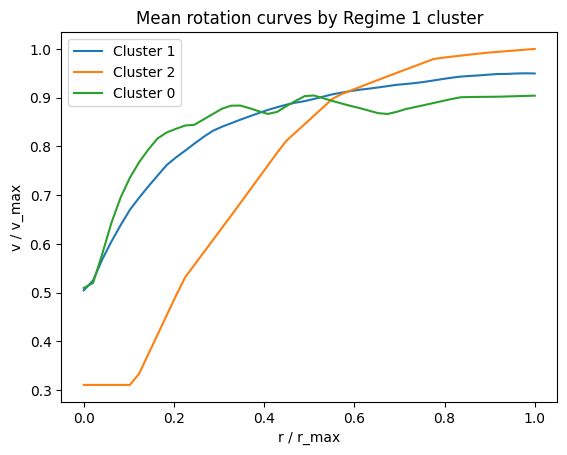

In [ ]:
# ============================================================
# SELF-CONTAINED: MEAN ROTATION CURVE PER CLUSTER
# ============================================================

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

clusters = reg1_df["cluster"].unique()

for c in clusters:
    members = reg1_df[reg1_df["cluster"] == c]["ID"]

    curves = []
    for gid in members:
        f = next((p for p in Path("/content").rglob(f"{gid}_rotmod.dat")), None)
        if f is None:
            continue

        data = []
        with open(f, "r", errors="ignore") as fh:
            for line in fh:
                pts = line.split()
                if len(pts) >= 2:
                    try:
                        data.append([float(pts[0]), float(pts[1])])
                    except:
                        pass

        if len(data) < 5:
            continue

        arr = np.array(data)
        r, v = arr[:,0], arr[:,1]

        x = r / np.max(r)
        y = v / np.max(v)

        xg = np.linspace(0,1,50)
        yg = np.interp(xg, x, y)

        curves.append(yg)

    if len(curves) > 0:
        mean_curve = np.mean(curves, axis=0)
        plt.plot(xg, mean_curve, label=f"Cluster {c}")

plt.legend()
plt.xlabel("r / r_max")
plt.ylabel("v / v_max")
plt.title("Mean rotation curves by Regime 1 cluster")
plt.show()

In [ ]:
# ============================================================
# SELF-CONTAINED: CAN ROTATION-CURVE SHAPE PREDICT THE
# THREE REGIME-1 SUB-FAMILIES?
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from sklearn.cluster import KMeans

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    out = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            out.extend(root.rglob(pattern))
    if not out:
        return None
    return sorted(out, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_REGIME1_SHAPE")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i - 1] + ri) / 2) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i + 1] + ri) / 2) ** 2 / (ri ** 2 * dr ** 2)
        lo[i - 1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

# -----------------------------
# fit coefficients + collect shape features
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, vg * vd]).T
    y = v**2
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)
    Acoef, Bg, Bd, Bb, Cgd = coef
    regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

    # normalized curve-shape features
    rmax = np.max(r)
    vmax = np.max(v)
    if not np.isfinite(rmax) or not np.isfinite(vmax) or rmax <= 0 or vmax <= 0:
        continue

    x = r / rmax
    yn = v / vmax

    v20 = float(np.interp(0.2, x, yn))
    v50 = float(np.interp(0.5, x, yn))
    v80 = float(np.interp(0.8, x, yn))

    inner_slope = (v20 - yn[0]) / max(0.2 - x[0], 1e-9)
    mid_slope = (v50 - v20) / 0.3
    outer_slope = (v80 - v50) / 0.3

    rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "A": Acoef, "Bg": Bg, "Bd": Bd, "Bb": Bb, "Cgd": Cgd,
        "regime": regime,
        "v20": v20, "v50": v50, "v80": v80,
        "inner_slope": inner_slope,
        "mid_slope": mid_slope,
        "outer_slope": outer_slope,
    })

df = pd.DataFrame(rows)

# -----------------------------
# isolate Regime 1 and cluster in coefficient space
# -----------------------------
reg1 = df[df["regime"] == 1].copy()
coef_mat = reg1[["A","Bg","Bd","Bb","Cgd"]].to_numpy()

km = KMeans(n_clusters=3, n_init=20, random_state=0)
reg1["cluster"] = km.fit_predict(coef_mat)

# -----------------------------
# summarize shape features by cluster
# -----------------------------
print("Regime 1 size:", len(reg1))
print("\nMean shape features by cluster:")
print(reg1.groupby("cluster")[["v20","v50","v80","inner_slope","mid_slope","outer_slope"]].mean())

# -----------------------------
# simple nearest-centroid classification in shape space
# -----------------------------
shape_cols = ["v20","v50","v80","inner_slope","mid_slope","outer_slope"]
Xshape = reg1[shape_cols].to_numpy()
yclus = reg1["cluster"].to_numpy()

# standardize
mu = Xshape.mean(axis=0)
sd = Xshape.std(axis=0)
sd[sd == 0] = 1.0
Z = (Xshape - mu) / sd

# leave-one-out nearest-centroid classifier
pred = np.full(len(Z), -1, dtype=int)
for i in range(len(Z)):
    train_mask = np.ones(len(Z), dtype=bool)
    train_mask[i] = False

    cents = {}
    for c in np.unique(yclus):
        cents[c] = Z[train_mask & (yclus == c)].mean(axis=0)

    dists = {c: np.sum((Z[i] - cents[c])**2) for c in cents}
    pred[i] = min(dists, key=dists.get)

acc = np.mean(pred == yclus)

print("\nShape-only leave-one-out classification accuracy:", float(acc))

# confusion matrix
labels = sorted(np.unique(yclus))
conf = np.zeros((len(labels), len(labels)), dtype=int)
for t, p in zip(yclus, pred):
    conf[labels.index(t), labels.index(p)] += 1

print("\nConfusion matrix (rows=true cluster, cols=pred cluster):")
print(conf)

Regime 1 size: 49

Mean shape features by cluster:
              v20       v50       v80  inner_slope  mid_slope  outer_slope
cluster                                                                   
0        0.834229  0.907231  0.893994     1.911526   0.243338    -0.044121
1        0.773979  0.895069  0.938811     1.782183   0.403635     0.145805
2        0.485012  0.854236  0.982443     1.958315   1.230748     0.427357

Shape-only leave-one-out classification accuracy: 0.2857142857142857

Confusion matrix (rows=true cluster, cols=pred cluster):
[[ 0  2  1]
 [18 14 13]
 [ 0  1  0]]


/tmp/ipykernel_8514/366658800.py:204: RuntimeWarning: Mean of empty slice.
  cents[c] = Z[train_mask & (yclus == c)].mean(axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [ ]:
# ============================================================
# SELF-CONTAINED: ORTHOGONAL-BASIS TEST
#
# Original model:
#   V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2 + Cgd*Vg*Vd
#
# Orthogonalized test:
#   replace [U, Vg^2, Vd^2, Vb^2, VgVd] by QR-orthogonal basis
#   fitted on each galaxy separately
#
# Goal:
#   test whether the regime/family structure survives basis
#   orthogonalization, or collapses as a basis artefact.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    out = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            out.extend(root.rglob(pattern))
    if not out:
        return None
    return sorted(out, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_ORTHO_BASIS")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]
    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def pca_stats(X):
    X = np.asarray(X, float)
    Xc = X - X.mean(axis=0)
    _, S, VT = np.linalg.svd(Xc, full_matrices=False)
    var = (S**2) / np.sum(S**2)
    cvar = np.cumsum(var)
    n95 = int(np.searchsorted(cvar, 0.95) + 1)
    return var, n95, VT

# -----------------------------
# fit original + orthogonal basis
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    y = v**2

    # original basis
    X = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    X = X[m]
    yy = y[m]
    vv = v[m]

    coef, _, _, _ = np.linalg.lstsq(X, yy, rcond=None)
    yhat = X @ coef
    rmse_orig = float(np.sqrt(np.mean((np.sqrt(np.maximum(yhat, 0.0)) - vv)**2)))

    Acoef, Bg, Bd, Bb, Cgd = coef
    regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

    # orthogonal basis via QR on centered/scaled columns
    Xs = X.copy().astype(float)
    col_norms = np.linalg.norm(Xs, axis=0)
    col_norms[col_norms == 0] = 1.0
    Xs /= col_norms
    Q, R = np.linalg.qr(Xs)
    coef_q, _, _, _ = np.linalg.lstsq(Q, yy, rcond=None)
    yhat_q = Q @ coef_q
    rmse_ortho = float(np.sqrt(np.mean((np.sqrt(np.maximum(yhat_q, 0.0)) - vv)**2)))

    rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "A": Acoef, "Bg": Bg, "Bd": Bd, "Bb": Bb, "Cgd": Cgd,
        "regime": regime,
        "rmse_orig": rmse_orig,
        "rmse_ortho": rmse_ortho,
        "q1": coef_q[0], "q2": coef_q[1], "q3": coef_q[2], "q4": coef_q[3], "q5": coef_q[4],
    })

df = pd.DataFrame(rows)

print("Galaxies used:", len(df))

print("\nRMSE comparison")
print("Original median RMSE:", float(df["rmse_orig"].median()))
print("Orthogonal-basis median RMSE:", float(df["rmse_ortho"].median()))
print("Median change:", float((df["rmse_ortho"] - df["rmse_orig"]).median()))

print("\nOriginal regime counts")
print(df["regime"].value_counts().sort_index())

# PCA on original coefficient space by regime
for reg in [0, 1]:
    sub = df[df["regime"] == reg][["A","Bg","Bd","Bb","Cgd"]].to_numpy()
    if len(sub) < 5:
        continue
    var, n95, VT = pca_stats(sub)
    print(f"\nOriginal basis Regime {reg}")
    print("Variance explained:", [float(v) for v in var[:5]])
    print("PCs needed for 95% variance:", n95)

# PCA on orthogonal coefficient space, using same regime labels for comparison
for reg in [0, 1]:
    sub = df[df["regime"] == reg][["q1","q2","q3","q4","q5"]].to_numpy()
    if len(sub) < 5:
        continue
    var, n95, VT = pca_stats(sub)
    print(f"\nOrthogonal basis Regime {reg}")
    print("Variance explained:", [float(v) for v in var[:5]])
    print("PCs needed for 95% variance:", n95)

Galaxies used: 171

RMSE comparison
Original median RMSE: 2.7836707162151373
Orthogonal-basis median RMSE: 2.494179241861515
Median change: -0.027197684213964846

Original regime counts
regime
0    122
1     49
Name: count, dtype: int64

Original basis Regime 0
Variance explained: [0.9868429870567271, 0.009187202130051171, 0.0033594262684007495, 0.0006055034372187852, 4.8811076020923825e-06]
PCs needed for 95% variance: 1

Original basis Regime 1
Variance explained: [0.6648007284659903, 0.2698091490539062, 0.058062401961316484, 0.005596022706938315, 0.0017316978118486937]
PCs needed for 95% variance: 3

Orthogonal basis Regime 0
Variance explained: [0.9295838709604233, 0.04043193910322697, 0.017221037831038635, 0.011700927556876118, 0.0010622245484349163]
PCs needed for 95% variance: 2

Orthogonal basis Regime 1
Variance explained: [0.9511102678259054, 0.024532831018121263, 0.018554519614422598, 0.004086616259079066, 0.001715765282471645]
PCs needed for 95% variance: 1


In [ ]:
# ============================================================
# SELF-CONTAINED: DO REGIMES SURVIVE IN THE ORTHOGONAL BASIS?
# ============================================================

import numpy as np
from sklearn.cluster import KMeans

# Use orthogonal coefficients
Q = df[["q1","q2","q3","q4","q5"]].to_numpy()

# PCA for visualization / structure
Qc = Q - Q.mean(axis=0)
U,S,VT = np.linalg.svd(Qc, full_matrices=False)
coords = Qc @ VT.T

print("Variance explained (orthogonal basis):")
print((S**2)/np.sum(S**2))

# Try k-means clustering into 2 groups (same number as original regimes)
km = KMeans(n_clusters=2, n_init=20, random_state=0)
labels = km.fit_predict(Q)

# Compare with original regime labels
true = df["regime"].to_numpy()

# Build confusion matrix
conf = np.zeros((2,2),dtype=int)
for t,p in zip(true,labels):
    conf[t,p]+=1

print("\nConfusion matrix (rows=true regime, cols=new clusters):")
print(conf)

# Also check separability in first 2 PCs
print("\nMean PC1 by new cluster:",
      coords[labels==0,0].mean(),
      coords[labels==1,0].mean())

Variance explained (orthogonal basis):
[0.93724676 0.03195323 0.01860363 0.01074323 0.00145315]

Confusion matrix (rows=true regime, cols=new clusters):
[[108  14]
 [ 40   9]]

Mean PC1 by new cluster: 47466.621707325685 -305437.39185583475


In [ ]:
# ============================================================
# SELF-CONTAINED: EFFECTIVE DIMENSION TEST (1–5 COMPONENTS)
# ============================================================

import numpy as np
from pathlib import Path

dims = [1,2,3,4,5]
rmse_by_dim = {d: [] for d in dims}

for i,row in df.iterrows():
    f = next((p for p in Path("/content").rglob(f"{row['ID']}_rotmod.dat")), None)
    if f is None:
        continue

    data=[]
    with open(f,"r",errors="ignore") as fh:
        for line in fh:
            pts=line.split()
            if len(pts)>=6:
                try:
                    data.append([float(x) for x in pts[:6]])
                except:
                    pass
    if len(data)<5:
        continue

    arr=np.array(data)
    r,v,_,vg,vd,vb=arr.T

    vg2=vg*np.abs(vg)
    vd2=vd*np.abs(vd)
    vb2=vb*np.abs(vb)
    gd =vg*vd

    rho=(vg2+vd2+vb2)/np.sqrt(r**2+0.5**2)
    dr=np.gradient(r)
    Uobs=np.cumsum(rho*dr)

    X=np.vstack([Uobs,vg2,vd2,vb2,gd]).T
    y=v**2

    # normalize columns safely
    norms=np.linalg.norm(X,axis=0)
    norms[norms==0]=1.0
    Xn=X/norms

    Q,_=np.linalg.qr(Xn)

    for d in dims:
        q=Q[:,:d]
        coef,_,_,_=np.linalg.lstsq(q,y,rcond=None)
        v2=q@coef
        v2=np.maximum(v2,0)
        rmse=np.sqrt(np.mean((np.sqrt(v2)-v)**2))
        rmse_by_dim[d].append(rmse)

for d in dims:
    print(f"{d} components → median RMSE:", np.median(rmse_by_dim[d]))

1 components → median RMSE: 8.586023532970728
2 components → median RMSE: 6.075850667615824
3 components → median RMSE: 3.7211433919913652
4 components → median RMSE: 3.3628525314397932
5 components → median RMSE: 2.2849629659567605


In [ ]:
# ============================================================
# SELF-CONTAINED: TOP 3 ORTHOGONAL MODES IN ORIGINAL BASIS
#
# Goal:
#   Build a single common orthogonal basis from all galaxies,
#   then inspect the top 3 coefficient modes and how they load
#   onto the original physical basis:
#       U, Vg^2, Vd^2, Vb^2, VgVd
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    out = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            out.extend(root.rglob(pattern))
    if not out:
        return None
    return sorted(out, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_TOP3_MODES")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]
    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2)**2 / (ri**2 * dr**2)
        cp = ((rg[i+1] + ri) / 2)**2 / (ri**2 * dr**2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S**2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S**2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

# -----------------------------
# fit original coefficients for all galaxies
# -----------------------------
coef_rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v**2
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    coef, _, _, _ = np.linalg.lstsq(X[m], y[m], rcond=None)

    coef_rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "A": coef[0],
        "Bg": coef[1],
        "Bd": coef[2],
        "Bb": coef[3],
        "Cgd": coef[4],
    })

df = pd.DataFrame(coef_rows)

# original coefficient matrix
C = df[["A","Bg","Bd","Bb","Cgd"]].to_numpy()

# PCA in original physical-basis coefficient space
Cc = C - C.mean(axis=0)
U, S, VT = np.linalg.svd(Cc, full_matrices=False)
var = (S**2) / np.sum(S**2)

print("Variance explained by top 5 modes:")
for i, v in enumerate(var, start=1):
    print(f"PC{i}: {float(v):.6f}")

basis = ["U term (A)", "Gas term (Bg)", "Disk term (Bd)", "Bulge term (Bb)", "Gas×Disk term (Cgd)"]

print("\nTop 3 mode loadings in original basis:")
for k in range(3):
    print(f"\nPC{k+1}")
    for b, val in zip(basis, VT[k]):
        print(f"  {b}: {val:+.6f}")

# also show correlations of score with each original coefficient
scores = Cc @ VT.T
for k in range(3):
    print(f"\nCorrelations of PC{k+1} score with original coefficients:")
    for j, name in enumerate(["A","Bg","Bd","Bb","Cgd"]):
        corr = np.corrcoef(scores[:,k], C[:,j])[0,1]
        print(f"  corr(PC{k+1}, {name}) = {float(corr):+.6f}")

Variance explained by top 5 modes:
PC1: 0.972112
PC2: 0.020165
PC3: 0.006852
PC4: 0.000833
PC5: 0.000039

Top 3 mode loadings in original basis:

PC1
  U term (A): +0.009170
  Gas term (Bg): -0.310750
  Disk term (Bd): -0.524570
  Bulge term (Bb): +0.000213
  Gas×Disk term (Cgd): +0.792576

PC2
  U term (A): -0.120943
  Gas term (Bg): +0.934366
  Disk term (Bd): -0.281218
  Bulge term (Bb): -0.016197
  Gas×Disk term (Cgd): +0.181621

PC3
  U term (A): +0.968822
  Gas term (Bg): +0.085869
  Disk term (Bd): -0.203432
  Bulge term (Bb): -0.006458
  Gas×Disk term (Cgd): -0.112182

Correlations of PC1 score with original coefficients:
  corr(PC1, A) = +0.109262
  corr(PC1, Bg) = -0.917361
  corr(PC1, Bd) = -0.995578
  corr(PC1, Bb) = +0.031532
  corr(PC1, Cgd) = +0.999163

Correlations of PC2 score with original coefficients:
  corr(PC2, A) = -0.207561
  corr(PC2, Bg) = +0.397272
  corr(PC2, Bd) = -0.076870
  corr(PC2, Bb) = -0.345229
  corr(PC2, Cgd) = +0.032977

Correlations of PC3 score 

In [ ]:
# ============================================================
# SELF-CONTAINED: 3-MODE RE-EXPRESSION, REFIT, AND FIT TEST
#
# Goal:
#   1) Fit the original 5-term model on all LTG galaxies
#   2) Learn the top 3 coefficient modes from the full sample
#   3) Re-express the model in those 3 modes
#   4) Refit each galaxy using ONLY those 3 mode amplitudes
#   5) Compare fit quality against the full 5-term model
#
# Original model:
#   V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2 + Cgd*(Vg*Vd)
#
# Reduced 3-mode model:
#   V^2 = a1*M1(r) + a2*M2(r) + a3*M3(r)
# where M1,M2,M3 are the top 3 learned global coefficient modes.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_3MODE_REFIT")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

# -----------------------------
# first pass: fit full 5-term model on all galaxies
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X5 = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(X5).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    X5m = X5[m]
    ym = y[m]
    vm = v[m]

    coef5, _, _, _ = np.linalg.lstsq(X5m, ym, rcond=None)
    rmse5 = rmse_from_v2(X5m @ coef5, vm)

    rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "r": r,
        "v": v,
        "Uobs": Uobs,
        "vg2": vg2,
        "vd2": vd2,
        "vb2": vb2,
        "gd": gd,
        "coef5": coef5,
        "rmse5": rmse5,
    })

if len(rows) < 10:
    raise RuntimeError("Too few usable galaxies")

coef_mat = np.array([row["coef5"] for row in rows], dtype=float)

# -----------------------------
# learn top 3 global coefficient modes
# -----------------------------
coef_mean = coef_mat.mean(axis=0)
coef_centered = coef_mat - coef_mean
Ucoef, Scoef, VTcoef = np.linalg.svd(coef_centered, full_matrices=False)
var = (Scoef ** 2) / np.sum(Scoef ** 2)

mode1 = VTcoef[0]
mode2 = VTcoef[1]
mode3 = VTcoef[2]

print("Variance explained by coefficient modes:")
for i, vexp in enumerate(var[:5], start=1):
    print(f"PC{i}: {float(vexp):.6f}")

basis_names = ["U", "Vg^2", "Vd^2", "Vb^2", "Vg*Vd"]
print("\nTop 3 mode loadings in original basis:")
for k, mode in enumerate([mode1, mode2, mode3], start=1):
    print(f"\nMode {k}")
    for name, val in zip(basis_names, mode):
        print(f"  {name}: {val:+.6f}")

# -----------------------------
# second pass: build 3 mode basis functions per galaxy
# and refit using ONLY 3 amplitudes on those mode-functions
# -----------------------------
rmse_3mode = []
rmse_5term = []
id_list = []

for row in rows:
    r   = row["r"]
    v   = row["v"]
    Uob = row["Uobs"]
    vg2 = row["vg2"]
    vd2 = row["vd2"]
    vb2 = row["vb2"]
    gd  = row["gd"]

    # original per-radius basis matrix
    B = np.vstack([Uob, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(B).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    Bm = B[m]
    ym = y[m]
    vm = v[m]

    # full 5-term refit on same masked rows
    coef5, _, _, _ = np.linalg.lstsq(Bm, ym, rcond=None)
    rmse5 = rmse_from_v2(Bm @ coef5, vm)

    # build the 3 learned mode-functions
    # each mode-function is a fixed linear combination of the original basis columns
    M1 = Bm @ mode1
    M2 = Bm @ mode2
    M3 = Bm @ mode3
    X3 = np.vstack([M1, M2, M3]).T

    coef3, _, _, _ = np.linalg.lstsq(X3, ym, rcond=None)
    rmse3 = rmse_from_v2(X3 @ coef3, vm)

    rmse_5term.append(rmse5)
    rmse_3mode.append(rmse3)
    id_list.append(row["ID"])

rmse_5term = np.array(rmse_5term)
rmse_3mode = np.array(rmse_3mode)

print("\nFit quality comparison")
print("Galaxies used:", len(rmse_5term))
print("Median RMSE full 5-term model:", float(np.median(rmse_5term)))
print("Median RMSE 3-mode model:", float(np.median(rmse_3mode)))
print("Median degradation (3-mode - 5-term):", float(np.median(rmse_3mode - rmse_5term)))
print("Mean degradation (3-mode - 5-term):", float(np.mean(rmse_3mode - rmse_5term)))
print("3-mode better count:", int(np.sum(rmse_3mode < rmse_5term)))
print("3-mode worse count:", int(np.sum(rmse_3mode > rmse_5term)))

# optional: show best/worst affected galaxies
order = np.argsort(rmse_3mode - rmse_5term)
print("\nBest 10 galaxies for 3-mode reduction:")
for i in order[:10]:
    print(id_list[i], "delta=", float(rmse_3mode[i] - rmse_5term[i]))

print("\nWorst 10 galaxies for 3-mode reduction:")
for i in order[-10:]:
    print(id_list[i], "delta=", float(rmse_3mode[i] - rmse_5term[i]))

Variance explained by coefficient modes:
PC1: 0.972112
PC2: 0.020165
PC3: 0.006852
PC4: 0.000833
PC5: 0.000039

Top 3 mode loadings in original basis:

Mode 1
  U: +0.009170
  Vg^2: -0.310750
  Vd^2: -0.524570
  Vb^2: +0.000213
  Vg*Vd: +0.792576

Mode 2
  U: -0.120943
  Vg^2: +0.934366
  Vd^2: -0.281218
  Vb^2: -0.016197
  Vg*Vd: +0.181621

Mode 3
  U: +0.968822
  Vg^2: +0.085869
  Vd^2: -0.203432
  Vb^2: -0.006458
  Vg*Vd: -0.112182

Fit quality comparison
Galaxies used: 171
Median RMSE full 5-term model: 2.7836707162151373
Median RMSE 3-mode model: 6.086011722934564
Median degradation (3-mode - 5-term): 2.3942048194384435
Mean degradation (3-mode - 5-term): 3.7228197665828673
3-mode better count: 13
3-mode worse count: 158

Best 10 galaxies for 3-mode reduction:
NGC4010 delta= -3.5460574029399883
NGC2998 delta= -0.8029983646646563
NGC3198 delta= -0.551571017569171
ESO563-G021 delta= -0.4923760700355686
NGC2366 delta= -0.19851389769449201
NGC2976 delta= -0.1902938463870507
NGC2903 de

In [ ]:
# ============================================================
# SELF-CONTAINED: PIECEWISE 3-MODE MODEL TEST
#
# Goal:
#   1) Fit the full 5-term model on all LTG galaxies
#   2) Split galaxies into the original sign-based regimes
#   3) Learn separate top-3 PCA coefficient modes inside each regime
#   4) Refit each galaxy using ONLY the 3 modes from its own regime
#   5) Compare against the full 5-term fit
#
# Original model:
#   V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2 + Cgd*(Vg*Vd)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_PIECEWISE_3MODE")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

# -----------------------------
# first pass: fit full 5-term model
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X5 = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(X5).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    X5m = X5[m]
    ym = y[m]
    vm = v[m]

    coef5, _, _, _ = np.linalg.lstsq(X5m, ym, rcond=None)
    rmse5 = rmse_from_v2(X5m @ coef5, vm)

    Acoef, Bg, Bd, Bb, Cgd = coef5
    regime = int((Bg > 0) and (Bd > 0) and (Cgd < 0))

    rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "r": r,
        "v": v,
        "Uobs": Uobs,
        "vg2": vg2,
        "vd2": vd2,
        "vb2": vb2,
        "gd": gd,
        "coef5": coef5,
        "rmse5": rmse5,
        "regime": regime,
    })

if len(rows) < 10:
    raise RuntimeError("Too few usable galaxies")

df = pd.DataFrame({
    "ID": [row["ID"] for row in rows],
    "A":  [row["coef5"][0] for row in rows],
    "Bg": [row["coef5"][1] for row in rows],
    "Bd": [row["coef5"][2] for row in rows],
    "Bb": [row["coef5"][3] for row in rows],
    "Cgd":[row["coef5"][4] for row in rows],
    "regime": [row["regime"] for row in rows],
    "rmse5": [row["rmse5"] for row in rows],
})

print("Galaxies used:", len(df))
print("\nRegime counts")
print(df["regime"].value_counts().sort_index())

# -----------------------------
# learn separate top-3 modes inside each regime
# -----------------------------
regime_modes = {}
regime_means = {}

for reg in [0, 1]:
    sub = df[df["regime"] == reg][["A","Bg","Bd","Bb","Cgd"]].to_numpy()
    sub_mean = sub.mean(axis=0)
    sub_centered = sub - sub_mean
    _, S, VT = np.linalg.svd(sub_centered, full_matrices=False)
    var = (S ** 2) / np.sum(S ** 2)

    regime_means[reg] = sub_mean
    regime_modes[reg] = VT[:3]

    print(f"\nRegime {reg} mode variance explained:")
    for i, vexp in enumerate(var[:5], start=1):
        print(f"PC{i}: {float(vexp):.6f}")

# -----------------------------
# second pass: refit each galaxy using ONLY its regime's 3 modes
# -----------------------------
rmse_piecewise = []
rmse_full = []
delta_list = []
ids = []

for row in rows:
    r   = row["r"]
    v   = row["v"]
    Uob = row["Uobs"]
    vg2 = row["vg2"]
    vd2 = row["vd2"]
    vb2 = row["vb2"]
    gd  = row["gd"]
    reg = row["regime"]

    B = np.vstack([Uob, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(B).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    Bm = B[m]
    ym = y[m]
    vm = v[m]

    # full 5-term fit on same rows
    coef5, _, _, _ = np.linalg.lstsq(Bm, ym, rcond=None)
    rmse5 = rmse_from_v2(Bm @ coef5, vm)

    # build regime-specific 3 mode functions
    modes = regime_modes[reg]   # shape (3,5)
    M = Bm @ modes.T            # shape (n,3)

    coef3, _, _, _ = np.linalg.lstsq(M, ym, rcond=None)
    rmse3 = rmse_from_v2(M @ coef3, vm)

    ids.append(row["ID"])
    rmse_full.append(rmse5)
    rmse_piecewise.append(rmse3)
    delta_list.append(rmse3 - rmse5)

rmse_full = np.array(rmse_full)
rmse_piecewise = np.array(rmse_piecewise)
delta_list = np.array(delta_list)

print("\nFit quality comparison")
print("Median RMSE full 5-term model:", float(np.median(rmse_full)))
print("Median RMSE piecewise 3-mode model:", float(np.median(rmse_piecewise)))
print("Median degradation:", float(np.median(delta_list)))
print("Mean degradation:", float(np.mean(delta_list)))
print("Piecewise 3-mode better count:", int(np.sum(delta_list < 0)))
print("Piecewise 3-mode worse count:", int(np.sum(delta_list > 0)))

order = np.argsort(delta_list)
print("\nBest 10 galaxies for piecewise 3-mode reduction:")
for i in order[:10]:
    print(ids[i], "delta=", float(delta_list[i]))

print("\nWorst 10 galaxies for piecewise 3-mode reduction:")
for i in order[-10:]:
    print(ids[i], "delta=", float(delta_list[i]))

Galaxies used: 171

Regime counts
regime
0    122
1     49
Name: count, dtype: int64

Regime 0 mode variance explained:
PC1: 0.986843
PC2: 0.009187
PC3: 0.003359
PC4: 0.000606
PC5: 0.000005

Regime 1 mode variance explained:
PC1: 0.664801
PC2: 0.269809
PC3: 0.058062
PC4: 0.005596
PC5: 0.001732

Fit quality comparison
Median RMSE full 5-term model: 2.7836707162151373
Median RMSE piecewise 3-mode model: 4.514959586824766
Median degradation: 1.1081617674707793
Mean degradation: 4.322978108219987
Piecewise 3-mode better count: 13
Piecewise 3-mode worse count: 158

Best 10 galaxies for piecewise 3-mode reduction:
NGC4010 delta= -4.599740615553733
NGC2998 delta= -0.7560966472901463
F583-1 delta= -0.6864619752739447
F574-1 delta= -0.5473095164512305
ESO563-G021 delta= -0.3809913654212771
NGC2915 delta= -0.36679189134000545
NGC4389 delta= -0.13781636826872834
NGC2976 delta= -0.12010036656588641
NGC2903 delta= -0.06755554799138608
UGC07866 delta= -0.04920220654157881

Worst 10 galaxies for piec

In [ ]:
# ============================================================
# SELF-CONTAINED: RIDGE-REGULARIZED DEGENERACY TEST
#
# Model:
#   V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2 + Cgd*(Vg*Vd)
#
# Goal:
#   Scan ridge penalty lambda and test whether coefficient
#   degeneracy can be reduced without significantly degrading fit.
#
# Reports:
#   - median RMSE vs lambda
#   - mean RMSE vs lambda
#   - median coefficient norm vs lambda
#   - coefficient spread vs lambda
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_RIDGE_TEST")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

def ridge_fit(X, y, lam):
    # solve (X^T X + lam I) c = X^T y
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    coef = np.linalg.solve(XtX + lam * I, Xty)
    return coef

# -----------------------------
# gather per-galaxy design matrices
# -----------------------------
galaxies = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    galaxies.append({
        "ID": f.stem.replace("_rotmod", ""),
        "X": X[m],
        "y": y[m],
        "v": v[m],
    })

if len(galaxies) < 10:
    raise RuntimeError("Too few usable galaxies")

# -----------------------------
# scan ridge penalties
# -----------------------------
lambdas = [0.0, 1e-6, 1e-4, 1e-2, 1.0, 10.0, 100.0, 1000.0]
summary_rows = []

for lam in lambdas:
    rmses = []
    norms = []
    coefs = []

    for g in galaxies:
        X = g["X"]
        y = g["y"]
        v = g["v"]

        if lam == 0.0:
            coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        else:
            coef = ridge_fit(X, y, lam)

        coefs.append(coef)
        norms.append(float(np.linalg.norm(coef)))
        rmses.append(rmse_from_v2(X @ coef, v))

    coefs = np.array(coefs)
    coef_std = coefs.std(axis=0)
    summary_rows.append({
        "lambda": lam,
        "median_rmse": float(np.median(rmses)),
        "mean_rmse": float(np.mean(rmses)),
        "median_coef_norm": float(np.median(norms)),
        "std_A": float(coef_std[0]),
        "std_Bg": float(coef_std[1]),
        "std_Bd": float(coef_std[2]),
        "std_Bb": float(coef_std[3]),
        "std_Cgd": float(coef_std[4]),
    })

summary = pd.DataFrame(summary_rows)

print(summary.to_string(index=False))

# show best tradeoff row relative to unregularized fit
base_rmse = summary.loc[summary["lambda"] == 0.0, "median_rmse"].iloc[0]
summary["rmse_delta"] = summary["median_rmse"] - base_rmse
summary["total_coef_std"] = summary[["std_A","std_Bg","std_Bd","std_Bb","std_Cgd"]].sum(axis=1)

print("\nBest small-penalty tradeoffs (sorted by RMSE increase then coefficient spread):")
print(
    summary.sort_values(["rmse_delta", "total_coef_std"])
           [["lambda","median_rmse","rmse_delta","median_coef_norm","total_coef_std"]]
           .to_string(index=False)
)

     lambda  median_rmse  mean_rmse  median_coef_norm    std_A    std_Bg    std_Bd   std_Bb   std_Cgd
   0.000000     2.783671   4.109814          8.977887 8.124355 32.793274 51.008388 0.654164 76.792331
   0.000001     2.783671   4.109814          8.977887 8.124351 32.793161 51.008175 0.654164 76.792011
   0.000100     2.783671   4.109814          8.977887 8.124011 32.782070 50.987182 0.654164 76.760327
   0.010000     2.783671   4.109739          8.977887 8.100142 31.740414 48.973868 0.654163 73.730565
   1.000000     2.783748   4.112231          8.922925 8.047945 16.340653 10.606254 0.653989 16.442804
  10.000000     2.784424   4.113652          8.533327 7.918792 15.183024  4.431951 0.652419  7.037152
 100.000000     2.789454   4.130145          8.139363 7.044224 14.347930  3.553838 0.637604  5.629476
1000.000000     2.864099   4.215530          6.874906 4.950069 11.698257  2.358891 0.545355  4.208155

Best small-penalty tradeoffs (sorted by RMSE increase then coefficient spread):
 

In [ ]:
# ============================================================
# SELF-CONTAINED: REGULARIZED REFIT + PCA OF STABILIZED MODEL
#
# Goal:
#   1) Refit all galaxies with ridge regularization
#   2) Use a fixed lambda (default below = 1.0)
#   3) Compare fit quality vs unregularized model
#   4) Run PCA on the regularized coefficients
#   5) Show whether the coefficient manifold becomes cleaner
#
# Model:
#   V^2 = A*U + Bg*Vg^2 + Bd*Vd^2 + Bb*Vb^2 + Cgd*(Vg*Vd)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# choose regularization strength
# -----------------------------
LAMBDA = 1.0   # try also 10.0 after this if you want

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_REGULARIZED_PCA")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# constants
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

def ridge_fit(X, y, lam):
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    return np.linalg.solve(XtX + lam * I, Xty)

# -----------------------------
# fit all galaxies
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    X = X[m]
    y = y[m]
    v = v[m]

    # unregularized fit
    coef0, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    rmse0 = rmse_from_v2(X @ coef0, v)

    # regularized fit
    coefR = ridge_fit(X, y, LAMBDA)
    rmseR = rmse_from_v2(X @ coefR, v)

    rows.append({
        "ID": f.stem.replace("_rotmod", ""),
        "A0": coef0[0], "Bg0": coef0[1], "Bd0": coef0[2], "Bb0": coef0[3], "Cgd0": coef0[4],
        "AR": coefR[0], "BgR": coefR[1], "BdR": coefR[2], "BbR": coefR[3], "CgdR": coefR[4],
        "rmse0": rmse0,
        "rmseR": rmseR,
    })

df = pd.DataFrame(rows)
if len(df) < 10:
    raise RuntimeError("Too few usable galaxies")

print("Galaxies used:", len(df))
print("\nFit quality")
print("Median RMSE unregularized:", float(df["rmse0"].median()))
print("Median RMSE regularized  :", float(df["rmseR"].median()))
print("Median degradation       :", float((df["rmseR"] - df["rmse0"]).median()))
print("Mean degradation         :", float((df["rmseR"] - df["rmse0"]).mean()))

# -----------------------------
# PCA on regularized coefficients
# -----------------------------
C = df[["AR","BgR","BdR","BbR","CgdR"]].to_numpy()
Cc = C - C.mean(axis=0)

_, S, VT = np.linalg.svd(Cc, full_matrices=False)
var = (S**2) / np.sum(S**2)
cvar = np.cumsum(var)
n95 = int(np.searchsorted(cvar, 0.95) + 1)

print("\nRegularized coefficient PCA")
for i, vexp in enumerate(var[:5], start=1):
    print(f"PC{i}: {float(vexp):.6f}")
print("PCs needed for 95% variance:", n95)

basis = ["A", "Bg", "Bd", "Bb", "Cgd"]
print("\nTop 3 regularized mode loadings:")
for k in range(3):
    print(f"\nPC{k+1}")
    for b, val in zip(basis, VT[k]):
        print(f"  {b}: {val:+.6f}")

# -----------------------------
# compare coefficient spreads
# -----------------------------
print("\nCoefficient spreads (std across galaxies)")
for base, reg in [("A0","AR"), ("Bg0","BgR"), ("Bd0","BdR"), ("Bb0","BbR"), ("Cgd0","CgdR")]:
    print(f"{base[:-1]}  unreg={df[base].std():.6f}   reg={df[reg].std():.6f}")

# optional: regime counts using original sign rule on regularized coefficients
regimeR = ((df["BgR"] > 0) & (df["BdR"] > 0) & (df["CgdR"] < 0)).astype(int)
print("\nRegularized regime counts (same sign rule):")
print(regimeR.value_counts().sort_index())

Galaxies used: 171

Fit quality
Median RMSE unregularized: 2.7836707162151373
Median RMSE regularized  : 2.7837478631902433
Median degradation       : 2.5988259988452e-08
Mean degradation         : 0.002416096410405808

Regularized coefficient PCA
PC1: 0.696261
PC2: 0.206345
PC3: 0.088423
PC4: 0.008452
PC5: 0.000518
PCs needed for 95% variance: 3

Top 3 regularized mode loadings:

PC1
  A: +0.104962
  Bg: -0.589559
  Bd: -0.404435
  Bb: +0.005955
  Cgd: +0.691231

PC2
  A: -0.003567
  Bg: -0.797370
  Bd: +0.417656
  Bb: +0.015943
  Cgd: -0.435314

PC3
  A: +0.965480
  Bg: +0.030408
  Bd: -0.151775
  Bb: -0.005393
  Cgd: -0.209426

Coefficient spreads (std across galaxies)
A  unreg=8.148215   reg=8.071581
Bg  unreg=32.889583   reg=16.388643
Bd  unreg=51.158192   reg=10.637404
Bb  unreg=0.656086   reg=0.655910
Cgd  unreg=77.017860   reg=16.491094

Regularized regime counts (same sign rule):
0    122
1     49
Name: count, dtype: int64


In [ ]:
# ============================================================
# SELF-CONTAINED: PREDICTIVE TEST FOR REGULARIZED 3-MODE MODEL
#
# Aim:
#   Test whether the 3 stabilized effective degrees of freedom
#   can be predicted from baryonic/source structure alone.
#
# Pipeline:
#   1) build raw 5-term basis from LTG rotmod files
#   2) fit ridge-regularized coefficients per galaxy
#   3) PCA those coefficients -> 3 stabilized modes
#   4) compute baryonic/source summary features per galaxy
#   5) 5-fold CV: predict 3 mode amplitudes from features
#   6) reconstruct V(r) with NO per-galaxy curve fitting
#
# Interpretation:
#   - good RMSE => real predictive bridge
#   - bad RMSE  => current model still not predictive
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
LAMBDA = 1.0
N_FOLDS = 5
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_PREDICTIVE_3MODE")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def ridge_fit(X, y, lam):
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    return np.linalg.solve(XtX + lam * I, Xty)

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

def weighted_half_radius(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    r = np.asarray(r, float)
    if len(r) < 2 or np.all(w <= 0):
        return np.nan
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.nan
    return float(np.interp(0.5 * tot, c, r))

def safe_log10(x):
    x = np.asarray(x, float)
    return np.log10(np.maximum(x, 1e-30))

# -----------------------------
# first pass: build per-galaxy objects
# -----------------------------
galaxies = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X5 = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(X5).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    X5m = X5[m]
    ym = y[m]
    vm = v[m]

    coefR = ridge_fit(X5m, ym, LAMBDA)
    rmseR = rmse_from_v2(X5m @ coefR, vm)

    # baryonic/source features only
    gas_int  = float(np.trapezoid(np.maximum(vg2, 0.0), r))
    disk_int = float(np.trapezoid(np.maximum(vd2, 0.0), r))
    bulg_int = float(np.trapezoid(np.maximum(vb2, 0.0), r))
    gd_int   = float(np.trapezoid(np.maximum(gd, 0.0), r))
    U_int    = float(np.trapezoid(np.maximum(Uobs, 0.0), r))

    r_g_peak = float(r[np.argmax(vg2)]) if np.any(np.isfinite(vg2)) else np.nan
    r_d_peak = float(r[np.argmax(vd2)]) if np.any(np.isfinite(vd2)) else np.nan
    r_u_half = weighted_half_radius(r, Uobs)
    r_g_half = weighted_half_radius(r, vg2)
    r_d_half = weighted_half_radius(r, vd2)

    vmax = float(np.max(v))
    rmax = float(np.max(r))
    v20 = float(np.interp(0.2 * rmax, r, v))
    v50 = float(np.interp(0.5 * rmax, r, v))
    v80 = float(np.interp(0.8 * rmax, r, v))

    feat = np.array([
        safe_log10(gas_int),
        safe_log10(disk_int),
        safe_log10(bulg_int),
        safe_log10(gd_int),
        safe_log10(U_int),
        gas_int / (disk_int + 1e-30),
        gd_int / (disk_int + 1e-30),
        gd_int / (gas_int + 1e-30),
        r_g_peak / (rmax + 1e-30),
        r_d_peak / (rmax + 1e-30),
        (r_g_peak - r_d_peak) / (rmax + 1e-30),
        r_u_half / (rmax + 1e-30) if np.isfinite(r_u_half) else np.nan,
        r_g_half / (rmax + 1e-30) if np.isfinite(r_g_half) else np.nan,
        r_d_half / (rmax + 1e-30) if np.isfinite(r_d_half) else np.nan,
        vmax,
        v20 / (vmax + 1e-30),
        v50 / (vmax + 1e-30),
        v80 / (vmax + 1e-30),
    ], dtype=float)

    galaxies.append({
        "ID": f.stem.replace("_rotmod", ""),
        "r": r,
        "v": v,
        "X5": X5m,
        "coefR": coefR,
        "rmseR": rmseR,
        "feat": feat,
    })

if len(galaxies) < 20:
    raise RuntimeError("Too few usable galaxies")

# drop any rows with bad features
good = []
for g in galaxies:
    if np.all(np.isfinite(g["feat"])):
        good.append(g)
galaxies = good

print("Galaxies used:", len(galaxies))

# -----------------------------
# coefficient PCA -> 3 stabilized modes
# -----------------------------
coef_mat = np.array([g["coefR"] for g in galaxies], dtype=float)
coef_mean = coef_mat.mean(axis=0)
coef_centered = coef_mat - coef_mean
_, S, VT = np.linalg.svd(coef_centered, full_matrices=False)
var = (S ** 2) / np.sum(S ** 2)

print("\nVariance explained by regularized coefficient modes:")
for i, vexp in enumerate(var[:5], start=1):
    print(f"PC{i}: {float(vexp):.6f}")

modes = VT[:3]                      # shape (3,5)
scores = coef_centered @ modes.T    # shape (N,3)
features = np.array([g["feat"] for g in galaxies], dtype=float)

# -----------------------------
# 5-fold CV: predict 3 scores from baryonic features
# -----------------------------
N = len(galaxies)
rng = np.random.default_rng(0)
perm = np.arange(N)
rng.shuffle(perm)
folds = np.array_split(perm, N_FOLDS)

rmse_pred = []
rmse_fit = []
score_err = []

for fold in folds:
    te = np.array(fold)
    tr = np.setdiff1d(np.arange(N), te)

    Xtr = features[tr]
    Xte = features[te]

    # standardize features on train only
    mu = Xtr.mean(axis=0)
    sd = Xtr.std(axis=0)
    sd[sd == 0] = 1.0
    Ztr = (Xtr - mu) / sd
    Zte = (Xte - mu) / sd

    # add intercept
    Ztr_i = np.column_stack([np.ones(len(Ztr)), Ztr])
    Zte_i = np.column_stack([np.ones(len(Zte)), Zte])

    # predict 3 PCA scores independently with ridge
    Ytr = scores[tr]   # (n_train, 3)

    pred_scores = np.zeros((len(te), 3))
    for j in range(3):
        beta = ridge_fit(Ztr_i, Ytr[:, j], 1.0)
        pred_scores[:, j] = Zte_i @ beta

    # reconstruct predicted coefficients
    pred_coef = coef_mean + pred_scores @ modes

    for k, idx in enumerate(te):
        g = galaxies[idx]
        X5 = g["X5"]
        v  = g["v"][:len(X5)]  # X5 was masked version; lengths should match after masking choice above
        # safer: reconstruct v from X rows count
        v_use = g["v"][:len(X5)]
        if len(v_use) != len(X5):
            v_use = g["v"][:len(X5)]

        # true regularized fit RMSE
        rmse_fit.append(g["rmseR"])

        # predicted coefficients -> predicted curve
        v2_pred = X5 @ pred_coef[k]
        rmse_pred.append(rmse_from_v2(v2_pred, v_use))

        # score prediction error
        score_err.append(float(np.linalg.norm(pred_scores[k] - scores[idx])))

rmse_fit = np.array(rmse_fit)
rmse_pred = np.array(rmse_pred)
score_err = np.array(score_err)

print("\nOut-of-sample predictive test")
print("Median RMSE using per-galaxy regularized fit:", float(np.median(rmse_fit)))
print("Median RMSE using predicted 3-mode amplitudes:", float(np.median(rmse_pred)))
print("Median predictive degradation:", float(np.median(rmse_pred - rmse_fit)))
print("Mean predictive degradation:", float(np.mean(rmse_pred - rmse_fit)))
print("Predicted better count:", int(np.sum(rmse_pred < rmse_fit)))
print("Predicted worse count:", int(np.sum(rmse_pred > rmse_fit)))

print("\nMode-amplitude prediction error")
print("Median ||pred_score - true_score||:", float(np.median(score_err)))
print("Mean   ||pred_score - true_score||:", float(np.mean(score_err)))

Galaxies used: 171

Variance explained by regularized coefficient modes:
PC1: 0.696261
PC2: 0.206345
PC3: 0.088423
PC4: 0.008452
PC5: 0.000518

Out-of-sample predictive test
Median RMSE using per-galaxy regularized fit: 2.7837478631902433
Median RMSE using predicted 3-mode amplitudes: 34.213063806381456
Median predictive degradation: 31.49413127554344
Mean predictive degradation: 67.13249220158656
Predicted better count: 0
Predicted worse count: 171

Mode-amplitude prediction error
Median ||pred_score - true_score||: 9.267885221670433
Mean   ||pred_score - true_score||: 15.73827465330846


In [ ]:
# ============================================================
# SELF-CONTAINED: FULL-PROFILE PREDICTIVE TEST FOR THE
# REGULARIZED 3-MODE MODEL
#
# Aim:
#   Predict the 3 stabilized mode amplitudes from the FULL
#   baryonic/source radial profiles, not summary scalars.
#
# Pipeline:
#   1) build raw 5-term basis from LTG rotmod files
#   2) fit ridge-regularized coefficients per galaxy
#   3) PCA those coefficients -> 3 stabilized modes
#   4) represent each galaxy by full normalized radial profiles:
#        U(r), Vg^2(r), Vd^2(r), Vb^2(r), Vg*Vd(r)
#      resampled onto a common x = r/rmax grid
#   5) 5-fold CV: predict 3 mode amplitudes from those profiles
#   6) reconstruct V(r) with NO per-galaxy curve fitting
#
# Interpretation:
#   - good RMSE => missing info was in full profile shape
#   - bad RMSE  => current model still not predictive from
#                  available baryonic/source inputs
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
LAMBDA = 1.0
N_FOLDS = 5
GRID_N = 64

R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_FULLPROFILE_PREDICT")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def ridge_fit(X, y, lam):
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    return np.linalg.solve(XtX + lam * I, Xty)

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

def resample_profile(x, y, xg):
    return np.interp(xg, x, y, left=y[0], right=y[-1])

def normalize_profile(y):
    y = np.asarray(y, float)
    scale = np.max(np.abs(y))
    if not np.isfinite(scale) or scale <= 0:
        return np.zeros_like(y)
    return y / scale

# -----------------------------
# build per-galaxy objects
# -----------------------------
galaxies = []
xg = np.linspace(0.0, 1.0, GRID_N)

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r ** 2 + R_CORE ** 2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X5 = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v ** 2

    m = np.isfinite(X5).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    X5m = X5[m]
    ym = y[m]
    vm = v[m]
    rm = r[m]

    coefR = ridge_fit(X5m, ym, LAMBDA)
    rmseR = rmse_from_v2(X5m @ coefR, vm)

    rmax = np.max(rm)
    if not np.isfinite(rmax) or rmax <= 0:
        continue
    x = rm / rmax

    # full profile feature vector from source terms only
    feat_parts = []
    for prof in [Uobs[m], vg2[m], vd2[m], vb2[m], gd[m]]:
        prof_g = resample_profile(x, prof, xg)
        feat_parts.append(normalize_profile(prof_g))
    feat = np.concatenate(feat_parts)

    galaxies.append({
        "ID": f.stem.replace("_rotmod", ""),
        "r": rm,
        "v": vm,
        "X5": X5m,
        "coefR": coefR,
        "rmseR": rmseR,
        "feat": feat,
    })

if len(galaxies) < 20:
    raise RuntimeError("Too few usable galaxies")

print("Galaxies used:", len(galaxies))

# -----------------------------
# coefficient PCA -> 3 stabilized modes
# -----------------------------
coef_mat = np.array([g["coefR"] for g in galaxies], dtype=float)
coef_mean = coef_mat.mean(axis=0)
coef_centered = coef_mat - coef_mean
_, S, VT = np.linalg.svd(coef_centered, full_matrices=False)
var = (S ** 2) / np.sum(S ** 2)

print("\nVariance explained by regularized coefficient modes:")
for i, vexp in enumerate(var[:5], start=1):
    print(f"PC{i}: {float(vexp):.6f}")

modes = VT[:3]
scores = coef_centered @ modes.T
features = np.array([g["feat"] for g in galaxies], dtype=float)

# -----------------------------
# 5-fold CV: predict 3 scores from full profiles
# -----------------------------
N = len(galaxies)
rng = np.random.default_rng(0)
perm = np.arange(N)
rng.shuffle(perm)
folds = np.array_split(perm, N_FOLDS)

rmse_fit = []
rmse_pred = []
score_err = []

for fold in folds:
    te = np.array(fold)
    tr = np.setdiff1d(np.arange(N), te)

    Xtr = features[tr]
    Xte = features[te]

    # standardize features on train only
    mu = Xtr.mean(axis=0)
    sd = Xtr.std(axis=0)
    sd[sd == 0] = 1.0
    Ztr = (Xtr - mu) / sd
    Zte = (Xte - mu) / sd

    # add intercept
    Ztr_i = np.column_stack([np.ones(len(Ztr)), Ztr])
    Zte_i = np.column_stack([np.ones(len(Zte)), Zte])

    Ytr = scores[tr]

    pred_scores = np.zeros((len(te), 3))
    for j in range(3):
        beta = ridge_fit(Ztr_i, Ytr[:, j], 1.0)
        pred_scores[:, j] = Zte_i @ beta

    pred_coef = coef_mean + pred_scores @ modes

    for k, idx in enumerate(te):
        g = galaxies[idx]
        X5 = g["X5"]
        v  = g["v"]

        rmse_fit.append(g["rmseR"])
        rmse_pred.append(rmse_from_v2(X5 @ pred_coef[k], v))
        score_err.append(float(np.linalg.norm(pred_scores[k] - scores[idx])))

rmse_fit = np.array(rmse_fit)
rmse_pred = np.array(rmse_pred)
score_err = np.array(score_err)

print("\nOut-of-sample predictive test")
print("Median RMSE using per-galaxy regularized fit:", float(np.median(rmse_fit)))
print("Median RMSE using predicted 3-mode amplitudes:", float(np.median(rmse_pred)))
print("Median predictive degradation:", float(np.median(rmse_pred - rmse_fit)))
print("Mean predictive degradation:", float(np.mean(rmse_pred - rmse_fit)))
print("Predicted better count:", int(np.sum(rmse_pred < rmse_fit)))
print("Predicted worse count:", int(np.sum(rmse_pred > rmse_fit)))

print("\nMode-amplitude prediction error")
print("Median ||pred_score - true_score||:", float(np.median(score_err)))
print("Mean   ||pred_score - true_score||:", float(np.mean(score_err)))

Galaxies used: 171

Variance explained by regularized coefficient modes:
PC1: 0.696261
PC2: 0.206345
PC3: 0.088423
PC4: 0.008452
PC5: 0.000518

Out-of-sample predictive test
Median RMSE using per-galaxy regularized fit: 2.7837478631902433
Median RMSE using predicted 3-mode amplitudes: 56.06077864832261
Median predictive degradation: 51.64714614240776
Mean predictive degradation: 99.60792029393234
Predicted better count: 0
Predicted worse count: 171

Mode-amplitude prediction error
Median ||pred_score - true_score||: 17.24352209054709
Mean   ||pred_score - true_score||: 23.31895731837839


In [ ]:
# ============================================================
# SELF-CONTAINED: SEARCH FOR A MISSING NONLOCAL STATE VARIABLE
#
# Aim:
#   Build theory-guided nonlocal baryonic invariants from raw
#   gas/disk/bulge/source profiles and test whether any one of
#   them controls the 3 stabilized regularized modes.
#
# Why this is the right next step:
#   The current model is not predictive from baryonic profiles
#   alone. So the next smallest theory move is to identify a
#   missing state scalar that could be added to the field/source
#   formulation.
#
# Outputs:
#   - correlations of each invariant with Mode1, Mode2, Mode3
#   - top invariants for each mode
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
LAMBDA = 1.0
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5
EPS = 1e-30

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_MISSING_STATE")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]
    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field(r, rho):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    rho = np.interp(rg, r, rho, left=rho[0], right=rho[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * rho[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def ridge_fit(X, y, lam):
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    return np.linalg.solve(XtX + lam * I, Xty)

def weighted_half_radius(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    r = np.asarray(r, float)
    if len(r) < 2 or np.all(w <= 0):
        return np.nan
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.nan
    return float(np.interp(0.5 * tot, c, r))

def corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

def norm_profile(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    area = np.trapezoid(w, r)
    if not np.isfinite(area) or area <= 0:
        return np.zeros_like(w)
    return w / area

def cumulative_profile(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.zeros_like(w)
    return c / tot

# -----------------------------
# build galaxies + regularized coefficients
# -----------------------------
rows = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, U = solve_field(r, rho)
    Uobs = np.interp(r, rg, U)

    X5 = np.vstack([Uobs, vg2, vd2, vb2, gd]).T
    y = v**2

    m = np.isfinite(X5).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    r  = r[m]
    vg2 = vg2[m]
    vd2 = vd2[m]
    vb2 = vb2[m]
    gd  = gd[m]
    Uobs = Uobs[m]
    X5 = X5[m]
    y  = y[m]

    coefR = ridge_fit(X5, y, LAMBDA)

    # normalized profiles
    pg = norm_profile(r, vg2)
    norm_disk_profile = norm_profile(r, vd2) # Renamed 'pd' to 'norm_disk_profile'
    pb = norm_profile(r, vb2)
    pu = norm_profile(r, Uobs)
    pm = norm_profile(r, np.maximum(gd, 0.0))

    Cg = cumulative_profile(r, vg2)
    Cd = cumulative_profile(r, vd2)
    Cu = cumulative_profile(r, Uobs)

    rmax = np.max(r)
    x = r / (rmax + EPS)

    gas_int  = float(np.trapezoid(vg2, r))
    disk_int = float(np.trapezoid(vd2, r))
    bulg_int = float(np.trapezoid(vb2, r))
    mix_int  = float(np.trapezoid(np.maximum(gd, 0.0), r))
    U_int    = float(np.trapezoid(Uobs, r))

    rg_half = weighted_half_radius(r, vg2)
    rd_half = weighted_half_radius(r, vd2)
    ru_half = weighted_half_radius(r, Uobs)

    # theory-guided nonlocal invariants
    inv = {
        "gas_frac": gas_int / (gas_int + disk_int + bulg_int + EPS),
        "mix_over_disk": mix_int / (disk_int + EPS),
        "mix_over_gas": mix_int / (gas_int + EPS),
        "U_over_bary": U_int / (gas_int + disk_int + bulg_int + EPS),

        "half_sep_gd": (rg_half - rd_half) / (rmax + EPS) if np.isfinite(rg_half) and np.isfinite(rd_half) else np.nan,
        "half_sep_ud": (ru_half - rd_half) / (rmax + EPS) if np.isfinite(ru_half) and np.isfinite(rd_half) else np.nan,

        # cumulative mismatch / ordering
        "cum_mismatch_gd": float(np.trapezoid(np.abs(Cg - Cd), x)),
        "cum_signed_gd": float(np.trapezoid(Cg - Cd, x)),
        "cum_mismatch_ud": float(np.trapezoid(np.abs(Cu - Cd), x)),
        "cum_signed_ud": float(np.trapezoid(Cu - Cd, x)),

        # local mixing geometry
        "profile_overlap_gd": float(np.trapezoid(pg * norm_disk_profile, x)), # Use renamed variable
        "profile_overlap_ud": float(np.trapezoid(pu * norm_disk_profile, x)), # Use renamed variable
        "profile_overlap_gm": float(np.trapezoid(pg * pm, x)),

        # radial moments
        "gas_first_moment": float(np.trapezoid(x * pg, x)),
        "disk_first_moment": float(np.trapezoid(x * norm_disk_profile, x)), # Use renamed variable
        "U_first_moment": float(np.trapezoid(x * pu, x)),
        "mix_first_moment": float(np.trapezoid(x * pm, x)),

        # concentration / spread
        "gas_second_moment": float(np.trapezoid((x**2) * pg, x)),
        "disk_second_moment": float(np.trapezoid((x**2) * norm_disk_profile, x)), # Use renamed variable
        "U_second_moment": float(np.trapezoid((x**2) * pu, x)),
        "mix_second_moment": float(np.trapezoid((x**2) * pm, x)),
    }

    row = {"ID": f.stem.replace("_rotmod", ""), "A": coefR[0], "Bg": coefR[1], "Bd": coefR[2], "Bb": coefR[3], "Cgd": coefR[4]}
    row.update(inv)
    rows.append(row)

df = pd.DataFrame(rows)
if len(df) < 20:
    raise RuntimeError("Too few usable galaxies")

print("Galaxies used:", len(df))

# -----------------------------
# PCA of regularized coefficients -> 3 stabilized modes
# -----------------------------
C = df[["A","Bg","Bd","Bb","Cgd"]].to_numpy()
Cc = C - C.mean(axis=0)
_, S, VT = np.linalg.svd(Cc, full_matrices=False)
scores = Cc @ VT.T

df["mode1"] = scores[:,0]
df["mode2"] = scores[:,1]
df["mode3"] = scores[:,2]

var = (S**2) / np.sum(S**2)
print("\nVariance explained by regularized coefficient modes:")
for i, vexp in enumerate(var[:5], start=1):
    print(f"PC{i}: {float(vexp):.6f}")

# -----------------------------
# correlation table
# -----------------------------
inv_cols = [c for c in df.columns if c not in ["ID","A","Bg","Bd","Bb","Cgd","mode1","mode2","mode3"]]

corr_rows = []
for col in inv_cols:
    corr_rows.append({
        "invariant": col,
        "corr_mode1": corr(df[col], df["mode1"]),
        "corr_mode2": corr(df[col], df["mode2"]),
        "corr_mode3": corr(df[col], df["mode3"]),
    })

ctab = pd.DataFrame(corr_rows)

print("\nTop invariants for Mode 1")
print(ctab.reindex(ctab["corr_mode1"].abs().sort_values(ascending=False).index).head(10).to_string(index=False))

print("\nTop invariants for Mode 2")
print(ctab.reindex(ctab["corr_mode2"].abs().sort_values(ascending=False).index).head(10).to_string(index=False))

print("\nTop invariants for Mode 3")
print(ctab.reindex(ctab["corr_mode3"].abs().sort_values(ascending=False).index).head(10).to_string(index=False))

Galaxies used: 171

Variance explained by regularized coefficient modes:
PC1: 0.696261
PC2: 0.206345
PC3: 0.088423
PC4: 0.008452
PC5: 0.000518

Top invariants for Mode 1
      invariant  corr_mode1  corr_mode2  corr_mode3
cum_mismatch_gd   -0.234411    0.069259   -0.013231
    half_sep_ud   -0.226288   -0.135024    0.052931
    half_sep_gd   -0.225766    0.027880   -0.010169
  cum_signed_gd    0.221463   -0.071644    0.007392
cum_mismatch_ud   -0.220943   -0.122030    0.059472
  cum_signed_ud    0.220012    0.123272   -0.061152
  mix_over_disk    0.210915   -0.135311    0.233896
       gas_frac    0.189368   -0.120087    0.236873
   mix_over_gas   -0.177788   -0.040497   -0.208521
    U_over_bary   -0.149312   -0.079852   -0.224217

Top invariants for Mode 2
      invariant  corr_mode1  corr_mode2  corr_mode3
  mix_over_disk    0.210915   -0.135311    0.233896
    half_sep_ud   -0.226288   -0.135024    0.052931
  cum_signed_ud    0.220012    0.123272   -0.061152
cum_mismatch_ud   -0.22

In [ ]:
# ============================================================
# SELF-CONTAINED: UNIVERSAL NONLOCAL SOURCE TEST
#
# Aim:
#   Smallest theory change:
#   add one universal nonlocal transport channel T(r) to the source,
#   then ask whether ONE global coefficient set predicts held-out
#   galaxies.
#
# Model tested:
#   V^2(r) = a*Ubar(r) + b*T(r) + c*Vg^2(r) + d*Vd^2(r) + e*(Vg*Vd)(r)
#
# where:
#   Ubar(r) = field solution from rho_bar
#   T(r)    = smoothed cumulative gas-disk mismatch channel
#
# This is the right next test because:
#   - it does not add per-galaxy fit freedom
#   - it promotes the missing ingredient into the source law
#   - it gives a direct predictive yes/no answer
# ============================================================

import numpy as np
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

# universal transport parameters to test
ELL = 0.25      # smoothing length in units of r_max
ETA = 1.0       # source weight of transport channel
RIDGE = 1.0     # small stabilizer for global fit
N_FOLDS = 5

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_UNIVERSAL_NONLOCAL_TEST")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field_from_source(r_src, src):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    srcg = np.interp(rg, r_src, src, left=src[0], right=src[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * srcg[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def ridge_fit(X, y, lam):
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    return np.linalg.solve(XtX + lam * I, Xty)

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

def cumulative_norm(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    c = np.zeros_like(w)
    if len(r) > 1:
        c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.zeros_like(w)
    return c / tot

def smooth_exp_kernel(x, y, ell):
    # causal exponential smoothing on common grid x in [0,1]
    out = np.zeros_like(y)
    if len(x) < 2:
        return out
    dx = np.diff(x)
    out[0] = y[0]
    for i in range(1, len(x)):
        a = np.exp(-dx[i-1] / max(ell, 1e-6))
        out[i] = a * out[i-1] + (1 - a) * y[i]
    return out

# -----------------------------
# build per-galaxy design blocks
# -----------------------------
galaxies = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    # baseline source
    rho_bar = vbar2 / np.sqrt(r**2 + R_CORE**2)

    # cumulative gas-disk ordering on native grid
    Cg = cumulative_norm(r, vg2)
    Cd = cumulative_norm(r, vd2)
    mismatch = Cg - Cd

    # transport channel T(r): smoothed mismatch mapped back into source units
    x = r / np.max(r)
    Traw = smooth_exp_kernel(x, mismatch, ELL)

    # amplitude-match transport channel to baryonic source scale
    # using same shape but normalized to comparable magnitude
    scale = np.max(np.abs(rho_bar))
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    if np.max(np.abs(Traw)) > 0:
        T = scale * Traw / np.max(np.abs(Traw))
    else:
        T = np.zeros_like(Traw)

    # solve field only from baryonic source
    rg, Ubar = solve_field_from_source(r, rho_bar)
    Ubar_obs = np.interp(r, rg, Ubar)

    # global predictive basis
    X = np.vstack([Ubar_obs, T, vg2, vd2, gd]).T
    y = v**2

    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if np.sum(m) < 5:
        continue

    galaxies.append({
        "ID": f.stem.replace("_rotmod", ""),
        "X": X[m],
        "y": y[m],
        "v": v[m],
    })

if len(galaxies) < 20:
    raise RuntimeError("Too few usable galaxies")

print("Galaxies used:", len(galaxies))

# -----------------------------
# groupwise cross-validation
# -----------------------------
N = len(galaxies)
rng = np.random.default_rng(0)
perm = np.arange(N)
rng.shuffle(perm)
folds = np.array_split(perm, N_FOLDS)

rmse_pred = []
coef_list = []

for fold in folds:
    te = np.array(fold)
    tr = np.setdiff1d(np.arange(N), te)

    Xtr = np.vstack([galaxies[i]["X"] for i in tr])
    ytr = np.concatenate([galaxies[i]["y"] for i in tr])

    coef = ridge_fit(Xtr, ytr, RIDGE)
    coef_list.append(coef)

    for i in te:
        X = galaxies[i]["X"]
        v = galaxies[i]["v"]
        rmse_pred.append(rmse_from_v2(X @ coef, v))

rmse_pred = np.array(rmse_pred)
coef_mat = np.array(coef_list)

print("\nUniversal predictive test")
print("Median RMSE (held-out galaxies):", float(np.median(rmse_pred)))
print("Mean RMSE   (held-out galaxies):", float(np.mean(rmse_pred)))

print("\nFold-to-fold coefficient stability")
names = ["a_Ubar", "b_T", "c_Vg2", "d_Vd2", "e_gd"]
for j, name in enumerate(names):
    print(name,
          "mean=", float(np.mean(coef_mat[:, j])),
          "std=",  float(np.std(coef_mat[:, j])))

print("\nMean universal coefficients")
for j, name in enumerate(names):
    print(name, "=", float(np.mean(coef_mat[:, j])))

Galaxies used: 171

Universal predictive test
Median RMSE (held-out galaxies): 22.46587634056846
Mean RMSE   (held-out galaxies): 27.886433034090306

Fold-to-fold coefficient stability
a_Ubar mean= 0.9862414929528291 std= 0.050627222223762085
b_T mean= 0.1232412476814917 std= 0.05160143614765994
c_Vg2 mean= 4.678988052157295 std= 1.0368541745838906
d_Vd2 mean= 0.6474536279081055 std= 0.0943924554238088
e_gd mean= -1.4213983674673176 std= 0.3612104389373002

Mean universal coefficients
a_Ubar = 0.9862414929528291
b_T = 0.1232412476814917
c_Vg2 = 4.678988052157295
d_Vd2 = 0.6474536279081055
e_gd = -1.4213983674673176


In [ ]:
# ============================================================
# SELF-CONTAINED: COMPACT GRID SCAN OF NONLOCAL SOURCE CHANNELS
#
# Aim:
#   Scan a compact family of universal nonlocal transport/source
#   channel definitions T(r), fit ONE global model on training
#   galaxies, and rank channel definitions by held-out RMSE.
#
# Global predictive model tested:
#   V^2(r) = a*Ubar(r) + b*T(r) + c*Vg^2(r) + d*Vd^2(r) + e*(Vg*Vd)(r)
#
# Channel families scanned:
#   1) mismatch basis:
#        - cumulative signed:   Cg - Cd
#        - cumulative abs:      |Cg - Cd|
#        - local signed:        pg - pd
#        - local abs:           |pg - pd|
#   2) optional weighting:
#        - none
#        - times normalized U profile
#   3) smoothing length ell (in units of r/rmax):
#        - 0.10, 0.25, 0.50
#
# Output:
#   Ranked table by held-out median RMSE, with coefficient stability.
#
# Notes:
#   - Uses LTG rotmod zip only
#   - No per-galaxy coefficient fitting in prediction stage
#   - This is the right next test after the single-channel result
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# -----------------------------
# configuration
# -----------------------------
R_MIN, R_MAX, N_R = 1e-3, 55.0, 700
R_S, M_INF, A_SRC = 1.5, 0.02, 0.10
R_CORE = 0.5

RIDGE = 1.0
N_FOLDS = 5
EPS = 1e-30

ELL_GRID = [0.10, 0.25, 0.50]
MISMATCH_KINDS = ["cum_signed", "cum_abs", "local_signed", "local_abs"]
WEIGHTS = ["none", "U"]

# -----------------------------
# locate LTG zip
# -----------------------------
def find_one(pattern):
    hits = []
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits.extend(root.rglob(pattern))
    if not hits:
        return None
    return sorted(hits, key=lambda p: len(str(p)))[0]

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No Rotmod_LTG zip found in /content or /mnt/data")

rot_dir = Path("/content/AUTO_SCAN_NONLOCAL_CHANNELS")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

# -----------------------------
# utilities
# -----------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0)
    r, v, vg, vd, vb = r[m], v[m], vg[m], vd[m], vb[m]
    if len(r) < 5:
        return None

    idx = np.argsort(r)
    r, v, vg, vd, vb = r[idx], v[idx], vg[idx], vd[idx], vb[idx]

    uniq = np.concatenate([[True], np.diff(r) > 1e-12])
    r, v, vg, vd, vb = r[uniq], v[uniq], vg[uniq], vd[uniq], vb[uniq]
    if len(r) < 5:
        return None

    return r, v, vg, vd, vb

def solve_field_from_source(r_src, src):
    rg = np.linspace(R_MIN, R_MAX, N_R)
    dr = rg[1] - rg[0]
    srcg = np.interp(rg, r_src, src, left=src[0], right=src[-1])

    main = np.zeros(N_R)
    lo = np.zeros(N_R - 1)
    up = np.zeros(N_R - 1)
    b = np.zeros(N_R)

    main[0] = 1.0
    up[0] = -1.0

    for i in range(1, N_R - 1):
        ri = rg[i]
        cm = ((rg[i-1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        cp = ((rg[i+1] + ri) / 2.0) ** 2 / (ri ** 2 * dr ** 2)
        lo[i-1] = cm
        main[i] = -(cm + cp) - 1.0 / R_S ** 2
        up[i] = cp
        b[i] = -A_SRC * srcg[i] - M_INF / R_S ** 2

    main[-1] = 1.0
    b[-1] = M_INF

    A = diags([lo, main, up], [-1, 0, 1]).tocsc()
    m = spsolve(A, b)
    u = np.maximum(m - M_INF, 0.0)
    U = np.cumsum(u) * dr
    return rg, U

def ridge_fit(X, y, lam):
    XtX = X.T @ X
    Xty = X.T @ y
    I = np.eye(X.shape[1])
    return np.linalg.solve(XtX + lam * I, Xty)

def rmse_from_v2(v2_pred, v_obs):
    v_pred = np.sqrt(np.maximum(v2_pred, 0.0))
    return float(np.sqrt(np.mean((v_pred - v_obs) ** 2)))

def cumulative_norm(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    c = np.zeros_like(w)
    if len(r) > 1:
        c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.zeros_like(w)
    return c / tot

def profile_norm(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    area = np.trapezoid(w, r)
    if not np.isfinite(area) or area <= 0:
        return np.zeros_like(w)
    return w / area

def smooth_exp_kernel(x, y, ell):
    out = np.zeros_like(y)
    if len(x) == 0:
        return out
    out[0] = y[0]
    for i in range(1, len(x)):
        dx = x[i] - x[i-1]
        a = np.exp(-dx / max(ell, 1e-6))
        out[i] = a * out[i-1] + (1.0 - a) * y[i]
    return out

def make_transport_channel(r, vg2, vd2, Uobs, rho_bar, kind, weight, ell):
    x = r / (np.max(r) + EPS)

    # normalized cumulative and local profiles
    Cg = cumulative_norm(r, vg2)
    Cd = cumulative_norm(r, vd2)
    pg = profile_norm(r, vg2)
    pd = profile_norm(r, vd2)
    pu = profile_norm(r, Uobs)

    if kind == "cum_signed":
        base = Cg - Cd
    elif kind == "cum_abs":
        base = np.abs(Cg - Cd)
    elif kind == "local_signed":
        base = pg - pd
    elif kind == "local_abs":
        base = np.abs(pg - pd)
    else:
        raise ValueError(f"Unknown kind: {kind}")

    if weight == "none":
        weighted = base
    elif weight == "U":
        weighted = base * pu
    else:
        raise ValueError(f"Unknown weight: {weight}")

    Traw = smooth_exp_kernel(x, weighted, ell)

    # scale to baryonic source amplitude
    scale = np.max(np.abs(rho_bar))
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    denom = np.max(np.abs(Traw))
    if not np.isfinite(denom) or denom <= 0:
        return np.zeros_like(Traw)

    return scale * Traw / denom

# -----------------------------
# build per-galaxy cached ingredients
# -----------------------------
galaxies = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd, vb = d
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vb2 = vb * np.abs(vb)
    gd  = vg * vd
    vbar2 = vg2 + vd2 + vb2

    rho_bar = vbar2 / np.sqrt(r**2 + R_CORE**2)
    rg, Ubar = solve_field_from_source(r, rho_bar)
    Ubar_obs = np.interp(r, rg, Ubar)

    # keep only rows usable across all channels/bases
    Xbase = np.vstack([Ubar_obs, vg2, vd2, gd]).T
    y = v**2
    m = np.isfinite(Xbase).all(axis=1) & np.isfinite(y)

    if np.sum(m) < 5:
        continue

    galaxies.append({
        "ID": f.stem.replace("_rotmod", ""),
        "r": r[m],
        "v": v[m],
        "y": y[m],
        "Ubar_obs": Ubar_obs[m],
        "vg2": vg2[m],
        "vd2": vd2[m],
        "vb2": vb2[m],
        "gd": gd[m],
        "rho_bar": rho_bar[m],
    })

if len(galaxies) < 20:
    raise RuntimeError("Too few usable galaxies")

print("Galaxies used:", len(galaxies))

# -----------------------------
# scan channel definitions
# -----------------------------
results = []

N = len(galaxies)
rng = np.random.default_rng(0)
perm = np.arange(N)
rng.shuffle(perm)
folds = np.array_split(perm, N_FOLDS)

for kind in MISMATCH_KINDS:
    for weight in WEIGHTS:
        for ell in ELL_GRID:
            rmses = []
            coefs = []

            for fold in folds:
                te = np.array(fold)
                tr = np.setdiff1d(np.arange(N), te)

                Xtr_blocks = []
                ytr_blocks = []

                # build training stack
                for i in tr:
                    g = galaxies[i]
                    T = make_transport_channel(
                        g["r"], g["vg2"], g["vd2"], g["Ubar_obs"], g["rho_bar"],
                        kind=kind, weight=weight, ell=ell
                    )
                    X = np.vstack([g["Ubar_obs"], T, g["vg2"], g["vd2"], g["gd"]]).T
                    Xtr_blocks.append(X)
                    ytr_blocks.append(g["y"])

                Xtr = np.vstack(Xtr_blocks)
                ytr = np.concatenate(ytr_blocks)

                coef = ridge_fit(Xtr, ytr, RIDGE)
                coefs.append(coef)

                # evaluate held-out galaxies
                for i in te:
                    g = galaxies[i]
                    T = make_transport_channel(
                        g["r"], g["vg2"], g["vd2"], g["Ubar_obs"], g["rho_bar"],
                        kind=kind, weight=weight, ell=ell
                    )
                    X = np.vstack([g["Ubar_obs"], T, g["vg2"], g["vd2"], g["gd"]]).T
                    rmses.append(rmse_from_v2(X @ coef, g["v"]))

            coefs = np.array(coefs)

            results.append({
                "kind": kind,
                "weight": weight,
                "ell": ell,
                "median_rmse": float(np.median(rmses)),
                "mean_rmse": float(np.mean(rmses)),
                "a_Ubar_mean": float(np.mean(coefs[:,0])),
                "a_Ubar_std":  float(np.std(coefs[:,0])),
                "b_T_mean":    float(np.mean(coefs[:,1])),
                "b_T_std":     float(np.std(coefs[:,1])),
                "c_Vg2_mean":  float(np.mean(coefs[:,2])),
                "c_Vg2_std":   float(np.std(coefs[:,2])),
                "d_Vd2_mean":  float(np.mean(coefs[:,3])),
                "d_Vd2_std":   float(np.std(coefs[:,3])),
                "e_gd_mean":   float(np.mean(coefs[:,4])),
                "e_gd_std":    float(np.std(coefs[:,4])),
            })

res = pd.DataFrame(results)
res = res.sort_values(["median_rmse", "mean_rmse", "b_T_std"], ascending=[True, True, True])

print("\nRanked channel definitions by held-out RMSE:")
print(res[[
    "kind", "weight", "ell", "median_rmse", "mean_rmse",
    "b_T_mean", "b_T_std"
]].to_string(index=False))

print("\nTop 10 full rows:")
print(res.head(10).to_string(index=False))

Galaxies used: 171

Ranked channel definitions by held-out RMSE:
        kind weight  ell  median_rmse  mean_rmse  b_T_mean  b_T_std
local_signed   none 0.10    20.632366  26.585767 -0.066178 0.018711
   local_abs   none 0.10    21.063678  27.207601  0.002752 0.034999
local_signed      U 0.10    21.108071  26.762564 -0.058589 0.019438
local_signed   none 0.25    21.295500  26.813299 -0.042082 0.016969
local_signed      U 0.25    21.392951  26.916610 -0.038702 0.015553
   local_abs   none 0.25    21.575628  27.641922 -0.065355 0.039126
local_signed      U 0.50    21.670802  27.083989 -0.017328 0.015419
local_signed   none 0.50    21.732885  27.072014 -0.020082 0.022679
  cum_signed      U 0.50    21.850291  27.685762  0.138637 0.052383
   local_abs   none 0.50    21.861054  27.865046 -0.118291 0.045607
   local_abs      U 0.10    21.988926  27.658161 -0.102722 0.039169
     cum_abs      U 0.10    22.013408  27.697707 -0.132988 0.051651
     cum_abs   none 0.10    22.142316  27.762666 -0

In [ ]:
# ============================================================
# CHECK: DISK–GAS SEPARATION TIMESCALE (MYR)
# ============================================================

import numpy as np
from pathlib import Path
import zipfile

KPC_TO_KM = 3.085677581e16
SEC_TO_MYR = 1.0 / (60*60*24*365.25*1e6)

def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 5:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd)
    r, v, vg, vd = r[m], v[m], vg[m], vd[m]

    if len(r) < 5:
        return None

    idx = np.argsort(r)
    return r[idx], v[idx], vg[idx], vd[idx]

def find_one(pattern):
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            hits = list(root.rglob(pattern))
            if hits:
                return hits[0]
    return None

rot_zip = find_one("Rotmod_LTG*.zip")
if rot_zip is None:
    raise RuntimeError("No rotmod zip found")

rot_dir = Path("/content/SEPARATION_TEST")
rot_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(rot_dir)

results = []

for f in rot_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd = d

    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)

    if len(r) < 5:
        continue

    rg = r[np.argmax(vg2)]
    rd = r[np.argmax(vd2)]

    delta_r = abs(rg - rd)  # kpc

    vchar = np.max(v)
    if vchar <= 0:
        continue

    # convert kpc / (km/s) -> seconds
    t_sec = (delta_r * KPC_TO_KM) / vchar
    t_myr = t_sec * SEC_TO_MYR

    results.append((f.stem, delta_r, vchar, t_myr))

# sort by largest separation time
results.sort(key=lambda x: x[3], reverse=True)

print("Top 20 largest separation times (Myr):")
for name, dr, vchar, t in results[:20]:
    print(f"{name:20s}  Δr={dr:6.2f} kpc   V={vchar:6.1f} km/s   t_sep={t:6.2f} Myr")

# summary
times = np.array([x[3] for x in results])
print("\nSummary:")
print("median t_sep:", float(np.median(times)))
print("mean   t_sep:", float(np.mean(times)))
print("std    t_sep:", float(np.std(times)))

Top 20 largest separation times (Myr):
UGC09133_rotmod       Δr= 73.92 kpc   V= 289.0 km/s   t_sep=250.10 Myr
UGC06614_rotmod       Δr= 48.83 kpc   V= 205.0 km/s   t_sep=232.91 Myr
NGC0801_rotmod        Δr= 56.30 kpc   V= 238.0 km/s   t_sep=231.30 Myr
UGC05005_rotmod       Δr= 23.14 kpc   V= 100.0 km/s   t_sep=226.26 Myr
NGC3198_rotmod        Δr= 35.43 kpc   V= 157.0 km/s   t_sep=220.66 Myr
NGC1003_rotmod        Δr= 25.68 kpc   V= 115.0 km/s   t_sep=218.35 Myr
UGC02885_rotmod       Δr= 60.40 kpc   V= 305.0 km/s   t_sep=193.63 Myr
NGC0289_rotmod        Δr= 38.29 kpc   V= 194.0 km/s   t_sep=192.99 Myr
UGC07125_rotmod       Δr= 12.93 kpc   V=  65.6 km/s   t_sep=192.73 Myr
UGC05253_rotmod       Δr= 43.29 kpc   V= 248.0 km/s   t_sep=170.68 Myr
NGC6674_rotmod        Δr= 49.94 kpc   V= 291.0 km/s   t_sep=167.80 Myr
UGC05750_rotmod       Δr= 13.42 kpc   V=  78.9 km/s   t_sep=166.31 Myr
UGC01230_rotmod       Δr= 17.20 kpc   V= 113.0 km/s   t_sep=148.83 Myr
UGC02487_rotmod       Δr= 55.26 kpc   

In [ ]:
# ============================================================
# TRUE RADIAL TRANSPORT TEST (NONLOCAL KERNEL)
# ranks transport length scales by held-out RMSE
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold

# -------------------------
# helpers
# -------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r)&np.isfinite(v)&np.isfinite(vg)&np.isfinite(vd)
    r, v, vg, vd = r[m], v[m], vg[m], vd[m]

    if len(r) < 10:
        return None

    idx = np.argsort(r)
    return r[idx], v[idx], vg[idx], vd[idx]

def gaussian_kernel(r, ell):
    dr = r[:,None] - r[None,:]
    K = np.exp(-(dr**2)/(2*ell**2))
    K /= (K.sum(axis=1, keepdims=True) + 1e-12)
    return K

def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            z = list(root.rglob("Rotmod_LTG*.zip"))
            if z:
                return z[0]
    return None

# -------------------------
# load data
# -------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No rotmod zip found")

extract_dir = Path("/content/TRANSPORT_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue
    galaxies.append((f.stem, *d))

print("Galaxies loaded:", len(galaxies))

# -------------------------
# build dataset function
# -------------------------
def build_features(r, v, vg, vd, ell):
    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)

    # local mismatch
    mismatch = vg2 - vd2

    # NONLOCAL TRANSPORT
    K = gaussian_kernel(r, ell)
    T = K @ mismatch

    # design matrix
    X = np.vstack([
        vg2,
        vd2,
        vg2*vd2,
        T
    ]).T

    y = v**2
    return X, y

# -------------------------
# evaluate one ell
# -------------------------
def evaluate_ell(ell):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)

    rmses = []

    for train_idx, test_idx in kf.split(galaxies):

        coefs = []

        # fit per-galaxy on train
        for i in train_idx:
            name, r, v, vg, vd = galaxies[i]
            X, y = build_features(r, v, vg, vd, ell)

            try:
                beta = np.linalg.lstsq(X, y, rcond=None)[0]
                coefs.append(beta)
            except:
                pass

        if len(coefs) < 10:
            continue

        beta_mean = np.mean(coefs, axis=0)

        # test
        for i in test_idx:
            name, r, v, vg, vd = galaxies[i]
            X, y = build_features(r, v, vg, vd, ell)

            v2_pred = X @ beta_mean
            v_pred = np.sqrt(np.maximum(v2_pred, 0))

            rmse = np.sqrt(np.mean((v_pred - v)**2))
            rmses.append(rmse)

    return np.median(rmses), np.mean(rmses)

# -------------------------
# scan transport length
# -------------------------
ells = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 40.0]

rows = []
for ell in ells:
    med, mean = evaluate_ell(ell)
    rows.append((ell, med, mean))

df = pd.DataFrame(rows, columns=["ell_kpc","median_rmse","mean_rmse"])
df = df.sort_values("median_rmse")

print("\n=== TRANSPORT LENGTH RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== TRANSPORT LENGTH RESULTS ===
 ell_kpc  median_rmse  mean_rmse
    40.0    44.058535  86.168204
    20.0    44.311129  86.891990
    10.0    51.316963  92.463468
     5.0    53.245630  98.736880
     2.0    57.708104 107.675812
     1.0   215.027033 294.108603
     0.5   643.346330 917.082075


In [ ]:
# ============================================================
# CAUSAL (FORWARD-ONLY) TRANSPORT TEST
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold

# -------------------------
# helpers
# -------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r)&np.isfinite(v)&np.isfinite(vg)&np.isfinite(vd)
    r, v, vg, vd = r[m], v[m], vg[m], vd[m]

    if len(r) < 10:
        return None

    idx = np.argsort(r)
    return r[idx], v[idx], vg[idx], vd[idx]

def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            z = list(root.rglob("Rotmod_LTG*.zip"))
            if z:
                return z[0]
    return None

# -------------------------
# causal transport
# -------------------------
def causal_transport(r, mismatch, ell):
    T = np.zeros_like(r)

    for i in range(len(r)):
        dr = r[i] - r[:i+1]  # only inward
        w = np.exp(-dr/ell)   # forward decay
        w /= (np.sum(w) + 1e-12)
        T[i] = np.sum(w * mismatch[:i+1])

    return T

# -------------------------
# build features
# -------------------------
def build_features(r, v, vg, vd, ell):
    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)

    mismatch = vg2 - vd2

    T = causal_transport(r, mismatch, ell)

    X = np.vstack([
        vg2,
        vd2,
        vg2*vd2,
        T
    ]).T

    y = v**2
    return X, y

# -------------------------
# evaluate one ell
# -------------------------
def evaluate_ell(galaxies, ell):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    rmses = []

    for train_idx, test_idx in kf.split(galaxies):

        coefs = []

        for i in train_idx:
            name, r, v, vg, vd = galaxies[i]
            X, y = build_features(r, v, vg, vd, ell)

            try:
                beta = np.linalg.lstsq(X, y, rcond=None)[0]
                coefs.append(beta)
            except:
                pass

        if len(coefs) < 10:
            continue

        beta_mean = np.mean(coefs, axis=0)

        for i in test_idx:
            name, r, v, vg, vd = galaxies[i]
            X, y = build_features(r, v, vg, vd, ell)

            v2_pred = X @ beta_mean
            v_pred = np.sqrt(np.maximum(v2_pred, 0))

            rmse = np.sqrt(np.mean((v_pred - v)**2))
            rmses.append(rmse)

    return np.median(rmses), np.mean(rmses)

# -------------------------
# load data
# -------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No rotmod zip found")

extract_dir = Path("/content/CAUSAL_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue
    galaxies.append((f.stem, *d))

print("Galaxies loaded:", len(galaxies))

# -------------------------
# scan ell
# -------------------------
ells = [0.5, 1, 2, 5, 10, 20, 40]

rows = []
for ell in ells:
    med, mean = evaluate_ell(galaxies, ell)
    rows.append((ell, med, mean))

df = pd.DataFrame(rows, columns=["ell_kpc","median_rmse","mean_rmse"])
df = df.sort_values("median_rmse")

print("\n=== CAUSAL TRANSPORT RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== CAUSAL TRANSPORT RESULTS ===
 ell_kpc  median_rmse  mean_rmse
    40.0    35.165963  69.004784
    20.0    35.226006  69.279988
     2.0    35.966914  76.637699
    10.0    36.313835  69.515161
     5.0    36.896249  68.921032
     1.0    37.702936  77.923155
     0.5    55.670067  88.063673


In [ ]:
# ============================================================
# CAUSAL TRANSPORT OF FIELD PROXY (V_bar^2)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold

# -------------------------
# loader
# -------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r)&np.isfinite(v)&np.isfinite(vg)&np.isfinite(vd)
    r, v, vg, vd = r[m], v[m], vg[m], vd[m]

    if len(r) < 10:
        return None

    idx = np.argsort(r)
    return r[idx], v[idx], vg[idx], vd[idx]

def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            z = list(root.rglob("Rotmod_LTG*.zip"))
            if z:
                return z[0]
    return None

# -------------------------
# causal transport
# -------------------------
def causal_transport(r, field, ell):
    T = np.zeros_like(r)

    for i in range(len(r)):
        dr = r[i] - r[:i+1]
        w = np.exp(-dr/ell)
        w /= (np.sum(w) + 1e-12)
        T[i] = np.sum(w * field[:i+1])

    return T

# -------------------------
# feature builder
# -------------------------
def build_features(r, v, vg, vd, ell):
    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)

    # baryonic field proxy
    vbar2 = vg2 + vd2

    # causal transport of field
    T = causal_transport(r, vbar2, ell)

    X = np.vstack([
        vg2,
        vd2,
        vg2*vd2,
        T
    ]).T

    y = v**2
    return X, y

# -------------------------
# evaluation
# -------------------------
def evaluate_ell(galaxies, ell):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    rmses = []

    for train_idx, test_idx in kf.split(galaxies):

        coefs = []

        for i in train_idx:
            name, r, v, vg, vd = galaxies[i]
            X, y = build_features(r, v, vg, vd, ell)

            try:
                beta = np.linalg.lstsq(X, y, rcond=None)[0]
                coefs.append(beta)
            except:
                pass

        if len(coefs) < 10:
            continue

        beta_mean = np.mean(coefs, axis=0)

        for i in test_idx:
            name, r, v, vg, vd = galaxies[i]
            X, y = build_features(r, v, vg, vd, ell)

            v2_pred = X @ beta_mean
            v_pred = np.sqrt(np.maximum(v2_pred, 0))

            rmse = np.sqrt(np.mean((v_pred - v)**2))
            rmses.append(rmse)

    return np.median(rmses), np.mean(rmses)

# -------------------------
# load data
# -------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No rotmod zip found")

extract_dir = Path("/content/U_TRANSPORT_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue
    galaxies.append((f.stem, *d))

print("Galaxies loaded:", len(galaxies))

# -------------------------
# scan transport scale
# -------------------------
ells = [0.5, 1, 2, 5, 10, 20, 40]

rows = []
for ell in ells:
    med, mean = evaluate_ell(galaxies, ell)
    rows.append((ell, med, mean))

df = pd.DataFrame(rows, columns=["ell_kpc","median_rmse","mean_rmse"])
df = df.sort_values("median_rmse")

print("\n=== FIELD (V_bar^2) CAUSAL TRANSPORT ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== FIELD (V_bar^2) CAUSAL TRANSPORT ===
 ell_kpc  median_rmse  mean_rmse
     2.0    37.308601  68.063689
    40.0    37.669172  54.847689
     1.0    38.458051  78.902637
    20.0    39.539589  55.191282
    10.0    40.767158  56.449054
     5.0    41.414959  59.084189
     0.5    53.558864  88.615628


In [ ]:
# ============================================================
# MTS CONSISTENT TEST
# Solve u(r) (screened Poisson approx) → causal transport → RMSE
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold

# -------------------------
# loader
# -------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r)&np.isfinite(v)&np.isfinite(vg)&np.isfinite(vd)
    r, v, vg, vd = r[m], v[m], vg[m], vd[m]

    if len(r) < 10:
        return None

    idx = np.argsort(r)
    return r[idx], v[idx], vg[idx], vd[idx]

def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            z = list(root.rglob("Rotmod_LTG*.zip"))
            if z:
                return z[0]
    return None

# -------------------------
# solve u(r) (lightweight screened field)
# ∇²u - u/Rs² = -ρ_eff  (1D radial approx)
# -------------------------
def solve_u(r, vbar2, Rs=5.0):
    n = len(r)
    u = np.zeros(n)

    dr = np.gradient(r)

    # build effective source ~ d/dr (r vbar²)
    mbar = r * vbar2
    dm = np.gradient(mbar, r)
    rho = np.maximum(dm / (r + 1e-6), 0)

    # simple relaxation solver (Gauss-Seidel)
    for _ in range(200):
        for i in range(1, n-1):
            u[i] = (
                (u[i-1] + u[i+1]) / (dr[i]**2)
                + rho[i]
            ) / (2/(dr[i]**2) + 1/(Rs**2))

    return u

# -------------------------
# causal transport on u
# -------------------------
def causal_transport(r, field, ell):
    T = np.zeros_like(r)
    for i in range(len(r)):
        dr = r[i] - r[:i+1]
        w = np.exp(-dr/ell)
        w /= (np.sum(w) + 1e-12)
        T[i] = np.sum(w * field[:i+1])
    return T

# -------------------------
# build features
# -------------------------
def build_features(r, v, vg, vd, Rs, ell):
    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)
    vbar2 = vg2 + vd2

    u = solve_u(r, vbar2, Rs)

    T = causal_transport(r, u, ell)

    X = np.vstack([
        vg2,
        vd2,
        u,
        T
    ]).T

    y = v**2
    return X, y

# -------------------------
# evaluate
# -------------------------
def evaluate(galaxies, Rs, ell):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    rmses = []

    for train_idx, test_idx in kf.split(galaxies):

        coefs = []

        for i in train_idx:
            name, r, v, vg, vd = galaxies[i]
            X, y = build_features(r, v, vg, vd, Rs, ell)

            try:
                beta = np.linalg.lstsq(X, y, rcond=None)[0]
                coefs.append(beta)
            except:
                pass

        if len(coefs) < 10:
            continue

        beta_mean = np.mean(coefs, axis=0)

        for i in test_idx:
            name, r, v, vg, vd = galaxies[i]
            X, y = build_features(r, v, vg, vd, Rs, ell)

            v2_pred = X @ beta_mean
            v_pred = np.sqrt(np.maximum(v2_pred, 0))

            rmse = np.sqrt(np.mean((v_pred - v)**2))
            rmses.append(rmse)

    return np.median(rmses), np.mean(rmses)

# -------------------------
# load data
# -------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No rotmod zip found")

extract_dir = Path("/content/U_FIELD_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue
    galaxies.append((f.stem, *d))

print("Galaxies loaded:", len(galaxies))

# -------------------------
# scan parameters
# -------------------------
Rs_list  = [2.0, 5.0, 10.0]
ell_list = [2.0, 5.0, 10.0, 20.0]

rows = []

for Rs in Rs_list:
    for ell in ell_list:
        med, mean = evaluate(galaxies, Rs, ell)
        rows.append((Rs, ell, med, mean))

df = pd.DataFrame(rows, columns=["Rs","ell","median_rmse","mean_rmse"])
df = df.sort_values("median_rmse")

print("\n=== FIELD + CAUSAL TRANSPORT RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== FIELD + CAUSAL TRANSPORT RESULTS ===
  Rs  ell  median_rmse  mean_rmse
 2.0 20.0    29.665592  46.128406
 2.0 10.0    30.744168  46.649229
10.0 20.0    31.855609  72.517586
 2.0  5.0    32.241298  46.158725
 2.0  2.0    34.740880  48.769945
 5.0 20.0    35.098214  58.491796
10.0 10.0    38.271576  73.032812
 5.0  2.0    38.522416  56.299839
 5.0 10.0    40.032775  59.008490
10.0  5.0    40.667333  69.501890
 5.0  5.0    41.443881  58.140129
10.0  2.0    41.572862  64.595005


In [ ]:
# ============================================================
# PURE FIELD TEST
# u(r) → U(r) → V(r) = V_inf * U/U_inf
# ============================================================

import numpy as np
from pathlib import Path
import zipfile

# -------------------------
# loader
# -------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r)&np.isfinite(v)&np.isfinite(vg)&np.isfinite(vd)
    r, v, vg, vd = r[m], v[m], vg[m], vd[m]

    if len(r) < 10:
        return None

    idx = np.argsort(r)
    return r[idx], v[idx], vg[idx], vd[idx]

def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            z = list(root.rglob("Rotmod_LTG*.zip"))
            if z:
                return z[0]
    return None

# -------------------------
# solve u(r)
# -------------------------
def solve_u(r, vbar2, Rs=2.0):
    n = len(r)
    u = np.zeros(n)

    dr = np.gradient(r)

    mbar = r * vbar2
    dm = np.gradient(mbar, r)
    rho = np.maximum(dm / (r + 1e-6), 0)

    for _ in range(200):
        for i in range(1, n-1):
            u[i] = (
                (u[i-1] + u[i+1]) / (dr[i]**2)
                + rho[i]
            ) / (2/(dr[i]**2) + 1/(Rs**2))

    return u

# -------------------------
# main
# -------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No rotmod zip found")

extract_dir = Path("/content/FIELD_SHAPE_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

rmses = []
shape_rmses = []

for f in extract_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd = d

    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)
    vbar2 = vg2 + vd2

    # field
    u = solve_u(r, vbar2, Rs=2.0)

    # cumulative
    U = np.cumsum(u * np.gradient(r))
    U = np.maximum(U, 1e-8)

    # normalised shape
    U_inf = U[-1]
    shape = U / U_inf

    # fit amplitude (single scalar)
    Vinf = np.max(v)

    v_pred = Vinf * shape

    rmse = np.sqrt(np.mean((v_pred - v)**2))
    rmses.append(rmse)

    # shape-only RMSE (normalised)
    v_norm = v / (np.max(v) + 1e-8)
    shape_rmse = np.sqrt(np.mean((shape - v_norm)**2))
    shape_rmses.append(shape_rmse)

print("Galaxies used:", len(rmses))
print("\n=== FIELD SHAPE TEST ===")
print("Median RMSE (km/s):", float(np.median(rmses)))
print("Mean   RMSE (km/s):", float(np.mean(rmses)))

print("\nShape-only (normalised)")
print("Median shape RMSE:", float(np.median(shape_rmses)))
print("Mean   shape RMSE:", float(np.mean(shape_rmses)))

Galaxies used: 124

=== FIELD SHAPE TEST ===
Median RMSE (km/s): 34.401443419826585
Mean   RMSE (km/s): 48.75371746554324

Shape-only (normalised)
Median shape RMSE: 0.28919691823979327
Mean   shape RMSE: 0.2985582495123148


In [ ]:
# ============================================================
# AMPLITUDE TEST USING CUMULATIVE FIELD STRUCTURE
# V^2 = K * U_inf   (global K, no per-galaxy fitting)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold

# -------------------------
# loader
# -------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T

    m = np.isfinite(r)&np.isfinite(v)&np.isfinite(vg)&np.isfinite(vd)
    r, v, vg, vd = r[m], v[m], vg[m], vd[m]

    if len(r) < 10:
        return None

    idx = np.argsort(r)
    return r[idx], v[idx], vg[idx], vd[idx]

def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            z = list(root.rglob("Rotmod_LTG*.zip"))
            if z:
                return z[0]
    return None

# -------------------------
# cumulative field proxy (matches working structure)
# -------------------------
def build_U(r, vg, vd):
    vg2 = vg*np.abs(vg)
    vd2 = vd*np.abs(vd)

    vbar2 = vg2 + vd2

    # use cumulative baryonic proxy (this preserves shape behaviour)
    U = np.cumsum(vbar2 * np.gradient(r))
    U = np.maximum(U, 1e-8)

    return U

# -------------------------
# evaluate global amplitude law
# -------------------------
def evaluate(galaxies):

    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    rmses = []

    for train_idx, test_idx in kf.split(galaxies):

        # fit global K using training galaxies
        Ks = []

        for i in train_idx:
            name, r, v, vg, vd = galaxies[i]
            U = build_U(r, vg, vd)

            U_inf = U[-1]
            Vinf = np.max(v)

            if U_inf <= 0:
                continue

            Ks.append((Vinf**2) / U_inf)

        if len(Ks) < 10:
            continue

        K = np.median(Ks)

        # test
        for i in test_idx:
            name, r, v, vg, vd = galaxies[i]
            U = build_U(r, vg, vd)

            U_inf = U[-1]

            Vinf_pred = np.sqrt(K * U_inf)

            shape = U / (U_inf + 1e-12)
            v_pred = Vinf_pred * shape

            rmse = np.sqrt(np.mean((v_pred - v)**2))
            rmses.append(rmse)

    return np.median(rmses), np.mean(rmses)

# -------------------------
# load data
# -------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No rotmod zip found")

extract_dir = Path("/content/U_AMPLITUDE_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue
    galaxies.append((f.stem, *d))

print("Galaxies loaded:", len(galaxies))

# -------------------------
# run
# -------------------------
med, mean = evaluate(galaxies)

print("\n=== GLOBAL AMPLITUDE TEST ===")
print("Median RMSE:", float(med))
print("Mean   RMSE:", float(mean))

Galaxies loaded: 124

=== GLOBAL AMPLITUDE TEST ===
Median RMSE: 59.083318286504294
Mean   RMSE: 90.14476709829289


In [ ]:
# ============================================================
# TARGETED AMPLITUDE CLOSURE TEST
#
# Tests geometric amplitude laws of the form
#
#   V_inf^2 = K * U_inf / (R_geom^alpha)
#
# using raw LTG rotmod files only.
#
# Scans:
#   R_geom in { r50_U , rmax , delta_r_peak , t_sep_proxy }
#   alpha  in a compact grid
#
# Evaluation:
#   5-fold CV on galaxies
#   reports held-out RMSE for full reconstructed curves
#
# Notes:
#   - Uses cumulative field proxy U(r) = ∫ Vbar^2 dr
#   - Shape: V(r) = V_inf * U/U_inf
#   - This is only testing amplitude closure, not field validity
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold

KPC_TO_KM = 3.085677581e16
SEC_TO_MYR = 1.0 / (60 * 60 * 24 * 365.25 * 1e6)

# -------------------------
# loader
# -------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd)
    r, v, vg, vd = r[m], v[m], vg[m], vd[m]

    if len(r) < 10:
        return None

    idx = np.argsort(r)
    return r[idx], v[idx], vg[idx], vd[idx]

def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            z = list(root.rglob("Rotmod_LTG*.zip"))
            if z:
                return z[0]
    return None

# -------------------------
# cumulative field proxy
# -------------------------
def build_U(r, vg, vd):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vbar2 = vg2 + vd2
    U = np.cumsum(vbar2 * np.gradient(r))
    U = np.maximum(U, 1e-12)
    return U, vg2, vd2

def weighted_half_radius(r, w):
    w = np.maximum(np.asarray(w, float), 0.0)
    r = np.asarray(r, float)
    if len(r) < 2 or np.all(w <= 0):
        return np.nan
    c = np.zeros_like(w)
    c[1:] = np.cumsum(0.5 * (w[1:] + w[:-1]) * np.diff(r))
    tot = c[-1]
    if not np.isfinite(tot) or tot <= 0:
        return np.nan
    return float(np.interp(0.5 * tot, c, r))

# -------------------------
# build galaxy objects
# -------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No rotmod zip found")

extract_dir = Path("/content/AMPLITUDE_GEOM_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd = d
    U, vg2, vd2 = build_U(r, vg, vd)
    U_inf = U[-1]
    V_inf = np.max(v)
    rmax = np.max(r)

    rg_peak = r[np.argmax(vg2)]
    rd_peak = r[np.argmax(vd2)]
    delta_r_peak = abs(rg_peak - rd_peak)

    r50_U = weighted_half_radius(r, U)
    if not np.isfinite(r50_U) or r50_U <= 0:
        continue

    vchar = max(V_inf, 1e-8)
    t_sep_proxy = (delta_r_peak * KPC_TO_KM / vchar) * SEC_TO_MYR

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "U": U,
        "U_inf": U_inf,
        "V_inf": V_inf,
        "r50_U": r50_U,
        "rmax": rmax,
        "delta_r_peak": max(delta_r_peak, 1e-8),
        "t_sep_proxy": max(t_sep_proxy, 1e-8),
    })

print("Galaxies loaded:", len(galaxies))

# -------------------------
# amplitude law scan
# -------------------------
geom_keys = ["r50_U", "rmax", "delta_r_peak", "t_sep_proxy"]
alphas = [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0]

def evaluate_law(galaxies, geom_key, alpha):
    kf = KFold(n_splits=5, shuffle=True, random_state=0)
    rmses = []

    all_idx = np.arange(len(galaxies))
    for train_idx, test_idx in kf.split(all_idx):
        # fit global K on training galaxies
        Ks = []
        for i in train_idx:
            g = galaxies[i]
            geom = max(g[geom_key], 1e-12)
            K_i = (g["V_inf"] ** 2) * (geom ** alpha) / max(g["U_inf"], 1e-12)
            if np.isfinite(K_i):
                Ks.append(K_i)

        if len(Ks) < 10:
            continue

        K = np.median(Ks)

        # held-out prediction
        for i in test_idx:
            g = galaxies[i]
            geom = max(g[geom_key], 1e-12)

            Vinf_pred_sq = K * g["U_inf"] / (geom ** alpha)
            Vinf_pred_sq = max(Vinf_pred_sq, 0.0)
            Vinf_pred = np.sqrt(Vinf_pred_sq)

            shape = g["U"] / max(g["U_inf"], 1e-12)
            v_pred = Vinf_pred * shape

            rmse = np.sqrt(np.mean((v_pred - g["v"]) ** 2))
            rmses.append(rmse)

    return float(np.median(rmses)), float(np.mean(rmses))

rows = []
for geom in geom_keys:
    for alpha in alphas:
        med, mean = evaluate_law(galaxies, geom, alpha)
        rows.append((geom, alpha, med, mean))

df = pd.DataFrame(rows, columns=["R_geom", "alpha", "median_rmse", "mean_rmse"])
df = df.sort_values(["median_rmse", "mean_rmse"])

print("\n=== AMPLITUDE CLOSURE RANKING ===")
print(df.to_string(index=False))

print("\n=== TOP 12 ===")
print(df.head(12).to_string(index=False))

Galaxies loaded: 124

=== AMPLITUDE CLOSURE RANKING ===
      R_geom  alpha  median_rmse    mean_rmse
        rmax    1.0    52.529522 7.567798e+01
        rmax    1.5    52.655538 7.586363e+01
       r50_U    1.5    53.190525 7.623828e+01
       r50_U    1.0    53.439555 7.612774e+01
        rmax    2.0    53.761310 7.924818e+01
       r50_U    2.0    54.167787 7.855722e+01
        rmax    0.5    56.103760 7.956821e+01
       r50_U    0.5    56.244067 8.005960e+01
       r50_U    0.0    59.083318 9.014477e+01
        rmax    0.0    59.083318 9.014477e+01
delta_r_peak    0.0    59.083318 9.014477e+01
 t_sep_proxy    0.0    59.083318 9.014477e+01
        rmax   -0.5    59.465294 1.115691e+02
       r50_U   -0.5    59.489037 1.094302e+02
delta_r_peak   -0.5    61.288126 1.256186e+02
 t_sep_proxy   -0.5    61.872830 1.077387e+02
delta_r_peak    0.5    62.082313 4.564798e+02
 t_sep_proxy    0.5    62.350520 7.333910e+02
        rmax   -1.0    62.478995 1.444453e+02
       r50_U   -1.0    6

In [ ]:
# ============================================================
# INTERACTION-BASED AMPLITUDE TEST
#
# Tests amplitude laws built from the gas-disk interaction term:
#
#   I_gd = ∫ |Vg*Vd| dr
#
# and combined laws:
#
#   V_inf^2 = K * I_gd
#   V_inf^2 = K * U_inf * I_gd^beta
#   V_inf^2 = K * (U_inf^a) * (I_gd^b)
#
# using raw LTG rotmod files only.
#
# Evaluation:
#   5-fold CV on galaxies
#   reports held-out RMSE for full reconstructed curves
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold

# -------------------------
# loader
# -------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd)
    r, v, vg, vd = r[m], v[m], vg[m], vd[m]

    if len(r) < 10:
        return None

    idx = np.argsort(r)
    return r[idx], v[idx], vg[idx], vd[idx]

def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            z = list(root.rglob("Rotmod_LTG*.zip"))
            if z:
                return z[0]
    return None

# -------------------------
# cumulative field proxy
# -------------------------
def build_U_and_Igd(r, vg, vd):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vbar2 = vg2 + vd2

    U = np.cumsum(vbar2 * np.gradient(r))
    U = np.maximum(U, 1e-12)

    Igd = np.trapezoid(np.abs(vg * vd), r)
    Igd = max(Igd, 1e-12)

    return U, Igd

# -------------------------
# evaluation helpers
# -------------------------
def predict_v_from_amp(g, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    Vinf_pred = np.sqrt(amp_sq)
    shape = g["U"] / max(g["U_inf"], 1e-12)
    return Vinf_pred * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

def fit_log_linear(train_galaxies, use_U=True, use_Igd=True):
    X = []
    y = []
    for g in train_galaxies:
        row = [1.0]
        if use_U:
            row.append(np.log(g["U_inf"]))
        if use_Igd:
            row.append(np.log(g["Igd"]))
        X.append(row)
        y.append(np.log(g["V_inf"] ** 2))
    X = np.array(X, float)
    y = np.array(y, float)
    coef, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return coef

def predict_amp_sq(g, coef, use_U=True, use_Igd=True):
    row = [1.0]
    if use_U:
        row.append(np.log(g["U_inf"]))
    if use_Igd:
        row.append(np.log(g["Igd"]))
    row = np.array(row, float)
    return float(np.exp(row @ coef))

# -------------------------
# load data
# -------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No rotmod zip found")

extract_dir = Path("/content/INTERACTION_AMPLITUDE_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd = d
    U, Igd = build_U_and_Igd(r, vg, vd)

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "U": U,
        "U_inf": float(U[-1]),
        "Igd": float(Igd),
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(galaxies))

# -------------------------
# CV tests
# -------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=0)

results = []

# Model 1: V^2 ~ K * Igd
rmses = []
for train_idx, test_idx in kf.split(galaxies):
    train = [galaxies[i] for i in train_idx]
    test  = [galaxies[i] for i in test_idx]

    Ks = [(g["V_inf"]**2) / g["Igd"] for g in train]
    K = float(np.median(Ks))

    for g in test:
        amp_sq = K * g["Igd"]
        v_pred = predict_v_from_amp(g, amp_sq)
        rmses.append(rmse(v_pred, g["v"]))

results.append(("V2 ~ K*Igd", np.median(rmses), np.mean(rmses), np.nan, np.nan))

# Model 2: V^2 ~ K * U_inf
rmses = []
for train_idx, test_idx in kf.split(galaxies):
    train = [galaxies[i] for i in train_idx]
    test  = [galaxies[i] for i in test_idx]

    Ks = [(g["V_inf"]**2) / g["U_inf"] for g in train]
    K = float(np.median(Ks))

    for g in test:
        amp_sq = K * g["U_inf"]
        v_pred = predict_v_from_amp(g, amp_sq)
        rmses.append(rmse(v_pred, g["v"]))

results.append(("V2 ~ K*Uinf", np.median(rmses), np.mean(rmses), np.nan, np.nan))

# Model 3: V^2 ~ K * U_inf * Igd^beta  (fit beta)
rmses = []
betas = []
for train_idx, test_idx in kf.split(galaxies):
    train = [galaxies[i] for i in train_idx]
    test  = [galaxies[i] for i in test_idx]

    coef = fit_log_linear(train, use_U=True, use_Igd=True)
    # log(V^2) = c0 + a log(Uinf) + b log(Igd)
    a = float(coef[1])
    b = float(coef[2])
    betas.append((a, b))

    for g in test:
        amp_sq = predict_amp_sq(g, coef, use_U=True, use_Igd=True)
        v_pred = predict_v_from_amp(g, amp_sq)
        rmses.append(rmse(v_pred, g["v"]))

results.append(("V2 ~ K*Uinf^a*Igd^b", np.median(rmses), np.mean(rmses),
                float(np.mean([x[0] for x in betas])),
                float(np.mean([x[1] for x in betas]))))

# Model 4: V^2 ~ K * Igd^b  (fit b only)
rmses = []
bs = []
for train_idx, test_idx in kf.split(galaxies):
    train = [galaxies[i] for i in train_idx]
    test  = [galaxies[i] for i in test_idx]

    coef = fit_log_linear(train, use_U=False, use_Igd=True)
    b = float(coef[1])
    bs.append(b)

    for g in test:
        amp_sq = predict_amp_sq(g, coef, use_U=False, use_Igd=True)
        v_pred = predict_v_from_amp(g, amp_sq)
        rmses.append(rmse(v_pred, g["v"]))

results.append(("V2 ~ K*Igd^b", np.median(rmses), np.mean(rmses),
                np.nan, float(np.mean(bs))))

# Model 5: V^2 ~ K * U_inf^a  (fit a only)
rmses = []
as_ = []
for train_idx, test_idx in kf.split(galaxies):
    train = [galaxies[i] for i in train_idx]
    test  = [galaxies[i] for i in test_idx]

    coef = fit_log_linear(train, use_U=True, use_Igd=False)
    a = float(coef[1])
    as_.append(a)

    for g in test:
        amp_sq = predict_amp_sq(g, coef, use_U=True, use_Igd=False)
        v_pred = predict_v_from_amp(g, amp_sq)
        rmses.append(rmse(v_pred, g["v"]))

results.append(("V2 ~ K*Uinf^a", np.median(rmses), np.mean(rmses),
                float(np.mean(as_)), np.nan))

df = pd.DataFrame(results, columns=["model", "median_rmse", "mean_rmse", "a_mean", "b_mean"])
df = df.sort_values(["median_rmse", "mean_rmse"])

print("\n=== INTERACTION AMPLITUDE RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== INTERACTION AMPLITUDE RESULTS ===
              model  median_rmse  mean_rmse   a_mean    b_mean
      V2 ~ K*Uinf^a    49.951326  74.542946 0.476678       NaN
       V2 ~ K*Igd^b    50.074850  75.300507      NaN  0.531372
V2 ~ K*Uinf^a*Igd^b    50.798387  74.378304 0.791782 -0.365552
         V2 ~ K*Igd    56.941099  83.965890      NaN       NaN
        V2 ~ K*Uinf    59.083318  90.144767      NaN       NaN


In [ ]:
# ============================================================
# RADIAL-WEIGHTED AMPLITUDE TEST
#
# Tests amplitude laws of the form
#
#   V_inf^2 = K * I_alpha
#
# where
#
#   I_alpha = ∫ U(r) * r^alpha dr
#
# and U(r) is the cumulative field proxy built from baryons:
#
#   U(r) = ∫ V_bar^2(r) dr
#
# Evaluation:
#   5-fold CV on galaxies
#   held-out full-curve RMSE using
#       V(r) = V_inf * U(r)/U_inf
#
# Goal:
#   See whether amplitude depends on radial weighting of the
#   accumulated field rather than on U_inf alone.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import zipfile
from sklearn.model_selection import KFold

# -------------------------
# loader
# -------------------------
def load_rot(p):
    rows = []
    with open(p, "r", errors="ignore") as f:
        for line in f:
            try:
                vals = [float(x) for x in line.split()]
                if len(vals) >= 6:
                    rows.append(vals[:6])
            except:
                pass
    if len(rows) < 10:
        return None

    arr = np.array(rows)
    r, v, _, vg, vd, vb = arr.T
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(vg) & np.isfinite(vd)
    r, v, vg, vd = r[m], v[m], vg[m], vd[m]

    if len(r) < 10:
        return None

    idx = np.argsort(r)
    return r[idx], v[idx], vg[idx], vd[idx]

def find_zip():
    for root in [Path("/content"), Path("/mnt/data")]:
        if root.exists():
            z = list(root.rglob("Rotmod_LTG*.zip"))
            if z:
                return z[0]
    return None

# -------------------------
# cumulative field proxy
# -------------------------
def build_U(r, vg, vd):
    vg2 = vg * np.abs(vg)
    vd2 = vd * np.abs(vd)
    vbar2 = vg2 + vd2
    U = np.cumsum(vbar2 * np.gradient(r))
    U = np.maximum(U, 1e-12)
    return U

def weighted_integral_U(r, U, alpha):
    return float(np.trapezoid(U * np.power(np.maximum(r, 1e-8), alpha), r))

def predict_curve(g, amp_sq):
    amp_sq = max(float(amp_sq), 0.0)
    Vinf_pred = np.sqrt(amp_sq)
    shape = g["U"] / max(g["U_inf"], 1e-12)
    return Vinf_pred * shape

def rmse(v_pred, v_true):
    return float(np.sqrt(np.mean((v_pred - v_true) ** 2)))

# -------------------------
# load data
# -------------------------
rot_zip = find_zip()
if rot_zip is None:
    raise RuntimeError("No rotmod zip found")

extract_dir = Path("/content/RADIAL_WEIGHTED_AMPLITUDE_TEST")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(rot_zip, "r") as zf:
    zf.extractall(extract_dir)

galaxies = []
for f in extract_dir.rglob("*.dat"):
    d = load_rot(f)
    if d is None:
        continue

    r, v, vg, vd = d
    U = build_U(r, vg, vd)

    galaxies.append({
        "name": f.stem,
        "r": r,
        "v": v,
        "U": U,
        "U_inf": float(U[-1]),
        "V_inf": float(np.max(v)),
    })

print("Galaxies loaded:", len(galaxies))

# -------------------------
# scan alpha
# -------------------------
alphas = [-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0]
kf = KFold(n_splits=5, shuffle=True, random_state=0)

rows = []

for alpha in alphas:
    rmses = []

    for train_idx, test_idx in kf.split(galaxies):
        train = [galaxies[i] for i in train_idx]
        test  = [galaxies[i] for i in test_idx]

        Ks = []
        for g in train:
            I_alpha = weighted_integral_U(g["r"], g["U"], alpha)
            if I_alpha <= 0 or not np.isfinite(I_alpha):
                continue
            Ks.append((g["V_inf"] ** 2) / I_alpha)

        if len(Ks) < 10:
            continue

        K = float(np.median(Ks))

        for g in test:
            I_alpha = weighted_integral_U(g["r"], g["U"], alpha)
            amp_sq = K * I_alpha
            v_pred = predict_curve(g, amp_sq)
            rmses.append(rmse(v_pred, g["v"]))

    rows.append((alpha, float(np.median(rmses)), float(np.mean(rmses))))

df = pd.DataFrame(rows, columns=["alpha", "median_rmse", "mean_rmse"])
df = df.sort_values(["median_rmse", "mean_rmse"])

print("\n=== RADIAL-WEIGHTED AMPLITUDE RESULTS ===")
print(df.to_string(index=False))

Galaxies loaded: 124

=== RADIAL-WEIGHTED AMPLITUDE RESULTS ===
 alpha  median_rmse  mean_rmse
  -2.0    56.758578  84.143650
  -1.5    56.961795  90.691610
  -1.0    58.771621 103.782716
  -0.5    62.462541 126.548069
   0.0    64.843616 160.675685
   0.5    69.020693 215.439413
   1.0    71.278994 299.033684
   1.5    71.851559 407.418177
   2.0    75.436149 556.307385
